---
# Part 1 - Results from the GS's are Analyzed 
---
- purpose of the Part 1 of thenotebook is to analyze the metrics from an initial exploratory gridsearch 
- after this largetr GS, i run a more concentrated GS with less parameters , parameters are eliminated based on the visual analysis below 
- more robust methods may be used but this works for now 

In [1]:
import pandas as pd
import pickle
import random
import numpy as np
import os
import itertools
from joblib import Parallel, delayed , parallel_backend
from collections import defaultdict
import math
import torch.nn as nn
import json
import matplotlib.pyplot as plt

from Equations_Run_Combo_V_2 import *

import pickle
with open('/Users/cs/Desktop/LSTM_ETF/short_dfs.pkl', 'rb') as f:
    loaded_dfs = pickle.load(f)

with open("/Users/cs/Desktop/LSTM_ETF/lagged_cache.pkl", "rb") as f:
    lagged_cache = pickle.load(f)


#/home/charifslmn/

In [2]:

import json

import copy

with open('/Users/cs/Desktop/top_70_DIST_DISC_GS_20_01_to_21_12_chunk_1_22_10percentPOS_Vset_HOD.json') as f_json:
    results_dist_disc = json.load(f_json)   # Load the JSON data
    

with open('/Users/cs/Desktop/Tset_70_models_GS_21_01_to_22_12_DIST_Discovery_10percentPOS_Vset_HOD.json') as f:
    results_dist_disc_Tset_loaded = json.load(f)

results_dist_disc_Tset = copy.deepcopy(results_dist_disc_Tset_loaded)

ignore = ['val_start_month', 'val_end_month' , 'seed_num']

for true in results_dist_disc: ### make sure the combo idx lines up, parallel_backend runs could vary since its the idx when func is called in parallel 
    t_cb_idx = true["combo_index"]
    tt = str({k: v for k, v in true['combo'].items() if k not in ignore}).replace(' ', '').replace("'", '').replace('  ', '').replace(',', '')

    for find in results_dist_disc_Tset:
        f_cb_idx = find["combo_index"]
        ff = str({k: v for k, v in find['combo'].items() if k not in ignore}).replace(' ', '').replace("'", '').replace('  ', '').replace(',', '')

        if tt == ff:
            # print(tt)
            find['combo_index'] = t_cb_idx






In [3]:


###### T set with same seed sas val set, neeed sot be organized first 

with open('/Users/cs/Desktop/Tset_NOTsorted_70_models_GS_21_01_to_22_12_DIST_Discovery_10percentPOS_HOD.json') as f:
    results_dist_disc_Tset_NOTsorted_same_seeds = json.load(f)


# ignore = ['val_start_month', 'val_end_month' , 'seed']


##### Organizing the results to have same seeds and combos together --- since params were extracted themselves for GC run simplification 
results_dist_disc_Tset_same_seeds = copy.deepcopy(results_dist_disc_Tset_NOTsorted_same_seeds)

ignore_find_combo = ['val_start_month', 'val_end_month'  ]
### first collect combo_idxs and combo outer info
results_dist_disc_Tset_same_seeds_organized = []
for true in results_dist_disc: ### make sure the combo idx lines up, parallel_backend runs could vary since its the idx when func is called in parallel 
    t_cb_idx = true["combo_index"]

    # same_seed_and_combo = []
    dict_entry = {}
    tt = str({k: v for k, v in true['combo'].items() if k not in ignore_find_combo}).replace(' ', '').replace("'", '').replace('  ', '').replace(',', '')

    for find in results_dist_disc_Tset_same_seeds:

        ff = str({k: v for k, v in find['parameters'].items() if k not in ignore_find_combo}).replace(' ', '').replace("'", '').replace('  ', '').replace(',', '')
        if tt == ff:
            dict_entry["combo_index"] = t_cb_idx
            dict_entry["combo"] = find["parameters"]
            results_dist_disc_Tset_same_seeds_organized.append(dict_entry)
            break
        

ignore_find_seeds = ['val_start_month', 'val_end_month'  , 'seed_num'   ]

### then collect per seed results for each combo , combos are
for entry in results_dist_disc_Tset_same_seeds_organized:
    entry["per_seed_all_results"] = []

    ee = str({k: v for k, v in entry['combo'].items() if k not in ignore_find_seeds}).replace(' ', '').replace("'", '').replace('  ', '').replace(',', '')

    for find in results_dist_disc_Tset_same_seeds:
        ff = str({k: v for k, v in find['parameters'].items() if k not in ignore_find_seeds}).replace(' ', '').replace("'", '').replace('  ', '').replace(',', '')

        if ee == ff:
            seed_entry = {}
            # print(find["parameters"]["seed_num"])
            seed_entry["seed"] = find["parameters"]["seed_num"]
            seed_entry["result_entry"] = find
            entry["per_seed_all_results"].append(seed_entry)

##### Organizing the results to have same seeds and combos together

            

In [212]:
results_dist_disc_Tset_same_seeds_organized[0]

{'combo_index': 0,
 'combo': {'binary_0_1_cutoff_ret_rate_percentage': 0.1,
  'learning_rate': 0.005,
  'num_epochs': 70,
  'batch_size': 50,
  'use_bidirectional': False,
  'lag': 6,
  'input_size': 12,
  'hidden_size': 55,
  'num_layers': 1,
  'use_monthly_dfs_only': True,
  'use_binary_0_1_retRate': False,
  'use_custom_loss_function_BCE_THRESH': False,
  'use_custom_loss_function_BCE_THRESH_AND_SEVERITY': False,
  'use_LOW_weights_for_BCE_custom_loss': True,
  'pred_threshold_sigmoid01_up': None,
  'use_binary_neg1_1': False,
  'use_ret_rate': False,
  'use_print_acc': False,
  'use_dropout': False,
  'use_class_weighting': False,
  'is_deterministic': True,
  'seed_num': 42,
  'use_existing_lagged_data': True,
  'use_dynamic_weights': False,
  'use_binary_0_1_retRate_custom_neg': False,
  'use_binary_0_1_retRate_custom_pos': True,
  'POS_weight_multiplier': 1.5,
  'use_rolling_fixed_train_size': False,
  'use_existing_initial_weights': False,
  'state_dict': None,
  'use_USO_wtico

In [4]:
def classify_severity_10_percent_pos(actual_value):
    """Classify actual values into severity categories"""
    if 0 < actual_value <= 0.05:
        return "Pos_low (0-0.05)"
    elif 0.05 < actual_value <= 0.1:
        return "Pos_high (0.05-0.1)"

    elif 0 > actual_value >= -0.05:
        return "Neg_low (-0.05) - 0"
    elif -0.05 > actual_value > -0.12:
        return "Neg_mid (-0.12) - (-0.05)"
    elif actual_value <= -0.12:
        return "Severe (<-0.12)"



def TP_FP_brackets_analysis(top_models ,brackets , mdoel_name : str ):
        
    # Count TP and FP for each bracket
    bracket_counts = defaultdict(lambda: {'TP': 0, 'FP': 0})

    for score, entry in top_models:
        for pred_fold, actual_fold in zip(entry['all_preds'], entry['all_actuals']):
            for pred, actual in zip(pred_fold, actual_fold):
                if pred > 0.5:
                    for L, H in brackets:
                        if L < pred < H:
                            if actual > 0.5:
                                bracket_counts[f"{L}-{H}"]['TP'] += 1
                            else:
                                bracket_counts[f"{L}-{H}"]['FP'] += 1

    # Prepare data for plotting
    bracket_labels = sorted(bracket_counts.keys(), key=lambda x: float(x.split('-')[0]))
    tp_counts = [bracket_counts[b]['TP'] for b in bracket_labels]
    fp_counts = [bracket_counts[b]['FP'] for b in bracket_labels]

    # Create plot
    plt.figure(figsize=(4, 5))
    x = np.arange(len(bracket_labels))
    width = 0.35

    plt.bar(x - width/2, tp_counts, width, label='True Positives', color='green', alpha=0.7)
    plt.bar(x + width/2, fp_counts, width, label='False Positives', color='red', alpha=0.7)

    plt.xlabel('Confidence Brackets ')
    plt.ylabel('Count')
    plt.title(f'TP vs FP by Confidence Bracket  - {mdoel_name}')
    plt.xticks(x, bracket_labels, rotation=45)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()



def TP_FP_brackets_severity_analysis(top, brackets , name : str ):

    # Count FP severity by bracket
    bracket_severity_counts = defaultdict(lambda: {
        "Pos_high (0.05-0.1)":0 ,
        "Pos_low (0-0.05)":0 , 
        "Neg_low (-0.05) - 0": 0 ,
        "Neg_mid (-0.12) - (-0.05)" : 0 ,
        "Severe (<-0.12)" : 0 })



    for score, entry in top:
        all_preds = entry['all_preds']
        all_actuals = entry['all_actuals']
        raw_actuals = entry['raw_actuals']
        
        # Flatten all arrays
        flat_preds = [p for fold in all_preds for p in fold]
        flat_actuals = [a for fold in all_actuals for a in fold]
        flat_raw_actuals = [r for fold in raw_actuals for r in fold]
        
        for p, a, raw in zip(flat_preds, flat_actuals, flat_raw_actuals):
            # Only process FALSE POSITIVES
            if p > 0.5 and a < 0.5:
                severity = classify_severity_10_percent_pos(raw)

                # print(f"Pred: {p:.3f}, Actual: {a:.3f}, Raw: {raw:.3f} => Severity: {severity}")
                
                # Find which bracket this prediction falls into
                for L, H in brackets:
                    if L < p < H:
                        bracket_severity_counts[f"{L}-{H}"][severity] += 1
                        break

    # Prepare data for plotting
    bracket_labels = sorted(bracket_severity_counts.keys(), key=lambda x: float(x.split('-')[0]))
    severity_categories = ["Pos_high (0.05-0.1)", "Pos_low (0-0.05)", "Neg_low (-0.05) - 0", "Neg_mid (-0.12) - (-0.05)", "Severe (<-0.12)"]

    # Create the stacked bar plot
    plt.figure(figsize=(4, 5))
    x = np.arange(len(bracket_labels))
    width = 0.8
    bottom = np.zeros(len(bracket_labels))

    colors = ['lightblue', 'lightgreen', 'yellow' , 'orange', 'red']

    for i, category in enumerate(severity_categories):
        counts = [bracket_severity_counts[b][category] for b in bracket_labels]
        plt.bar(x, counts, width, bottom=bottom, label=category, alpha=0.8, color=colors[i])
        bottom += counts

    plt.xlabel('Confidence Brackets')
    plt.ylabel('Count of False Positives')
    plt.title(f'False Positives by Confidence Bracket vs Actual Severity - {name}')
    plt.xticks(x, bracket_labels, rotation=45)
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Add total counts and severity proportions on top
    for i, bracket in enumerate(bracket_labels):
        total = sum(bracket_severity_counts[bracket].values())
        severe_count = bracket_severity_counts[bracket]['Severe (<-0.12)']
        severe_proportion = (severe_count / total * 100) if total > 0 else 0
        
        plt.text(i, total + 0.5, f"{total}\n({severe_proportion:.0f}% severe)", 
                ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

    # Print severity proportion analytics
    print("Severe Case Proportions by Confidence Bracket:")
    print("-" * 50)
    for bracket in bracket_labels:
        total = sum(bracket_severity_counts[bracket].values())
        severe_count = bracket_severity_counts[bracket]['Severe (<-0.12)']
        severe_proportion = (severe_count / total * 100) if total > 0 else 0
        
        print(f"{bracket}: {severe_proportion:.1f}% severe ({severe_count}/{total})")

    print("Severity Counts by Confidence Bracket:")
    print("-" * 50)
    for bracket in bracket_labels:
        print(f"{bracket}: {bracket_severity_counts[bracket]}")





In [5]:
brackets = [(0.5, 0.6), (0.6, 0.65), (0.65, 0.7), (0.7, 0.75), 
            (0.75, 0.8), (0.8, 0.85), (0.85, 0.9), (0.9, 0.95), (0.95, 1)]

metrics = ["precision_up", "recall_up", "accuracy"]


# ---- collect per-model data and compute precision_up mean for ordering ----
model_summaries = []  # (prec_mean, combo_idx, collected_dict, parameters, per_seed)

for model in results_dist_disc:
    combo_idx = model["combo_index"]
    parameters = model["combo"]
    per_seed = model["per_seed_all_results"]

    collected = {k: [] for k in metrics}
    for run in per_seed:
        om = run["result_entry"]["cv_sets"]["overall_metrics"]
        for k in metrics:
            v = om[k]
            try:
                collected[k].append(float(v))
            except (TypeError, ValueError):
                collected[k].append(None)

    vals_prec = [x for x in collected["precision_up"] if isinstance(x, (int, float)) and not (isinstance(x, float) and math.isnan(x))]
    prec_mean = float(np.mean(vals_prec)) if vals_prec else float("nan")


    model_summaries.append((prec_mean, combo_idx, collected, parameters, per_seed))

# sort as before
model_summaries.sort(key=lambda t: (-t[0]) if not math.isnan(t[0]) else float("inf"))


##############################

model_summaries_Tset = []  # (prec_mean, combo_idx, collected_dict, parameters, per_seed)

for model in results_dist_disc_Tset:
    combo_idx = model["combo_index"]
    parameters = model["combo"]
    per_seed = model["per_seed_all_results"]

    collected = {k: [] for k in metrics}
    for run in per_seed:
        om = run["result_entry"]["cv_sets"]["overall_metrics"]
        for k in metrics:
            v = om[k]
            try:
                collected[k].append(float(v))
            except (TypeError, ValueError):
                collected[k].append(None)

    vals_prec = [x for x in collected["precision_up"] if isinstance(x, (int, float)) and not (isinstance(x, float) and math.isnan(x))]
    prec_mean = float(np.mean(vals_prec)) if vals_prec else float("nan")

    # ⬇️ add per_seed in the tuple
    model_summaries_Tset.append((prec_mean, combo_idx, collected, parameters, per_seed))

# sort as before
model_summaries_Tset.sort(key=lambda t: (-t[0]) if not math.isnan(t[0]) else float("inf"))




##############################

model_summaries_Tset_same_seeds = []  # (prec_mean, combo_idx, collected_dict, parameters, per_seed)

for model in results_dist_disc_Tset_same_seeds_organized:
    combo_idx = model["combo_index"]
    parameters = model["combo"]
    per_seed = model["per_seed_all_results"]

    collected = {k: [] for k in metrics}
    for run in per_seed:
        om = run["result_entry"]["cv_sets"]["overall_metrics"]
        for k in metrics:
            v = om[k]
            try:
                collected[k].append(float(v))
            except (TypeError, ValueError):
                collected[k].append(None)

    vals_prec = [x for x in collected["precision_up"] if isinstance(x, (int, float)) and not (isinstance(x, float) and math.isnan(x))]
    prec_mean = float(np.mean(vals_prec)) if vals_prec else float("nan")

    # ⬇️ add per_seed in the tuple
    model_summaries_Tset_same_seeds.append((prec_mean, combo_idx, collected, parameters, per_seed))

# sort as before
model_summaries_Tset_same_seeds.sort(key=lambda t: (-t[0]) if not math.isnan(t[0]) else float("inf"))



{'binary_0_1_cutoff_ret_rate_percentage': 0.1, 'learning_rate': 0.05, 'num_epochs': 70, 'batch_size': 10, 'use_bidirectional': False, 'lag': 2, 'input_size': 12, 'hidden_size': 12, 'num_layers': 4, 'use_monthly_dfs_only': True, 'use_binary_0_1_retRate': False, 'use_custom_loss_function_BCE_THRESH': False, 'use_custom_loss_function_BCE_THRESH_AND_SEVERITY': False, 'use_LOW_weights_for_BCE_custom_loss': True, 'pred_threshold_sigmoid01_up': None, 'use_binary_neg1_1': False, 'use_ret_rate': False, 'use_print_acc': False, 'use_dropout': False, 'use_class_weighting': False, 'is_deterministic': True, 'seed_num': 19537, 'use_existing_lagged_data': True, 'use_dynamic_weights': False, 'use_binary_0_1_retRate_custom_neg': False, 'use_binary_0_1_retRate_custom_pos': True, 'POS_weight_multiplier': 0.1, 'use_rolling_fixed_train_size': False, 'use_existing_initial_weights': False, 'state_dict': None, 'use_USO_wticoncat_predictor_WEEKLY_END_MO': False, 'use_UCO_wticoncat_predictor_WEEKLY_END_MO': Fals

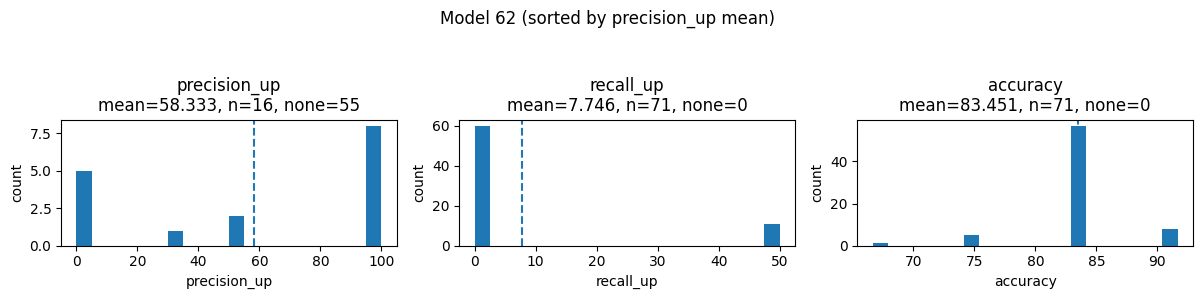

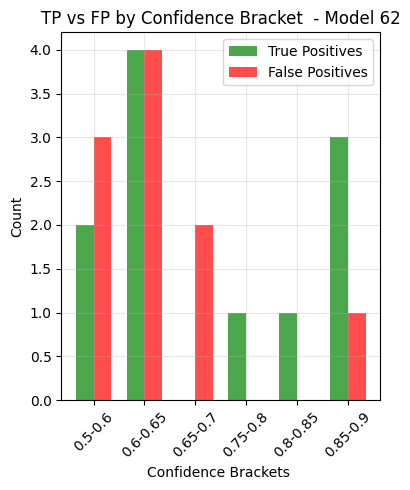

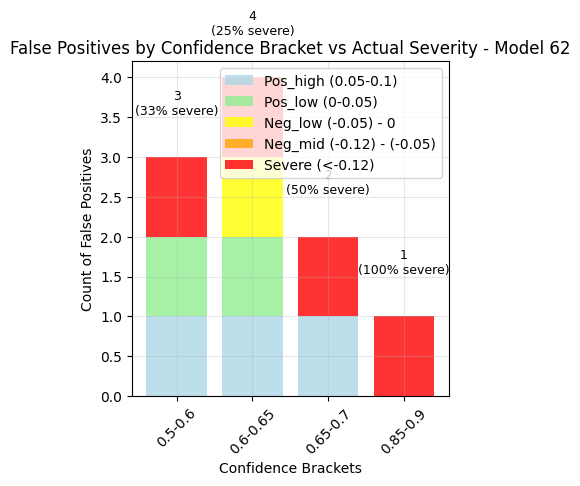

Severe Case Proportions by Confidence Bracket:
--------------------------------------------------
0.5-0.6: 33.3% severe (1/3)
0.6-0.65: 25.0% severe (1/4)
0.65-0.7: 50.0% severe (1/2)
0.85-0.9: 100.0% severe (1/1)
Severity Counts by Confidence Bracket:
--------------------------------------------------
0.5-0.6: {'Pos_high (0.05-0.1)': 1, 'Pos_low (0-0.05)': 1, 'Neg_low (-0.05) - 0': 0, 'Neg_mid (-0.12) - (-0.05)': 0, 'Severe (<-0.12)': 1}
0.6-0.65: {'Pos_high (0.05-0.1)': 1, 'Pos_low (0-0.05)': 1, 'Neg_low (-0.05) - 0': 1, 'Neg_mid (-0.12) - (-0.05)': 0, 'Severe (<-0.12)': 1}
0.65-0.7: {'Pos_high (0.05-0.1)': 1, 'Pos_low (0-0.05)': 0, 'Neg_low (-0.05) - 0': 0, 'Neg_mid (-0.12) - (-0.05)': 0, 'Severe (<-0.12)': 1}
0.85-0.9: {'Pos_high (0.05-0.1)': 0, 'Pos_low (0-0.05)': 0, 'Neg_low (-0.05) - 0': 0, 'Neg_mid (-0.12) - (-0.05)': 0, 'Severe (<-0.12)': 1}


In [6]:



LENGTH = 1
# ---- plot in the sorted order ----
for prec_mean, combo_idx, collected, parameters, per_seed in model_summaries_Tset[:LENGTH]:
    fig, axes = plt.subplots(1, len(metrics), figsize=(12, 3), squeeze=False)
    axes = axes[0]

    print(parameters)

    for ax, k in zip(axes, metrics):
        vals = [x for x in collected[k] if isinstance(x, (int, float)) and not (isinstance(x, float) and math.isnan(x))]
        none_cnt = len(collected[k]) - len(vals)

        if vals:
            mean_val = float(np.mean(vals))
            ax.hist(vals, bins=20)
            ax.axvline(mean_val, linestyle="--")
            ax.set_xlabel(k)
            ax.set_ylabel("count")
            ax.set_title(f"{k}\nmean={mean_val:.3f}, n={len(vals)}, none={none_cnt}")
        else:
            ax.text(0.5, 0.5, f"No data\nnone={none_cnt}", ha="center", va="center")
            ax.set_xticks([]); ax.set_yticks([]); ax.set_title(k)

    fig.suptitle(f"Model {combo_idx} (sorted by precision_up mean)", fontsize=12)
    fig.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()

    # =================== NEW: per-model correlation-threshold + severity plots ===================

    # Recycle your functions by making a "top-like" list from this model's seeds
    # Each item: (score_unused, entry=result_entry)
    top_like_for_this_model = [(0.0, run["result_entry"]) for run in per_seed]

    # Correlation / confidence bracket plot for THIS model
    TP_FP_brackets_analysis(top_like_for_this_model, brackets, f"Model {combo_idx}")

    # Severity plot for THIS model
    TP_FP_brackets_severity_analysis(top_like_for_this_model, brackets, f"Model {combo_idx}")







{'binary_0_1_cutoff_ret_rate_percentage': 0.1, 'learning_rate': 0.0005, 'num_epochs': 150, 'batch_size': 50, 'use_bidirectional': False, 'lag': 6, 'input_size': 12, 'hidden_size': 55, 'num_layers': 2, 'use_monthly_dfs_only': True, 'use_binary_0_1_retRate': False, 'use_custom_loss_function_BCE_THRESH': False, 'use_custom_loss_function_BCE_THRESH_AND_SEVERITY': False, 'use_LOW_weights_for_BCE_custom_loss': True, 'pred_threshold_sigmoid01_up': None, 'use_binary_neg1_1': False, 'use_ret_rate': False, 'use_print_acc': False, 'use_dropout': False, 'use_class_weighting': False, 'is_deterministic': True, 'seed_num': 42, 'use_existing_lagged_data': True, 'use_dynamic_weights': False, 'use_binary_0_1_retRate_custom_neg': False, 'use_binary_0_1_retRate_custom_pos': True, 'POS_weight_multiplier': 0.7, 'use_rolling_fixed_train_size': False, 'use_existing_initial_weights': False, 'state_dict': None, 'use_USO_wticoncat_predictor_WEEKLY_END_MO': False, 'use_UCO_wticoncat_predictor_WEEKLY_END_MO': Fals

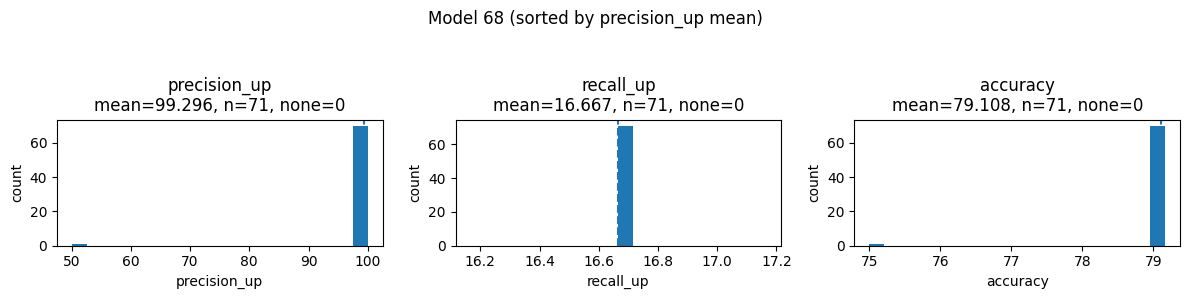

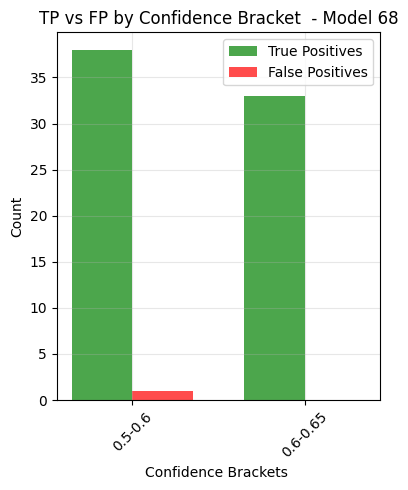

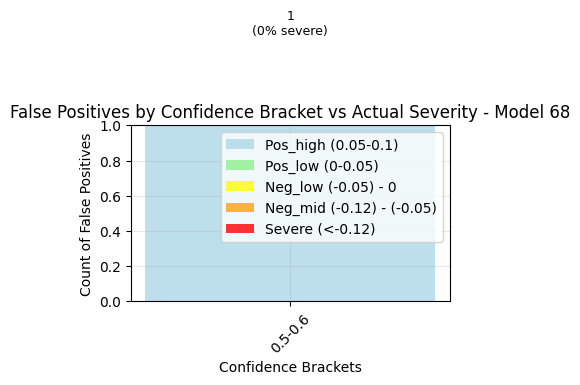

Severe Case Proportions by Confidence Bracket:
--------------------------------------------------
0.5-0.6: 0.0% severe (0/1)
Severity Counts by Confidence Bracket:
--------------------------------------------------
0.5-0.6: {'Pos_high (0.05-0.1)': 1, 'Pos_low (0-0.05)': 0, 'Neg_low (-0.05) - 0': 0, 'Neg_mid (-0.12) - (-0.05)': 0, 'Severe (<-0.12)': 0}


In [7]:




LENGTH = 1
# ---- plot in the sorted order ----
for prec_mean, combo_idx, collected, parameters, per_seed in model_summaries[:LENGTH]:
    fig, axes = plt.subplots(1, len(metrics), figsize=(12, 3), squeeze=False)
    axes = axes[0]

    print(parameters)

    for ax, k in zip(axes, metrics):
        vals = [x for x in collected[k] if isinstance(x, (int, float)) and not (isinstance(x, float) and math.isnan(x))]
        none_cnt = len(collected[k]) - len(vals)

        if vals:
            mean_val = float(np.mean(vals))
            ax.hist(vals, bins=20)
            ax.axvline(mean_val, linestyle="--")
            ax.set_xlabel(k)
            ax.set_ylabel("count")
            ax.set_title(f"{k}\nmean={mean_val:.3f}, n={len(vals)}, none={none_cnt}")
        else:
            ax.text(0.5, 0.5, f"No data\nnone={none_cnt}", ha="center", va="center")
            ax.set_xticks([]); ax.set_yticks([]); ax.set_title(k)

    fig.suptitle(f"Model {combo_idx} (sorted by precision_up mean)", fontsize=12)
    fig.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()

    # =================== NEW: per-model correlation-threshold + severity plots ===================

    # Recycle your functions by making a "top-like" list from this model's seeds
    # Each item: (score_unused, entry=result_entry)
    top_like_for_this_model = [(0.0, run["result_entry"]) for run in per_seed]

    # Correlation / confidence bracket plot for THIS model
    TP_FP_brackets_analysis(top_like_for_this_model, brackets, f"Model {combo_idx}")

    # Severity plot for THIS model
    TP_FP_brackets_severity_analysis(top_like_for_this_model, brackets, f"Model {combo_idx}")







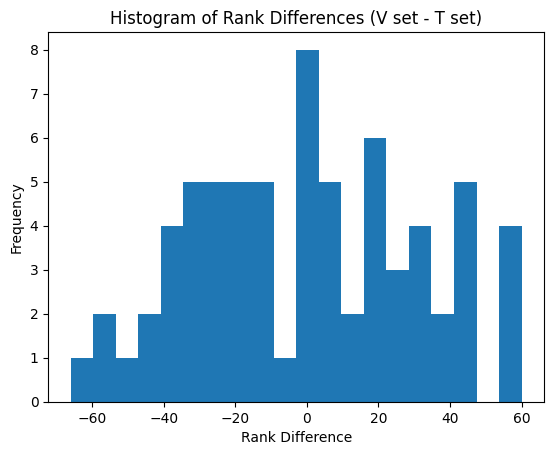

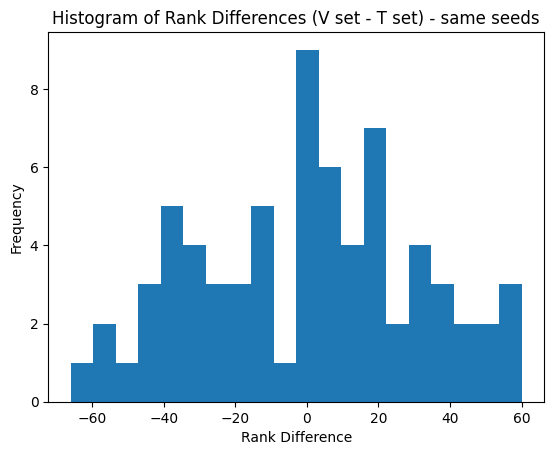

In [8]:


model_summaries_combo_idxs_Tset = [t[1] for t in model_summaries_Tset]
model_summaries_combo_idxs = [t[1] for t in model_summaries]
model_summaries_combo_idxs_Tset_same_seeds = [t[1] for t in model_summaries_Tset_same_seeds]


model_summaries_mean_V = [i[0] for i in model_summaries]
model_summaries_mean_T = [i[0] for i in model_summaries_Tset]
model_summaries_mean_T_same_seeds = [i[0] for i in model_summaries_Tset_same_seeds]


# for i , j in zip(model_summaries_combo_idxs_Tset, model_summaries_combo_idxs):
#  print(i , j)

list_ranks_coupled_V_T = []
for rank , (T_idx , V_idx , T_mean , V_mean) in enumerate(zip( model_summaries_combo_idxs_Tset, model_summaries_combo_idxs , model_summaries_mean_T , model_summaries_mean_V )):
    dic = {"rank_V" : rank , "combo_idx_val_V" : V_idx , "rank_T" : rank , "combo_idx_val_T" : T_idx  , "mean_V" : V_mean , "mean_T" : T_mean  }
    list_ranks_coupled_V_T.append(dic)


for out in list_ranks_coupled_V_T:
    for inner in list_ranks_coupled_V_T:
        if out["combo_idx_val_V"] == inner["combo_idx_val_T"]:
            out["rank_diff"] = inner["rank_T"] - out["rank_V"]  
            out["mean_diff"] = inner["mean_T"] - out["mean_V"]
            out["new_mean_T"] = inner["mean_T"]
        
list_ranks_coupled_V_T
rank_diffs = [i["rank_diff"] for i in list_ranks_coupled_V_T]
mean_diffs = [i["mean_diff"] for i in list_ranks_coupled_V_T]

plt.hist(rank_diffs , bins=20)
plt.title("Histogram of Rank Differences (V set - T set)")
plt.xlabel("Rank Difference")
plt.ylabel("Frequency")
plt.show()

###################################### with same seeds

list_ranks_coupled_V_T_same_seeds = []
for rank , (T_idx , V_idx , T_mean , V_mean) in enumerate(zip( model_summaries_combo_idxs_Tset_same_seeds, model_summaries_combo_idxs , model_summaries_mean_T_same_seeds , model_summaries_mean_V )):
    dic = {"rank_V" : rank , "combo_idx_val_V" : V_idx , "rank_T" : rank , "combo_idx_val_T" : T_idx  , "mean_V" : V_mean , "mean_T" : T_mean  }
    list_ranks_coupled_V_T_same_seeds.append(dic)


for out in list_ranks_coupled_V_T_same_seeds:
    for inner in list_ranks_coupled_V_T_same_seeds:
        if out["combo_idx_val_V"] == inner["combo_idx_val_T"]:
            out["rank_diff"] = inner["rank_T"] - out["rank_V"]  
            out["mean_diff"] = inner["mean_T"] - out["mean_V"]
            out["new_mean_T"] = inner["mean_T"]

list_ranks_coupled_V_T_same_seeds
rank_diffs = [i["rank_diff"] for i in list_ranks_coupled_V_T_same_seeds]
mean_diffs = [i["mean_diff"] for i in list_ranks_coupled_V_T_same_seeds]


plt.hist(rank_diffs , bins=20)
plt.title("Histogram of Rank Differences (V set - T set) - same seeds")
plt.xlabel("Rank Difference")
plt.ylabel("Frequency")
plt.show()










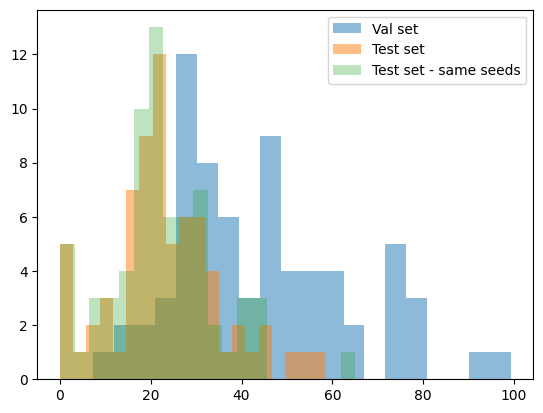

In [9]:




plt.hist(model_summaries_mean_V , bins=20 , alpha = 0.5 , label = "Val set")
plt.hist(model_summaries_mean_T , bins=20 , alpha = 0.5 , label = "Test set")
plt.hist(model_summaries_mean_T_same_seeds , bins=20 , alpha = 0.3 , label = "Test set - same seeds")
plt.legend()



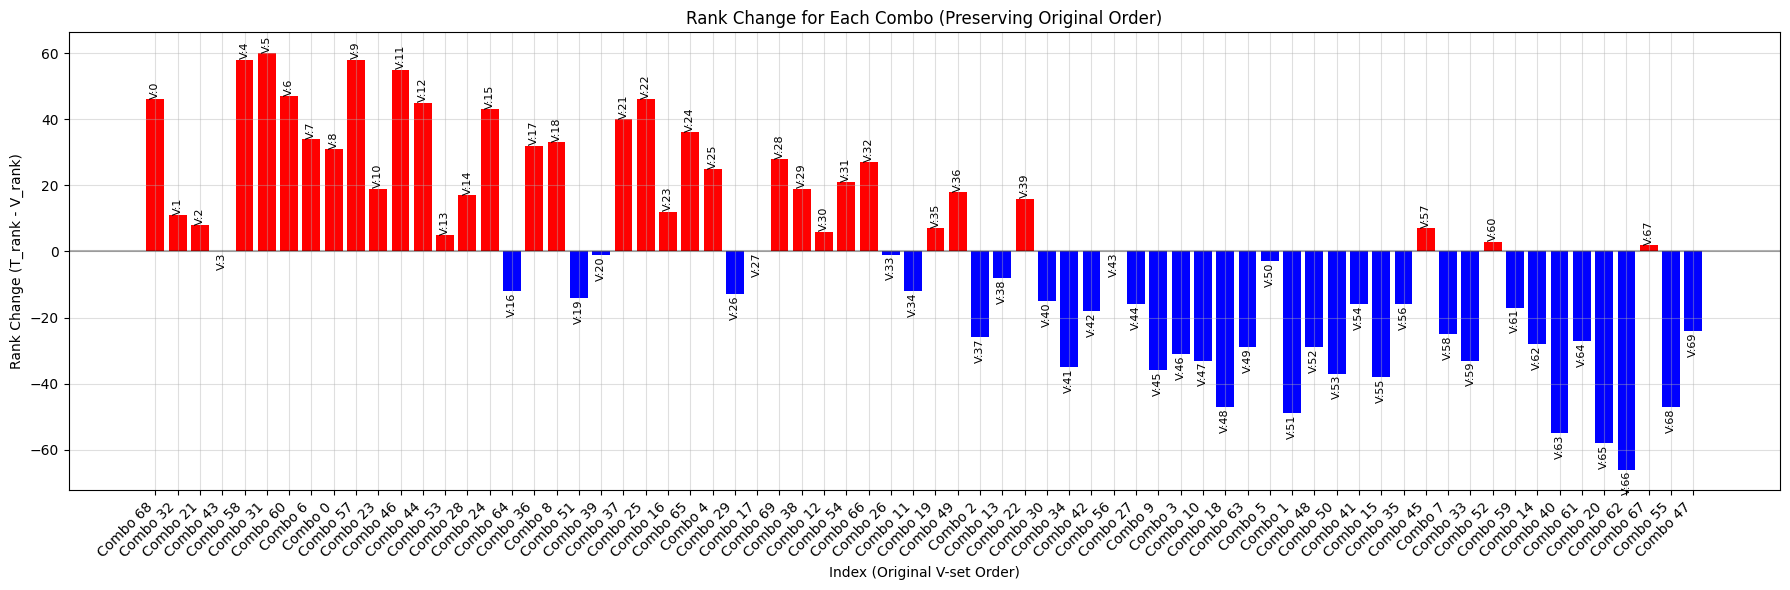

In [10]:
# Use the list_ranks_coupled in the order it was created (same as V set order)
combos = [f"Combo {item['combo_idx_val_V']}" for item in list_ranks_coupled_V_T]
changes = [item["rank_diff"] for item in list_ranks_coupled_V_T]
v_ranks = [item["rank_V"] for item in list_ranks_coupled_V_T]

plt.figure(figsize=(18, 6))
bars = plt.bar(range(len(combos)), changes, 
               color=np.where(np.array(changes) > 0, 'red', 'blue'))

plt.xlabel('Index (Original V-set Order)')
plt.ylabel('Rank Change (T_rank - V_rank)')
plt.title('Rank Change for Each Combo (Preserving Original Order)')
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)

# Add V rank labels for reference
for i, (bar, v_rank) in enumerate(zip(bars, v_ranks)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (0.1 if bar.get_height() > 0 else -0.4), 
             f'V:{v_rank}', ha='center', va='bottom' if bar.get_height() > 0 else 'top', 
             fontsize=8, rotation=90)
plt.grid(True , alpha=0.4)
plt.xticks(range(len(combos)), combos, rotation=45, ha='right')
plt.tight_layout()
plt.show()

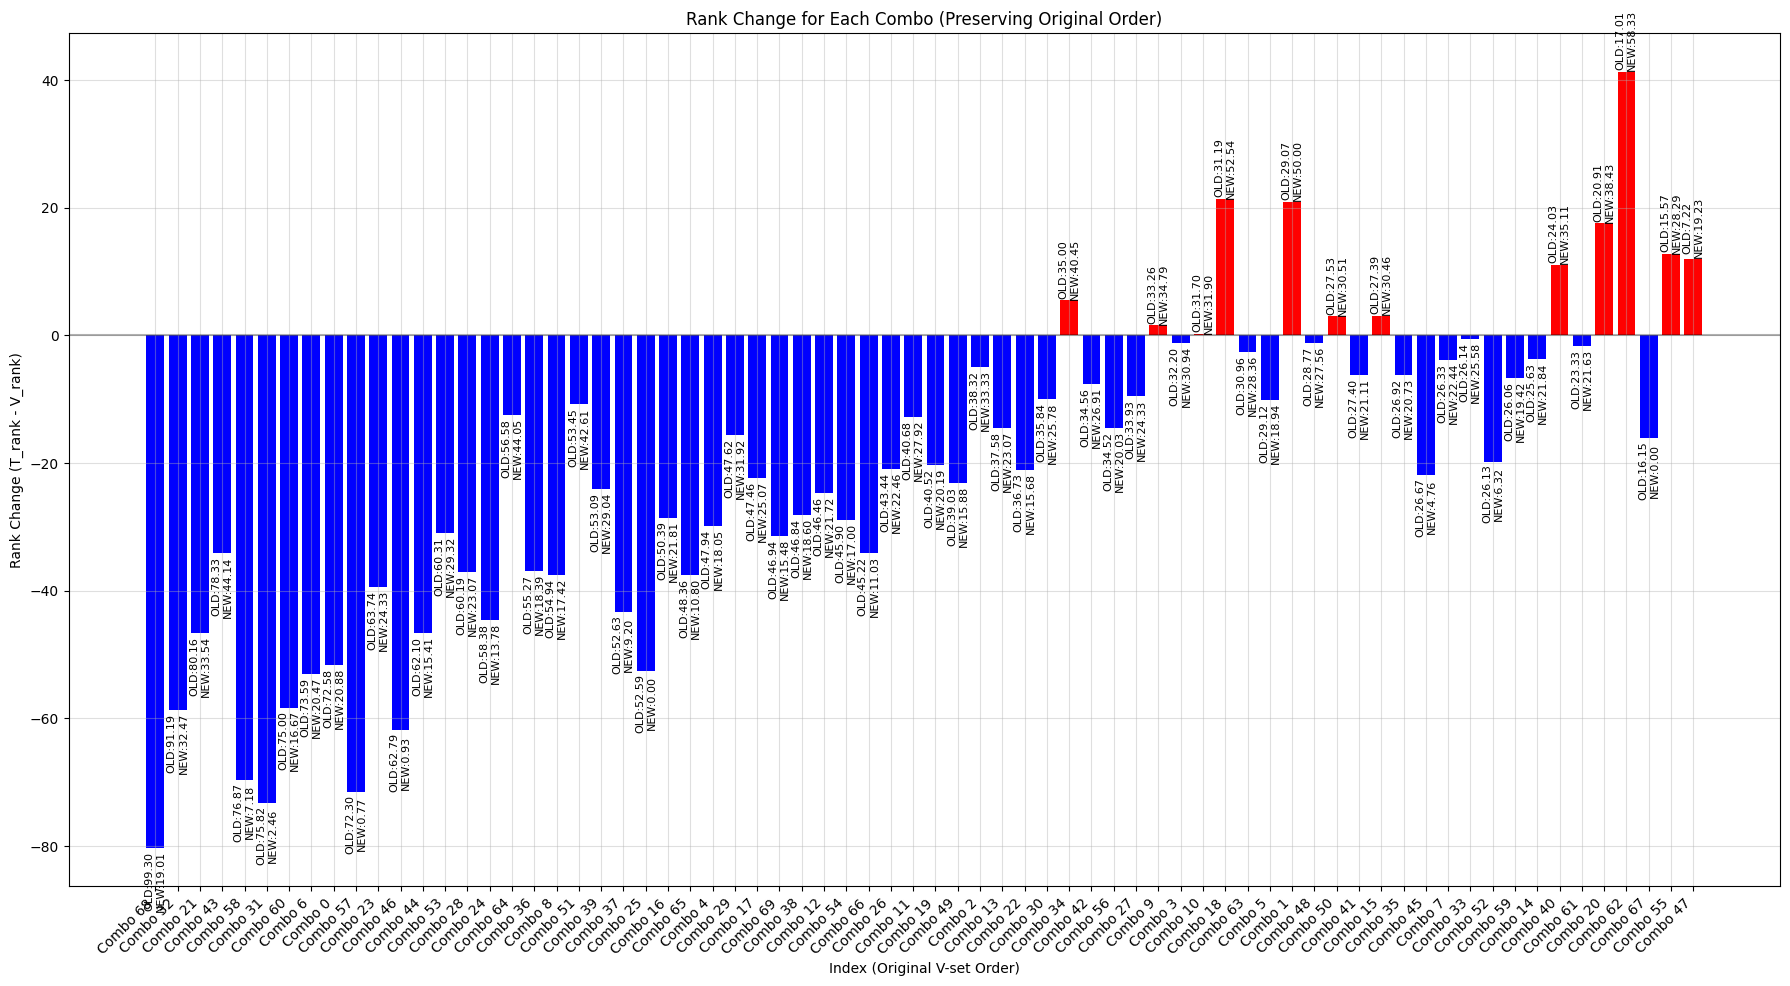

In [11]:
# Use the list_ranks_coupled in the order it was created (same as V set order)
combos = [f"Combo {item['combo_idx_val_V']}" for item in list_ranks_coupled_V_T]
changes = [item["mean_diff"] for item in list_ranks_coupled_V_T]
v_ranks = [item["rank_V"] for item in list_ranks_coupled_V_T]
v_mean = [item["mean_V"] for item in list_ranks_coupled_V_T]
v_new_mean = [item["new_mean_T"] for item in list_ranks_coupled_V_T]

plt.figure(figsize=(18, 10))
bars = plt.bar(range(len(combos)), changes, 
               color=np.where(np.array(changes) > 0, 'red', 'blue'))

plt.xlabel('Index (Original V-set Order)')
plt.ylabel('Rank Change (T_rank - V_rank)')
plt.title('Rank Change for Each Combo (Preserving Original Order)')
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)

# Add V rank labels for reference
for i, (bar, v_rank, v_mean_val, v_new_mean_val) in enumerate(zip(bars, v_ranks , v_mean , v_new_mean)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (0.1 if bar.get_height() > 0 else -0.4), 
             f'OLD:{v_mean_val:.2f}\nNEW:{v_new_mean_val:.2f}', ha='center', va='bottom' if bar.get_height() > 0 else 'top', 
             fontsize=8, rotation=90)
plt.grid(True , alpha=0.4)
plt.xticks(range(len(combos)), combos, rotation=45, ha='right')
plt.tight_layout()
plt.show()

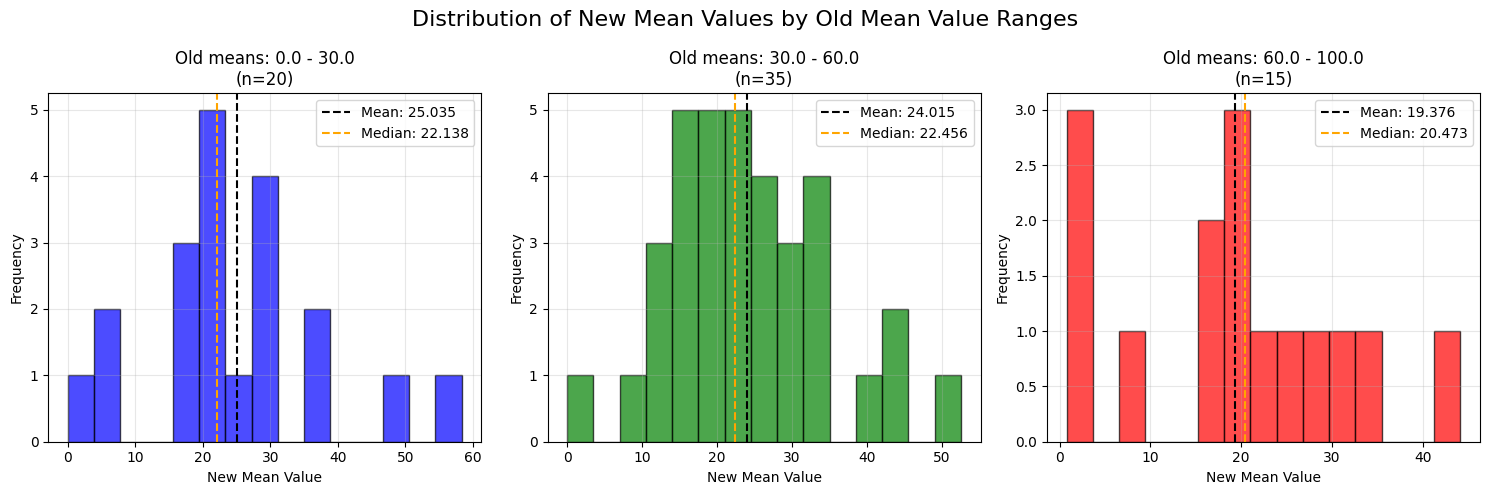

/var/folders/g_/x6nnyyc96zb627gqxngw5wgc0000gn/T/ipykernel_77461/1477475449.py:76: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(all_new_means, labels=all_labels)


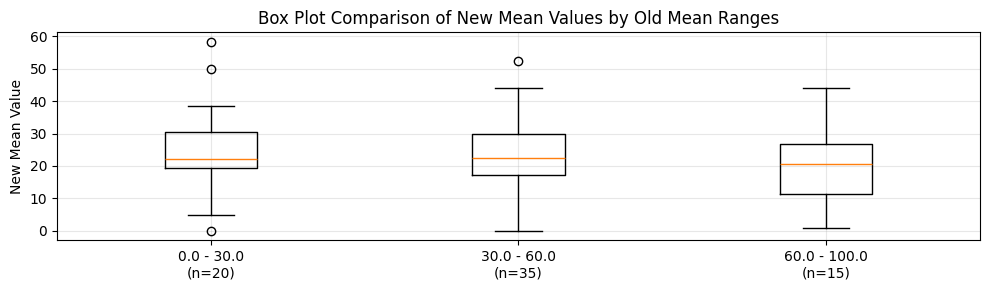

Statistics by Old Mean Range:

Range: 0.0 - 30.0
  Count: 20
  New mean - Mean:   25.0348
  New mean - Median: 22.1383
  New mean - Std:    13.4956
  New mean - Min:    0.0000
  New mean - Max:    58.3333
  Old mean - Mean:   23.8690

Range: 30.0 - 60.0
  Count: 35
  New mean - Mean:   24.0155
  New mean - Median: 22.4558
  New mean - Std:    10.6429
  New mean - Min:    0.0000
  New mean - Max:    52.5439
  Old mean - Mean:   43.4140

Range: 60.0 - 100.0
  Count: 15
  New mean - Mean:   19.3764
  New mean - Median: 20.4728
  New mean - Std:    12.3034
  New mean - Min:    0.7692
  New mean - Max:    44.1422
  Old mean - Mean:   73.6186


In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Extract & sanitize inputs
old = np.asarray(v_mean, dtype=float)
new = np.asarray(v_new_mean, dtype=float)

# 1) Drop NaN/Inf in lockstep (keep only pairs where both are finite)
valid = np.isfinite(old) & np.isfinite(new)
old = old[valid]
new = new[valid]

# Define the ranges
ranges = [(0, 30), (30, 60), (60, 100)]
range_labels = ['0.0 - 30.0', '30.0 - 60.0', '60.0 - 100.0']
colors = ['blue', 'green', 'red']  # keep if you want specific colors

# Create separate distributions
plt.figure(figsize=(15, 5))

for i, (range_val, label, color) in enumerate(zip(ranges, range_labels, colors)):
    L, H = range_val
    # 2) Range mask (last bucket inclusive of upper bound)
    if i < len(ranges) - 1:
        mask = (old >= L) & (old < H)
    else:
        mask = (old >= L) & (old <= H)

    new_r = new[mask]
    old_r = old[mask]

    plt.subplot(1, 3, i + 1)

    if new_r.size > 0:
        # 3) All values here are finite; regular stats are fine
        plt.hist(new_r, bins=15, alpha=0.7, color=color, edgecolor='black')

        mean_v = float(np.mean(new_r))
        med_v  = float(np.median(new_r))

        plt.axvline(mean_v, color='black', linestyle='--', label=f'Mean: {mean_v:.3f}')
        plt.axvline(med_v,  color='orange', linestyle='--', label=f'Median: {med_v:.3f}')

        plt.title(f'Old means: {label}\n(n={new_r.size})')
        plt.xlabel('New Mean Value')
        plt.ylabel('Frequency')
        plt.legend()
        plt.grid(True, alpha=0.3)
    else:
        plt.text(0.5, 0.5, f'No data in range\n{label}',
                 ha='center', va='center', transform=plt.gca().transAxes)
        plt.title(f'Old means: {label}')

plt.suptitle('Distribution of New Mean Values by Old Mean Value Ranges', fontsize=16)
plt.tight_layout()
plt.show()

# -------- Box plot comparison (skip empty buckets to avoid errors) --------
plt.figure(figsize=(10, 3))
all_new_means = []
all_labels = []

for i, (range_val, label) in enumerate(zip(ranges, range_labels)):
    L, H = range_val
    if i < len(ranges) - 1:
        mask = (old >= L) & (old < H)
    else:
        mask = (old >= L) & (old <= H)

    new_r = new[mask]
    if new_r.size > 0:
        all_new_means.append(new_r)
        all_labels.append(f'{label}\n(n={new_r.size})')

if all_new_means:  # only plot if at least one non-empty group
    plt.boxplot(all_new_means, labels=all_labels)
    plt.title('Box Plot Comparison of New Mean Values by Old Mean Ranges')
    plt.ylabel('New Mean Value')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No non-empty ranges for boxplot.")

# -------- Stats printout --------
print("Statistics by Old Mean Range:")
print("=" * 50)
for i, (range_val, label) in enumerate(zip(ranges, range_labels)):
    L, H = range_val
    if i < len(ranges) - 1:
        mask = (old >= L) & (old < H)
    else:
        mask = (old >= L) & (old <= H)

    new_r = new[mask]
    old_r = old[mask]

    if new_r.size > 0:
        print(f"\nRange: {label}")
        print(f"  Count: {new_r.size}")
        print(f"  New mean - Mean:   {np.mean(new_r):.4f}")
        print(f"  New mean - Median: {np.median(new_r):.4f}")
        print(f"  New mean - Std:    {np.std(new_r, ddof=0):.4f}")
        print(f"  New mean - Min:    {np.min(new_r):.4f}")
        print(f"  New mean - Max:    {np.max(new_r):.4f}")
        print(f"  Old mean - Mean:   {np.mean(old_r):.4f}")
    else:
        print(f"\nRange: {label} - No data")


In [ ]:
# results_dist_disc[0]["per_seed_all_results"][0]["result_entry"].keys()

# dict_keys(['combo_number', 'parameters', 'cv_sets', 'all_preds', 'all_actuals', 'raw_actuals', 'Y_vals_dates_LIST'])

dict_keys(['combo_number', 'parameters', 'cv_sets', 'all_preds', 'all_actuals', 'raw_actuals', 'Y_vals_dates_LIST'])

{'combo_index': 0,
 'combo': {'binary_0_1_cutoff_ret_rate_percentage': 0.1,
  'learning_rate': 0.005,
  'num_epochs': 70,
  'batch_size': 50,
  'use_bidirectional': False,
  'lag': 6,
  'input_size': 12,
  'hidden_size': 55,
  'num_layers': 1,
  'use_monthly_dfs_only': True,
  'use_binary_0_1_retRate': False,
  'use_custom_loss_function_BCE_THRESH': False,
  'use_custom_loss_function_BCE_THRESH_AND_SEVERITY': False,
  'use_LOW_weights_for_BCE_custom_loss': True,
  'pred_threshold_sigmoid01_up': None,
  'use_binary_neg1_1': False,
  'use_ret_rate': False,
  'use_print_acc': False,
  'use_dropout': False,
  'use_class_weighting': False,
  'is_deterministic': True,
  'seed_num': 42,
  'use_existing_lagged_data': True,
  'use_dynamic_weights': False,
  'use_binary_0_1_retRate_custom_neg': False,
  'use_binary_0_1_retRate_custom_pos': True,
  'POS_weight_multiplier': 1.5,
  'use_rolling_fixed_train_size': False,
  'use_existing_initial_weights': False,
  'state_dict': None,
  'use_USO_wtico

In [275]:
import math
import numpy as np
from collections import defaultdict

def recompute_selected_models_on_Tset(results_dist_disc_Tset_same_seeds_organized,
                                      selected_models,
                                      brackets=((0.5, 0.7), (0.7, 1.0))):
    """
    Recompute the SAME analytics produced by `select_models_by_criteria`
    for the SAME models & seeds, but using the T-set dataset:
        results_dist_disc_Tset_same_seeds_organized

    Parameters
    ----------
    results_dist_disc_Tset_same_seeds_organized : list[dict]
        Dataset with the same schema as results_dist_disc:
        [
          {
            'combo_index': int,
            'combo': {...parameters...},
            'per_seed_all_results': [
               {'seed': int,
                'result_entry': {
                    'cv_sets': {'overall_metrics': {'precision_up': float, 'recall_up': float}},
                    'all_preds': list[list[float]],
                    'all_actuals': list[list[float]],
                    'raw_actuals': list[list[float]],
                }
               },
               ...
            ]
          },
          ...
        ]

    selected_models : list[dict]
        The output list from `select_models_by_criteria(...)`. We will mirror:
        - models by combo_index
        - seeds by seed_num (exact same subset)
        and recompute all analytics on the T-set.

    brackets : tuple of (L, H)
        Probability/score brackets to use (must match the selection function).

    Returns
    -------
    list[dict]
        A list matching the exact schema of `select_models_by_criteria`'s output,
        but recomputed on the T-set, for the SAME models and SAME selected seeds:
        [
          {
            "combo_index": ...,
            "parameters": ...,
            "mean_precision": ...,
            "valid_seeds_count": len(selected_seeds_on_Tset),
            "total_seeds": <total seeds available for this model in Tset>,
            "zero_precision_count": <count across ALL seeds in this model in Tset>,
            "bracket_counts": {...}                # across ALL seeds in this model in Tset
            "non_bracket_counts": {...},           # across ALL seeds in this model in Tset
            "fp_tp_ratios": {...},                 # from aggregated bracket_counts
            "ratio_difference": <rl - rh if both exist>,
            "fp_severe_ratio_fps": <severe_fp / total_fp>,
            "fp_severe_ratio_fps_tps": <severe_fp / (total_fp + total_tp)>,
            "selected_seeds": [                    # ONLY the SAME seeds you selected originally
               {
                 "seed_num": ...,
                 "seed_order_index": ...,
                 "precision": ...,
                 "recall": ...,
                 "seed_bracket_counts": {...},
                 "seed_non_bracket_counts": {...},
                 "seed_fp_tp_ratios": {...},
                 "seed_total_tp": ...,
                 "seed_severe_fp": ...,
                 "seed_severe_fp_high_bracket": ...
               },
               ...
            ]
          },
          ...
        ]
    """

    # Build an index of Tset models by combo_index for O(1) lookup
    tset_by_combo = {m["combo_index"]: m for m in results_dist_disc_Tset_same_seeds_organized}

    # Helper to compute all counts/metrics for a single model on Tset (across ALL seeds)
    def _compute_model_metrics_on_tset(model_entry, brackets):
        per_seed = model_entry["per_seed_all_results"]

        zero_precision_count = 0
        bracket_counts = defaultdict(lambda: {'TP': 0, 'FP': 0})
        non_bracket_counts = {'TN': 0, 'FN': 0}
        seed_records_all = []

        total_severe_fp = 0
        total_fp_all = 0
        total_tp_all = 0

        for run_idx, run in enumerate(per_seed):
            re = run["result_entry"]
            om = re["cv_sets"]["overall_metrics"]
            seed_num = run["seed"]

            prec = om.get("precision_up")
            rec = om.get("recall_up")

            if isinstance(prec, (int, float)) and not math.isnan(prec):
                prec = float(prec)
                if prec == 0:
                    zero_precision_count += 1
            else:
                prec = None

            if isinstance(rec, (int, float)) and not math.isnan(rec):
                rec = float(rec)
            else:
                rec = None

            # Per-seed tallies for this model
            seed_bracket_counts = defaultdict(lambda: {'TP': 0, 'FP': 0})
            seed_non_bracket_counts = {'TN': 0, 'FN': 0}
            seed_total_tp = 0
            seed_total_fp = 0
            seed_severe_fp = 0
            seed_severe_fp_high_bracket = 0

            # Walk folds/timesteps exactly like selection function
            for pred_fold, actual_fold, raw_fold in zip(re["all_preds"], re["all_actuals"], re["raw_actuals"]):
                for pred, actual, raw in zip(pred_fold, actual_fold, raw_fold):
                    true_positive = (actual > 0.5) and (pred >= 0.5)
                    false_positive = (actual <= 0.5) and (pred >= 0.5)
                    true_negative = (actual <= 0.5) and (pred < 0.5)
                    false_negative = (actual > 0.5) and (pred < 0.5)

                    assigned = False
                    for (L, H) in brackets:
                        if L <= pred < H:
                            assigned = True
                            key = f"{L}-{H}"
                            if true_positive:
                                bracket_counts[key]['TP'] += 1
                                seed_bracket_counts[key]['TP'] += 1
                                seed_total_tp += 1
                                total_tp_all += 1
                            elif false_positive:
                                bracket_counts[key]['FP'] += 1
                                seed_bracket_counts[key]['FP'] += 1
                                seed_total_fp += 1
                                total_fp_all += 1

                                severity = classify_severity_10_percent_pos(raw)
                                if severity == "Severe (<-0.12)":
                                    seed_severe_fp += 1
                                    total_severe_fp += 1
                                    if key == "0.7-1.0":
                                        seed_severe_fp_high_bracket += 1
                            break

                    if not assigned:
                        if true_negative:
                            non_bracket_counts['TN'] += 1
                            seed_non_bracket_counts['TN'] += 1
                        elif false_negative:
                            non_bracket_counts['FN'] += 1
                            seed_non_bracket_counts['FN'] += 1

            # Per-seed ratios (for convenience if needed elsewhere)
            seed_fp_tp_ratios = {}
            for key, counts in seed_bracket_counts.items():
                tp, fp = counts['TP'], counts['FP']
                denom = tp + fp
                seed_fp_tp_ratios[key] = (fp / denom) if denom > 0 else float("nan")

            seed_records_all.append({
                "seed_order_index": run_idx,  # position within per_seed_all_results
                "seed_num": seed_num,
                "precision": prec,
                "recall": rec,
                "seed_bracket_counts": dict(seed_bracket_counts),
                "seed_non_bracket_counts": dict(seed_non_bracket_counts),
                "seed_fp_tp_ratios": seed_fp_tp_ratios,
                "seed_total_tp": seed_total_tp,
                "seed_total_fp": seed_total_fp,
                "seed_severe_fp": seed_severe_fp,
                "seed_severe_fp_high_bracket": seed_severe_fp_high_bracket,
            })

        # Mean precision across ALL seeds (just like the selection function)
        non_none_precs = [r["precision"] for r in seed_records_all if r["precision"] is not None]
        mean_precision = float(np.mean(non_none_precs)) if non_none_precs else float("nan")

        # Model-level fp/tp ratio by bracket
        fp_tp_ratios = {}
        for key, counts in bracket_counts.items():
            tp, fp = counts['TP'], counts['FP']
            denom = tp + fp
            fp_tp_ratios[key] = (fp / denom) if denom > 0 else float("nan")

        # rl - rh (low minus high)
        ratio_difference = None
        if "0.7-1.0" in fp_tp_ratios and "0.5-0.7" in fp_tp_ratios:
            rh = fp_tp_ratios["0.7-1.0"]
            rl = fp_tp_ratios["0.5-0.7"]
            if not math.isnan(rh) and not math.isnan(rl):
                ratio_difference = rl - rh

        # Severe FP ratios
        fp_severe_ratio_fps = (total_severe_fp / total_fp_all) if total_fp_all > 0 else 0
        denom_pos = (total_fp_all + total_tp_all)
        fp_severe_ratio_fps_tps = (total_severe_fp / denom_pos) if denom_pos > 0 else 0

        return {
            "mean_precision": mean_precision,
            "zero_precision_count": zero_precision_count,
            "total_seeds": len(seed_records_all),
            "seed_records_all": seed_records_all,  # keep for seed picking below
            "bracket_counts": dict(bracket_counts),
            "non_bracket_counts": dict(non_bracket_counts),
            "fp_tp_ratios": fp_tp_ratios,
            "ratio_difference": ratio_difference,
            "fp_severe_ratio_fps": fp_severe_ratio_fps,
            "fp_severe_ratio_fps_tps": fp_severe_ratio_fps_tps,
        }

    # Build output mirroring the original selection output
    mirrored_outputs = []

    for sel_model in selected_models:
        combo_idx = sel_model["combo_index"]
        # Find the corresponding Tset model
        if combo_idx not in tset_by_combo:
            # If absent, skip (or you could raise)
            # print(f"[WARN] combo_index {combo_idx} not found in Tset.")
            continue

        tset_model = tset_by_combo[combo_idx]
        model_metrics = _compute_model_metrics_on_tset(tset_model, brackets)

        # Build a map from seed_num -> seed_record (computed from Tset)
        seed_map = {sr["seed_num"]: sr for sr in model_metrics["seed_records_all"]}

        # Recreate the "selected_seeds" list using the EXACT same seeds (and order) from training selection
        selected_seeds_Tset = []
        for s in sel_model["selected_seeds"]:
            seed_num = s["seed_num"]
            # The Tset should have the same seed; if not, skip.
            if seed_num not in seed_map:
                # print(f"[WARN] Seed {seed_num} not found in Tset model {combo_idx}. Skipping.")
                continue

            sr = seed_map[seed_num]
            # Mirror the schema exactly
            selected_seeds_Tset.append({
                "seed_num": sr["seed_num"],
                "seed_order_index": sr["seed_order_index"],
                "precision": sr["precision"],
                "recall": sr["recall"],
                "seed_bracket_counts": sr["seed_bracket_counts"],
                "seed_non_bracket_counts": sr["seed_non_bracket_counts"],
                "seed_fp_tp_ratios": sr["seed_fp_tp_ratios"],
                "seed_total_tp": sr["seed_total_tp"],
                "seed_severe_fp": sr["seed_severe_fp"],
                "seed_severe_fp_high_bracket": sr["seed_severe_fp_high_bracket"],
            })

        # Assemble model-level dict in the EXACT same shape as your selection output
        mirrored_outputs.append({
            "combo_index": combo_idx,
            "parameters": tset_model["combo"],  # use Tset model parameters (should match)
            "mean_precision": model_metrics["mean_precision"],
            "valid_seeds_count": len(selected_seeds_Tset),               # count of SAME selected seeds (on Tset)
            "total_seeds": model_metrics["total_seeds"],                  # all seeds present in this model on Tset
            "zero_precision_count": model_metrics["zero_precision_count"],
            "bracket_counts": model_metrics["bracket_counts"],
            "non_bracket_counts": model_metrics["non_bracket_counts"],
            "fp_tp_ratios": model_metrics["fp_tp_ratios"],
            "ratio_difference": model_metrics["ratio_difference"],
            "fp_severe_ratio_fps": model_metrics["fp_severe_ratio_fps"],
            "fp_severe_ratio_fps_tps": model_metrics["fp_severe_ratio_fps_tps"],
            "selected_seeds": selected_seeds_Tset,                       # ONLY the SAME seeds
        })

    return mirrored_outputs


In [301]:
# Modified function to store TP and FP counts for each seed
def select_models_by_criteria(results_data, 
                             mean_precision_range=(0, 100),
                             seed_precision_range=(0, 100),
                             seed_recall_range=(0, 100),
                             min_seeds_per_model=1,
                             max_models_to_return=10,
                             max_zero_precision_seeds=None,
                             min_ratio_difference=None,
                             max_ratio_difference=None,
                             seed_min_TPminusFP_greaterEqual=None,
                             max_FP_severe_ratio_FPs=None,         
                             max_FP_severe_ratio_FPs_andTPs=None, 
                             min_FP_severe_ratio_FPs=None,         
                             min_FP_severe_ratio_FPs_andTPs=None, 
                                                           
                             max_seed_severe_FPs_high_bracket=None,
                             min_seed_TPs_high_bracket=None,       
                             random_seed=None):
    
    if random_seed is not None:
        random.seed(random_seed)

    brackets = [(0.5, 0.7), (0.7, 1.0)]
    model_summaries = []

    for model in results_data:
        combo_idx = model["combo_index"]

        parameters = model["combo"]
        per_seed = model["per_seed_all_results"]

        zero_precision_count = 0
        bracket_counts = defaultdict(lambda: {'TP': 0, 'FP': 0})
        non_bracket_counts = {'TN': 0, 'FN': 0}
        seed_records = []
        
        # NEW: Track severe FP counts
        total_severe_fp = 0
        total_fp_all = 0
        total_tp_all = 0

        for run in per_seed:
            re = run["result_entry"]
            om = re["cv_sets"]["overall_metrics"]

            seed_num = run["seed"]

            prec = om.get("precision_up")
            rec = om.get("recall_up")
            if isinstance(prec, (int, float)) and not math.isnan(prec):
                prec = float(prec)
                if prec == 0:
                    zero_precision_count += 1
            else:
                prec = None

            if isinstance(rec, (int, float)) and not math.isnan(rec):
                rec = float(rec)
            else:
                rec = None

            # Store TP and FP counts for each bracket per seed
            seed_bracket_counts = defaultdict(lambda: {'TP': 0, 'FP': 0})
            seed_non_bracket_counts = {'TN': 0, 'FN': 0}
            seed_total_tp = 0
            seed_total_fp = 0
            seed_severe_fp = 0  # NEW: Track severe FPs per seed
            seed_severe_fp_high_bracket = 0  # NEW: Track severe FPs specifically in 0.7-1.0 bracket

            for pred_fold, actual_fold ,raw_fold in zip(re["all_preds"], re["all_actuals"], re["raw_actuals"]):
                for pred, actual, raw in zip(pred_fold, actual_fold, raw_fold):
                    true_positive = (actual > 0.5) and (pred >= 0.5)
                    false_positive = (actual <= 0.5) and (pred >= 0.5)
                    true_negative = (actual <= 0.5) and (pred < 0.5)
                    false_negative = (actual > 0.5) and (pred < 0.5)

                    assigned = False
                    for L, H in brackets:
                        if L <= pred < H:
                            assigned = True
                            key = f"{L}-{H}"
                            if true_positive:
                                bracket_counts[key]['TP'] += 1
                                seed_bracket_counts[key]['TP'] += 1
                                seed_total_tp += 1
                                total_tp_all += 1  # NEW: Count all TPs
                            elif false_positive:
                                bracket_counts[key]['FP'] += 1
                                seed_bracket_counts[key]['FP'] += 1
                                seed_total_fp += 1
                                total_fp_all += 1  # NEW: Count all FPs
                                
                                # NEW: Check if this is a severe FP
                                severity = classify_severity_10_percent_pos(raw)
                                if severity == "Severe (<-0.12)":
                                    seed_severe_fp += 1
                                    total_severe_fp += 1
                                    # NEW: Check if this severe FP is in the high bracket (0.7-1.0)
                                    if key == "0.7-1.0":
                                        seed_severe_fp_high_bracket += 1
                            break

                    if not assigned:
                        if true_negative:
                            seed_non_bracket_counts['TN'] += 1
                            non_bracket_counts['TN'] += 1
                        elif false_negative:
                            seed_non_bracket_counts['FN'] += 1
                            non_bracket_counts['FN'] += 1

            seed_fp_tp_ratios = {}
            for key, counts in seed_bracket_counts.items():
                tp, fp = counts['TP'], counts['FP']
                denom = tp + fp
                seed_fp_tp_ratios[key] = (fp / denom) if denom > 0 else float("nan")

            seed_records.append({
                "seed_num": seed_num,
                "precision": prec,
                "recall": rec,
                "seed_bracket_counts": dict(seed_bracket_counts),
                "seed_non_bracket_counts": dict(seed_non_bracket_counts),
                "seed_fp_tp_ratios": seed_fp_tp_ratios,
                "seed_total_tp": seed_total_tp,
                "seed_total_fp": seed_total_fp,
                "seed_severe_fp": seed_severe_fp,  # NEW: Add severe FP count
                "seed_severe_fp_high_bracket": seed_severe_fp_high_bracket,  # NEW: Add severe FP count in high bracket
                "seed_raw": run,
            })

        non_none_precs = [r["precision"] for r in seed_records if r["precision"] is not None]
        mean_precision = float(np.mean(non_none_precs)) if non_none_precs else float("nan")

        fp_tp_ratios = {}
        for key, counts in bracket_counts.items():
            tp, fp = counts['TP'], counts['FP']
            denom = tp + fp
            fp_tp_ratios[key] = (fp / denom) if denom > 0 else float("nan")

        ratio_difference = None
        if "0.7-1.0" in fp_tp_ratios and "0.5-0.7" in fp_tp_ratios:
            rh, rl = fp_tp_ratios["0.7-1.0"], fp_tp_ratios["0.5-0.7"]
            if not math.isnan(rh) and not math.isnan(rl):
                ratio_difference = rl - rh

        # NEW: Calculate severe FP ratios
        fp_severe_ratio_fps = total_severe_fp / total_fp_all if total_fp_all > 0 else 0
        fp_severe_ratio_fps_tps = total_severe_fp / (total_fp_all + total_tp_all) if (total_fp_all + total_tp_all) > 0 else 0

        model_summaries.append({
            "combo_index": combo_idx,
            "parameters": parameters,
            "mean_precision": mean_precision,
            "zero_precision_count": zero_precision_count,
            "total_seeds": len(seed_records),
            "seed_records": seed_records,
            "bracket_counts": dict(bracket_counts),
            "non_bracket_counts": dict(non_bracket_counts),
            "fp_tp_ratios": fp_tp_ratios,
            "ratio_difference": ratio_difference,
            "fp_severe_ratio_fps": fp_severe_ratio_fps,           # NEW: Add severe FP ratios
            "fp_severe_ratio_fps_tps": fp_severe_ratio_fps_tps,   # NEW: Add severe FP ratios
        })

    filtered_models = []
    min_mean_prec, max_mean_prec = mean_precision_range
    min_seed_prec, max_seed_prec = seed_precision_range
    min_seed_rec, max_seed_rec = seed_recall_range

    for m in model_summaries:
        # Check mean precision range
        mean_prec = m["mean_precision"] if not math.isnan(m["mean_precision"]) else -float("inf")
        if not (min_mean_prec <= mean_prec <= max_mean_prec):
            continue

        # Check zero precision count
        if max_zero_precision_seeds is not None and m["zero_precision_count"] > max_zero_precision_seeds:
            continue

        # Check ratio difference
        if min_ratio_difference is not None or max_ratio_difference is not None:
            if m["ratio_difference"] is None:
                continue
            if min_ratio_difference is not None and m["ratio_difference"] < min_ratio_difference:
                continue
        if max_ratio_difference is not None:    
            if m["ratio_difference"] is None:
                continue
            if max_ratio_difference is not None and m["ratio_difference"] > max_ratio_difference:
                continue

        # NEW: Check severe FP ratio among all FPs
        if max_FP_severe_ratio_FPs is not None:
            if not (m["fp_severe_ratio_fps"] < max_FP_severe_ratio_FPs):
                continue

        if min_FP_severe_ratio_FPs is not None:
            if not (m["fp_severe_ratio_fps"] > min_FP_severe_ratio_FPs):
                continue

        # NEW: Check severe FP ratio among all positive predictions (TPs + FPs)
        if max_FP_severe_ratio_FPs_andTPs is not None:
            if not (m["fp_severe_ratio_fps_tps"] < max_FP_severe_ratio_FPs_andTPs):
                continue
        
        if min_FP_severe_ratio_FPs_andTPs is not None:
            if not (m["fp_severe_ratio_fps_tps"] > min_FP_severe_ratio_FPs_andTPs):
                continue

        valid_seeds = []
        for idx, r in enumerate(m["seed_records"]):
            prec, rec = r["precision"], r["recall"]

            if prec is None or rec is None:
                continue
            if (min_seed_prec <= prec <= max_seed_prec) and (min_seed_rec <= rec <= max_seed_rec):

                # TP-FP difference filtering
                bracket_high = r["seed_bracket_counts"].get("0.7-1.0", {"TP": 0, "FP": 0})
                bracket_low = r["seed_bracket_counts"].get("0.5-0.7", {"TP": 0, "FP": 0})
                
                net_high = bracket_high["TP"] - bracket_high["FP"]
                net_low = bracket_low["TP"] - bracket_low["FP"]

                if seed_min_TPminusFP_greaterEqual is not None:
                    if (bracket_high["TP"] == 0):
                        continue
                    if (bracket_high["FP"] > bracket_high["TP"]):
                        continue
                    if not (net_high - net_low >= seed_min_TPminusFP_greaterEqual):
                        continue

                # NEW: Check max severe FPs in high bracket for this seed
                if max_seed_severe_FPs_high_bracket is not None:
                    if not (r["seed_severe_fp_high_bracket"] <= max_seed_severe_FPs_high_bracket):
                        continue

                # NEW: Check min TPs in high bracket for this seeda
                if min_seed_TPs_high_bracket is not None:
                    if not (bracket_high["TP"] >= min_seed_TPs_high_bracket):
                        continue

                valid_seeds.append({
                    "seed_order_index": idx,
                    "seed_num": r["seed_num"],
                    "precision": prec,
                    "recall": rec,
                    "seed_bracket_counts": r["seed_bracket_counts"],
                    "seed_non_bracket_counts": r["seed_non_bracket_counts"],
                    "seed_fp_tp_ratios": r["seed_fp_tp_ratios"],
                    "seed_total_tp": r["seed_total_tp"],
                    "seed_severe_fp": r["seed_severe_fp"],  # NEW: Include severe FP count
                    "seed_severe_fp_high_bracket": r["seed_severe_fp_high_bracket"],  # NEW: Include severe FP count in high bracket
                })

        if len(valid_seeds) >= min_seeds_per_model:
            filtered_models.append({
                "combo_index": m["combo_index"],
                "parameters": m["parameters"],
                "mean_precision": m["mean_precision"],
                "valid_seeds_count": len(valid_seeds),
                "valid_seeds": valid_seeds,
                "total_seeds": m["total_seeds"],
                "zero_precision_count": m["zero_precision_count"],
                "bracket_counts": m["bracket_counts"],
                "non_bracket_counts": m["non_bracket_counts"],
                "fp_tp_ratios": m["fp_tp_ratios"],
                "ratio_difference": m["ratio_difference"],
                "fp_severe_ratio_fps": m["fp_severe_ratio_fps"],           # NEW: Include severe FP ratios
                "fp_severe_ratio_fps_tps": m["fp_severe_ratio_fps_tps"],   # NEW: Include severe FP ratios
            })

    if max_models_to_return < len(filtered_models):
        n_pick = min(max_models_to_return, len(filtered_models))
        selected_models = random.sample(filtered_models, n_pick) if n_pick > 0 else []
    else:
        selected_models = filtered_models

    output = []
    for m in selected_models:
        output.append({
            "combo_index": m["combo_index"],
            "parameters": m["parameters"],
            "mean_precision": m["mean_precision"],
            "valid_seeds_count": m["valid_seeds_count"],
            "total_seeds": m["total_seeds"],
            "zero_precision_count": m["zero_precision_count"],
            "bracket_counts": m["bracket_counts"],
            "non_bracket_counts": m["non_bracket_counts"],
            "fp_tp_ratios": m["fp_tp_ratios"],
            "ratio_difference": m["ratio_difference"],
            "fp_severe_ratio_fps": m["fp_severe_ratio_fps"],           # NEW: Include in output
            "fp_severe_ratio_fps_tps": m["fp_severe_ratio_fps_tps"],   # NEW: Include in output
            "selected_seeds": [
                {
                    "seed_num": s["seed_num"],
                    "seed_order_index": s["seed_order_index"],
                    "precision": s["precision"],
                    "recall": s["recall"],
                    "seed_bracket_counts": s["seed_bracket_counts"],
                    "seed_non_bracket_counts": s["seed_non_bracket_counts"],
                    "seed_fp_tp_ratios": s["seed_fp_tp_ratios"],
                    "seed_total_tp": s["seed_total_tp"],
                    "seed_severe_fp": s["seed_severe_fp"],  # NEW: Include in seed output
                    "seed_severe_fp_high_bracket": s["seed_severe_fp_high_bracket"],  # NEW: Include in seed output
                }
                for s in m["valid_seeds"]
            ]
        })

    return output


# Run the model selection function with the new parameters
selected_models = select_models_by_criteria(
    results_dist_disc,
    mean_precision_range=(0, 100),
    seed_precision_range=(0, 100),
    seed_recall_range=(1, 100),
    min_seeds_per_model=1,
    max_zero_precision_seeds=70,
    min_ratio_difference= .1,
    max_ratio_difference=None,
    seed_min_TPminusFP_greaterEqual=None,
    max_FP_severe_ratio_FPs= None,
    max_FP_severe_ratio_FPs_andTPs=None,
    min_FP_severe_ratio_FPs=None,
    min_FP_severe_ratio_FPs_andTPs=None,
    max_seed_severe_FPs_high_bracket=None,
    min_seed_TPs_high_bracket=None,  # NEW: Add the parameter here
    random_seed=42,
    max_models_to_return=70
)

# Print summary of selected models
print(f"Models Selected control: {len(selected_models)}")
total_seeds = sum(len(model["selected_seeds"]) for model in selected_models)
print(f"Total seeds selected control: {total_seeds}")



Models Selected control: 28
Total seeds selected control: 1742


In [223]:
selected_models[0]

{'combo_index': 0,
 'parameters': {'binary_0_1_cutoff_ret_rate_percentage': 0.1,
  'learning_rate': 0.005,
  'num_epochs': 70,
  'batch_size': 50,
  'use_bidirectional': False,
  'lag': 6,
  'input_size': 12,
  'hidden_size': 55,
  'num_layers': 1,
  'use_monthly_dfs_only': True,
  'use_binary_0_1_retRate': False,
  'use_custom_loss_function_BCE_THRESH': False,
  'use_custom_loss_function_BCE_THRESH_AND_SEVERITY': False,
  'use_LOW_weights_for_BCE_custom_loss': True,
  'pred_threshold_sigmoid01_up': None,
  'use_binary_neg1_1': False,
  'use_ret_rate': False,
  'use_print_acc': False,
  'use_dropout': False,
  'use_class_weighting': False,
  'is_deterministic': True,
  'seed_num': 42,
  'use_existing_lagged_data': True,
  'use_dynamic_weights': False,
  'use_binary_0_1_retRate_custom_neg': False,
  'use_binary_0_1_retRate_custom_pos': True,
  'POS_weight_multiplier': 1.5,
  'use_rolling_fixed_train_size': False,
  'use_existing_initial_weights': False,
  'state_dict': None,
  'use_USO_

Models Selected control: 70
Total seeds selected control: 3962
Models Selected HIGH: 8
Total seeds selected HIGH: 414
Models Selected LOW: 15
Total seeds selected LOW: 1001


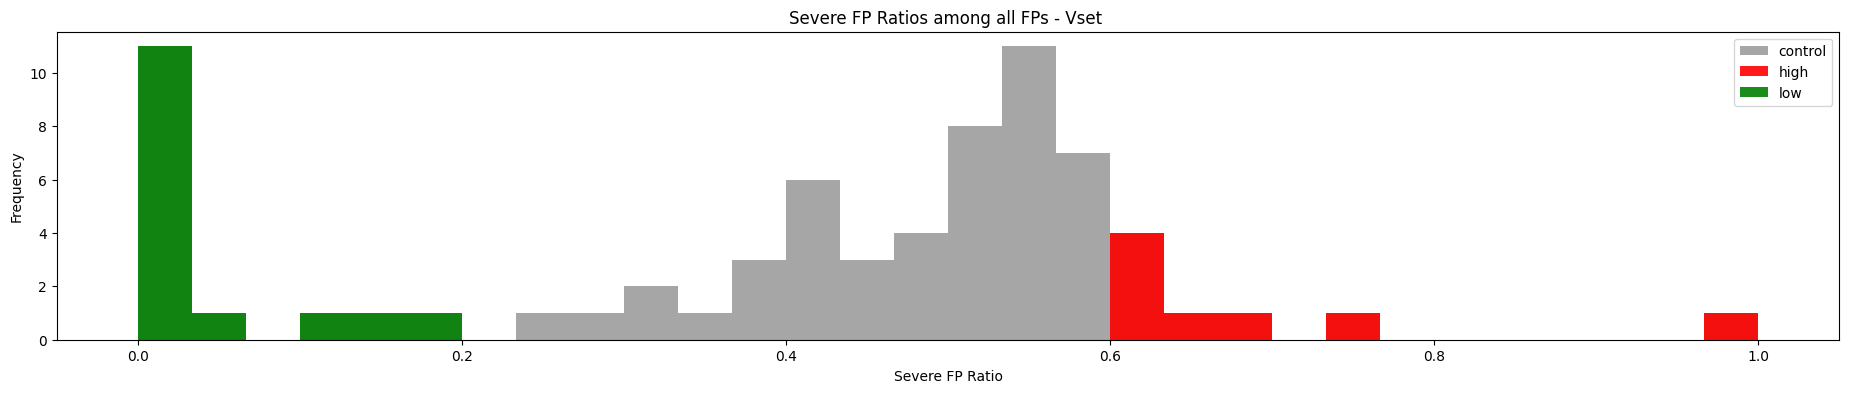

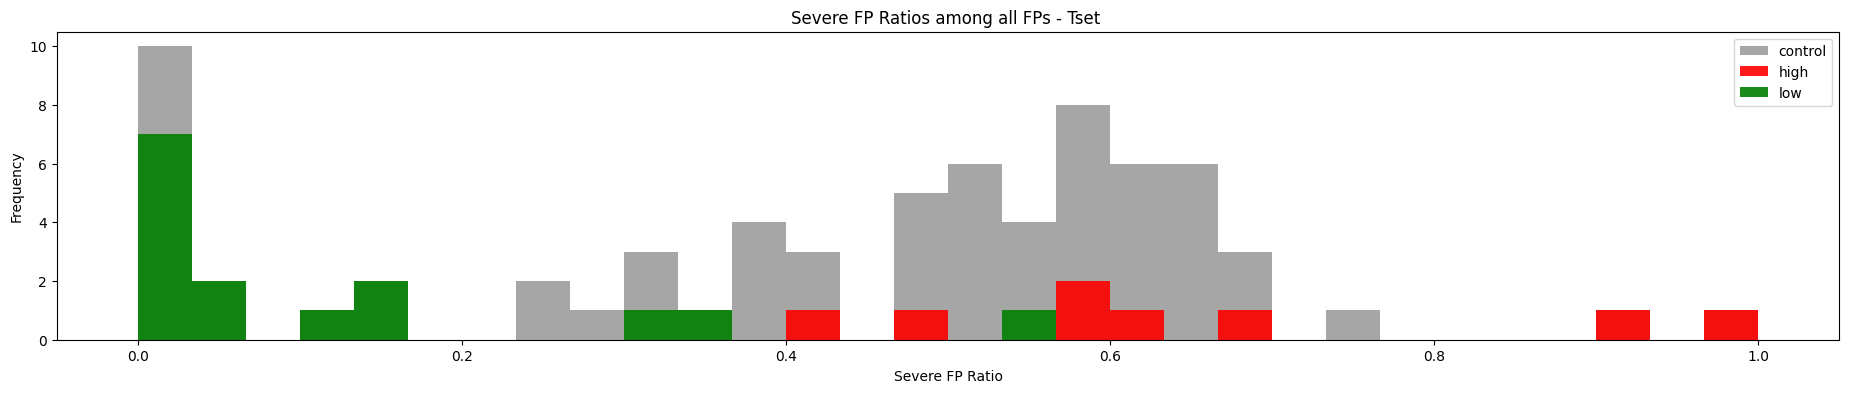

In [315]:
####                                                                                TESTING max_FP_severe_ratio_FPs
# Run the model selection function with the new parameters
selected_models_control = select_models_by_criteria(
    results_dist_disc,
    mean_precision_range=(0, 100),
    seed_precision_range=(0, 100),
    seed_recall_range=(1, 100),
    min_seeds_per_model=1,
    max_zero_precision_seeds=70,
    min_ratio_difference= None,
    max_ratio_difference=None,
    seed_min_TPminusFP_greaterEqual=None,
    max_FP_severe_ratio_FPs= None,
    max_FP_severe_ratio_FPs_andTPs=None,
    min_FP_severe_ratio_FPs=None,
    min_FP_severe_ratio_FPs_andTPs=None,
    max_seed_severe_FPs_high_bracket=None,
    min_seed_TPs_high_bracket=None,  # NEW: Add the parameter here
    random_seed=42,
    max_models_to_return=70
)

selected_models_test_LOW_ratio___fp_severe_ratio_fps = select_models_by_criteria(
    results_dist_disc,
    mean_precision_range=(0, 100),
    seed_precision_range=(0, 100),
    seed_recall_range=(1, 100),
    min_seeds_per_model=1,
    max_zero_precision_seeds=70,
    min_ratio_difference=None,
    max_ratio_difference=None,
    seed_min_TPminusFP_greaterEqual=None,
    max_FP_severe_ratio_FPs= .2,
    max_FP_severe_ratio_FPs_andTPs=None,
    min_FP_severe_ratio_FPs=None,
    min_FP_severe_ratio_FPs_andTPs=None,
    max_seed_severe_FPs_high_bracket=None,
    min_seed_TPs_high_bracket=None,  # NEW: Add the parameter here
    random_seed=42,
    max_models_to_return=70
)


selected_models_test_HIGH_ratio___fp_severe_ratio_fps = select_models_by_criteria(
    results_dist_disc,
    mean_precision_range=(0, 100),
    seed_precision_range=(0, 100),
    seed_recall_range=(1, 100),
    min_seeds_per_model=1,
    max_zero_precision_seeds=70,
    min_ratio_difference= None,
    max_ratio_difference=None,
    seed_min_TPminusFP_greaterEqual=None,
    max_FP_severe_ratio_FPs= None,
    max_FP_severe_ratio_FPs_andTPs=None,
    min_FP_severe_ratio_FPs= .6,
    min_FP_severe_ratio_FPs_andTPs=None,
    max_seed_severe_FPs_high_bracket=None,
    min_seed_TPs_high_bracket=None,  # NEW: Add the parameter here
    random_seed=42,
    max_models_to_return=70
)

selected_models_control_TEST = recompute_selected_models_on_Tset(results_dist_disc_Tset_same_seeds_organized,
                                      selected_models_control,
                                      brackets=((0.5, 0.7), (0.7, 1.0)))

selected_models_test_LOW_ratio___fp_severe_ratio_fps_TEST = recompute_selected_models_on_Tset(results_dist_disc_Tset_same_seeds_organized,
                                      selected_models_test_LOW_ratio___fp_severe_ratio_fps,
                                      brackets=((0.5, 0.7), (0.7, 1.0)))

selected_models_test_HIGH_ratio___fp_severe_ratio_fps_TEST = recompute_selected_models_on_Tset(results_dist_disc_Tset_same_seeds_organized,
                                      selected_models_test_HIGH_ratio___fp_severe_ratio_fps,
                                      brackets=((0.5, 0.7), (0.7, 1.0)))




# Print summary of selected models
print(f"Models Selected control: {len(selected_models_control)}")
total_seeds = sum(len(model["selected_seeds"]) for model in selected_models_control)
print(f"Total seeds selected control: {total_seeds}")

print(f"Models Selected HIGH: {len(selected_models_test_HIGH_ratio___fp_severe_ratio_fps)}")
total_seeds = sum(len(model["selected_seeds"]) for model in selected_models_test_HIGH_ratio___fp_severe_ratio_fps)
print(f"Total seeds selected HIGH: {total_seeds}")

print(f"Models Selected LOW: {len(selected_models_test_LOW_ratio___fp_severe_ratio_fps)}")
total_seeds = sum(len(model["selected_seeds"]) for model in selected_models_test_LOW_ratio___fp_severe_ratio_fps)
print(f"Total seeds selected LOW: {total_seeds}")


#his tof all severe FPs among all MODELS

list_ALL_fp_severe_ratio_fps_control = []
for i in selected_models_control:
    list_ALL_fp_severe_ratio_fps_control.append(i["fp_severe_ratio_fps"])

list_ALL_fp_severe_ratio_fps_low = []
for i in selected_models_test_LOW_ratio___fp_severe_ratio_fps:
    list_ALL_fp_severe_ratio_fps_low.append(i["fp_severe_ratio_fps"])

list_ALL_fp_severe_ratio_fps_high = []
for i in selected_models_test_HIGH_ratio___fp_severe_ratio_fps: 
    list_ALL_fp_severe_ratio_fps_high.append(i["fp_severe_ratio_fps"])

######################
list_ALL_fp_severe_ratio_fps_control_TEST = []
for i in selected_models_control_TEST:
    list_ALL_fp_severe_ratio_fps_control_TEST.append(i["fp_severe_ratio_fps"])

list_ALL_fp_severe_ratio_fps_low_TEST = []
for i in selected_models_test_LOW_ratio___fp_severe_ratio_fps_TEST:
    list_ALL_fp_severe_ratio_fps_low_TEST.append(i["fp_severe_ratio_fps"])

list_ALL_fp_severe_ratio_fps_high_TEST = []
for i in selected_models_test_HIGH_ratio___fp_severe_ratio_fps_TEST:
    list_ALL_fp_severe_ratio_fps_high_TEST.append(i["fp_severe_ratio_fps"])


all_vals = list_ALL_fp_severe_ratio_fps_control + list_ALL_fp_severe_ratio_fps_low + list_ALL_fp_severe_ratio_fps_high
Bins = np.linspace(min(all_vals), max(all_vals), 31)  # 30 bins, same edges for all

plt.figure(figsize = (23 , 4))
plt.hist(list_ALL_fp_severe_ratio_fps_control , bins=Bins , alpha = 0.7 , label = "control" , color = "grey")
plt.hist(list_ALL_fp_severe_ratio_fps_high , bins = Bins , alpha = 0.9 , label = "high" , color = "red")
plt.hist(list_ALL_fp_severe_ratio_fps_low , bins = Bins , alpha = 0.9 , label = "low" , color = "green")
plt.title("Severe FP Ratios among all FPs - Vset ")
plt.xlabel("Severe FP Ratio")
plt.ylabel("Frequency")
plt.legend()
plt.show()


all_vals = list_ALL_fp_severe_ratio_fps_control_TEST + list_ALL_fp_severe_ratio_fps_low_TEST + list_ALL_fp_severe_ratio_fps_high_TEST
Bins = np.linspace(min(all_vals), max(all_vals), 31)  # 30 bins, same edges for all

plt.figure(figsize = (23 , 4))
plt.hist(list_ALL_fp_severe_ratio_fps_control_TEST , bins=Bins , alpha = 0.7 , label = "control" , color = "grey")
plt.hist(list_ALL_fp_severe_ratio_fps_high_TEST , bins = Bins , alpha = 0.9 , label = "high" , color = "red")
plt.hist(list_ALL_fp_severe_ratio_fps_low_TEST , bins = Bins , alpha = 0.9 , label = "low" , color = "green")
plt.title("Severe FP Ratios among all FPs - Tset ")
plt.xlabel("Severe FP Ratio")
plt.ylabel("Frequency")
plt.legend()
plt.show()








Models Selected control: 70
Total seeds selected control: 3962
Models Selected POS: 50
Total seeds selected POS: 2989
Models Selected NEG: 11
Total seeds selected NEG: 535


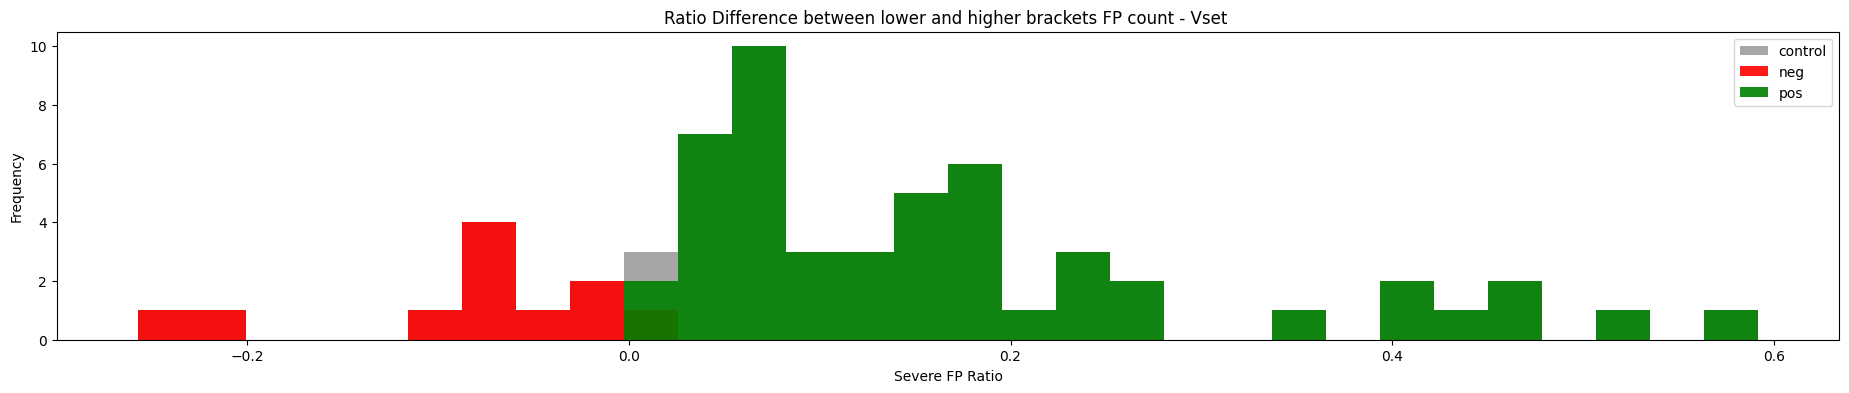

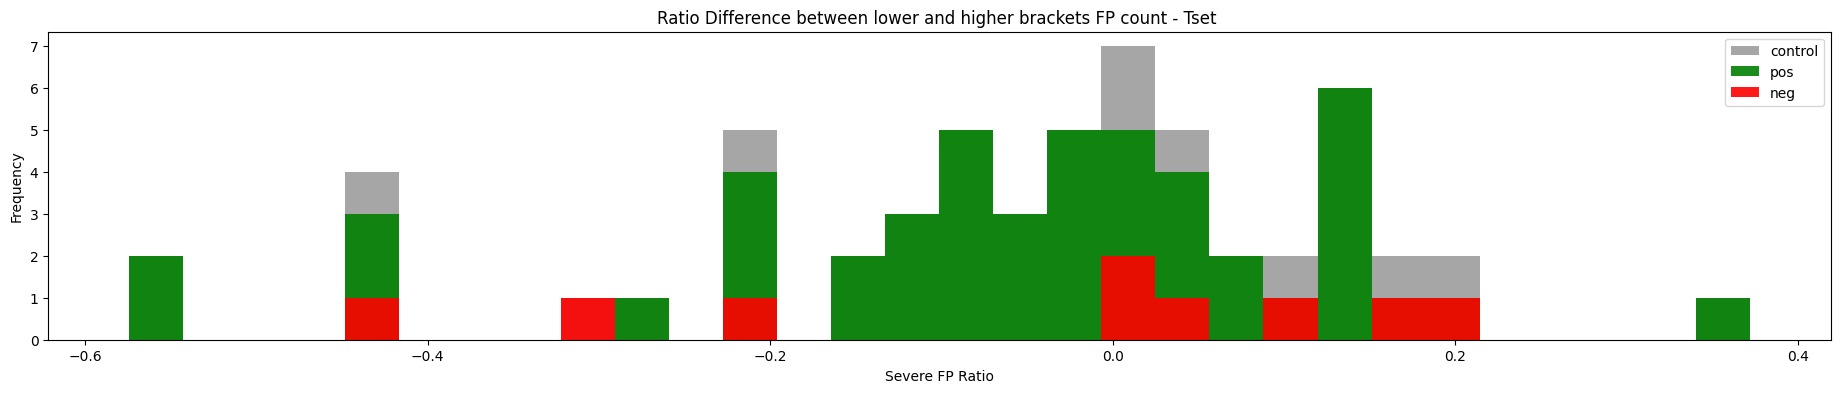

In [314]:
####                                                                                TESTING min_ratio_difference between higher and lower brackets FP count 

####                                                                                TESTING max_FP_severe_ratio_FPs
# Run the model selection function with the new parameters
selected_models_control = select_models_by_criteria(
    results_dist_disc,
    mean_precision_range=(0, 100),
    seed_precision_range=(0, 100),
    seed_recall_range=(1, 100),
    min_seeds_per_model=1,
    max_zero_precision_seeds=70,
    min_ratio_difference= None,
    max_ratio_difference=None,
    seed_min_TPminusFP_greaterEqual=None,
    max_FP_severe_ratio_FPs= None,
    max_FP_severe_ratio_FPs_andTPs=None,
    min_FP_severe_ratio_FPs=None,
    min_FP_severe_ratio_FPs_andTPs=None,
    max_seed_severe_FPs_high_bracket=None,
    min_seed_TPs_high_bracket=None,  # NEW: Add the parameter here
    random_seed=42,
    max_models_to_return=70
)

selected_models_test_POS_ratio = select_models_by_criteria(
    results_dist_disc,
    mean_precision_range=(0, 100),
    seed_precision_range=(0, 100),
    seed_recall_range=(1, 100),
    min_seeds_per_model=1,
    max_zero_precision_seeds=70,
    min_ratio_difference=0,
    max_ratio_difference=None,
    seed_min_TPminusFP_greaterEqual=None,
    max_FP_severe_ratio_FPs= None,
    max_FP_severe_ratio_FPs_andTPs=None,
    min_FP_severe_ratio_FPs=None,
    min_FP_severe_ratio_FPs_andTPs=None,
    max_seed_severe_FPs_high_bracket=None,
    min_seed_TPs_high_bracket=None,  # NEW: Add the parameter here
    random_seed=42,
    max_models_to_return=70
)


selected_models_test_NEG_ratio = select_models_by_criteria(
    results_dist_disc,
    mean_precision_range=(0, 100),
    seed_precision_range=(0, 100),
    seed_recall_range=(1, 100),
    min_seeds_per_model=1,
    max_zero_precision_seeds=70,
    min_ratio_difference= None,
    max_ratio_difference= 0,
    seed_min_TPminusFP_greaterEqual=None,
    max_FP_severe_ratio_FPs= None,
    max_FP_severe_ratio_FPs_andTPs=None,
    min_FP_severe_ratio_FPs= None,
    min_FP_severe_ratio_FPs_andTPs=None,
    max_seed_severe_FPs_high_bracket=None,
    min_seed_TPs_high_bracket=None,  # NEW: Add the parameter here
    random_seed=42,
    max_models_to_return=70
)

selected_models_control_TEST = recompute_selected_models_on_Tset(results_dist_disc_Tset_same_seeds_organized,
                                      selected_models_control,
                                      brackets=((0.5, 0.7), (0.7, 1.0)))

selected_models_test_POS_ratio_TEST = recompute_selected_models_on_Tset(results_dist_disc_Tset_same_seeds_organized,
                                      selected_models_test_POS_ratio,
                                      brackets=((0.5, 0.7), (0.7, 1.0)))

selected_models_test_NEG_ratio_TEST = recompute_selected_models_on_Tset(results_dist_disc_Tset_same_seeds_organized,
                                      selected_models_test_NEG_ratio,
                                      brackets=((0.5, 0.7), (0.7, 1.0)))




# Print summary of selected models
print(f"Models Selected control: {len(selected_models_control)}")
total_seeds = sum(len(model["selected_seeds"]) for model in selected_models_control)
print(f"Total seeds selected control: {total_seeds}")

print(f"Models Selected POS: {len(selected_models_test_POS_ratio)}")
total_seeds = sum(len(model["selected_seeds"]) for model in selected_models_test_POS_ratio)
print(f"Total seeds selected POS: {total_seeds}")

print(f"Models Selected NEG: {len(selected_models_test_NEG_ratio)}")
total_seeds = sum(len(model["selected_seeds"]) for model in selected_models_test_NEG_ratio)
print(f"Total seeds selected NEG: {total_seeds}")


#his tof all severe FPs among all MODELS

list_ALL_control = []
for i in selected_models_control:
    list_ALL_control.append(i["ratio_difference"])

list_ALL_control = [i for i in list_ALL_control if i is not None]

list_ALL_neg = []
for i in selected_models_test_NEG_ratio:
    list_ALL_neg.append(i["ratio_difference"])

list_ALL_pos = []
for i in selected_models_test_POS_ratio:
    list_ALL_pos.append(i["ratio_difference"])

######################
list_ALL_control_TEST = []
for i in selected_models_control_TEST:
    list_ALL_control_TEST.append(i["ratio_difference"])

list_ALL_control_TEST = [i for i in list_ALL_control_TEST if i is not None]

list_ALL_neg_TEST = []
for i in selected_models_test_NEG_ratio_TEST:
    list_ALL_neg_TEST.append(i["ratio_difference"])

list_ALL_neg_TEST = [i for i in list_ALL_neg_TEST if i is not None]

list_ALL_pos_TEST = []
for i in selected_models_test_POS_ratio_TEST:
    list_ALL_pos_TEST.append(i["ratio_difference"])

list_ALL_pos_TEST = [i for i in list_ALL_pos_TEST if i is not None]


all_vals = list_ALL_control + list_ALL_neg + list_ALL_pos
Bins = np.linspace(min(all_vals), max(all_vals), 31)  # 30 bins, same edges for all



plt.figure(figsize = (23 , 4))
plt.hist(list_ALL_control , bins=Bins , alpha = 0.7 , label = "control" , color = "grey")
plt.hist(list_ALL_neg , bins = Bins , alpha = 0.9 , label = "neg" , color = "red")
plt.hist(list_ALL_pos , bins = Bins , alpha = 0.9 , label = "pos" , color = "green")
plt.title("Ratio Difference between lower and higher brackets FP count - Vset ")
plt.xlabel("Severe FP Ratio")
plt.ylabel("Frequency")
plt.legend()
plt.show()


all_vals = list_ALL_control_TEST + list_ALL_neg_TEST + list_ALL_pos_TEST
Bins = np.linspace(min(all_vals), max(all_vals), 31)  # 30 bins, same edges for all


plt.figure(figsize = (23 , 4))
plt.hist(list_ALL_control_TEST , bins= Bins , alpha = 0.7 , label = "control" , color = "grey")
plt.hist(list_ALL_pos_TEST , bins = Bins , alpha = 0.9 , label = "pos" , color = "green")
plt.hist(list_ALL_neg_TEST , bins = Bins , alpha = 0.9 , label = "neg" , color = "red")
plt.title("Ratio Difference between lower and higher brackets FP count - Tset ")
plt.xlabel("Severe FP Ratio")
plt.ylabel("Frequency")
plt.legend()
plt.show()








In [298]:
selected_models_test_NEG_ratio[0]

{'combo_index': 25,
 'parameters': {'binary_0_1_cutoff_ret_rate_percentage': 0.1,
  'learning_rate': 0.005,
  'num_epochs': 700,
  'batch_size': 70,
  'use_bidirectional': False,
  'lag': 2,
  'input_size': 12,
  'hidden_size': 35,
  'num_layers': 2,
  'use_monthly_dfs_only': True,
  'use_binary_0_1_retRate': False,
  'use_custom_loss_function_BCE_THRESH': False,
  'use_custom_loss_function_BCE_THRESH_AND_SEVERITY': False,
  'use_LOW_weights_for_BCE_custom_loss': True,
  'pred_threshold_sigmoid01_up': None,
  'use_binary_neg1_1': False,
  'use_ret_rate': False,
  'use_print_acc': False,
  'use_dropout': False,
  'use_class_weighting': True,
  'is_deterministic': True,
  'seed_num': 42,
  'use_existing_lagged_data': True,
  'use_dynamic_weights': False,
  'use_binary_0_1_retRate_custom_neg': False,
  'use_binary_0_1_retRate_custom_pos': True,
  'POS_weight_multiplier': 1.3,
  'use_rolling_fixed_train_size': False,
  'use_existing_initial_weights': False,
  'state_dict': None,
  'use_USO

Model 25: 8 FPs in 0.5-0.7, 157 FPs in 0.7-1.0
Model 28: 7 FPs in 0.5-0.7, 95 FPs in 0.7-1.0
Model 35: 254 FPs in 0.5-0.7, 27 FPs in 0.7-1.0
Model 61: 127 FPs in 0.5-0.7, 1 FPs in 0.7-1.0
Model 62: 40 FPs in 0.5-0.7, 37 FPs in 0.7-1.0
Model 65: 12 FPs in 0.5-0.7, 34 FPs in 0.7-1.0
Model 69: 23 FPs in 0.5-0.7, 65 FPs in 0.7-1.0


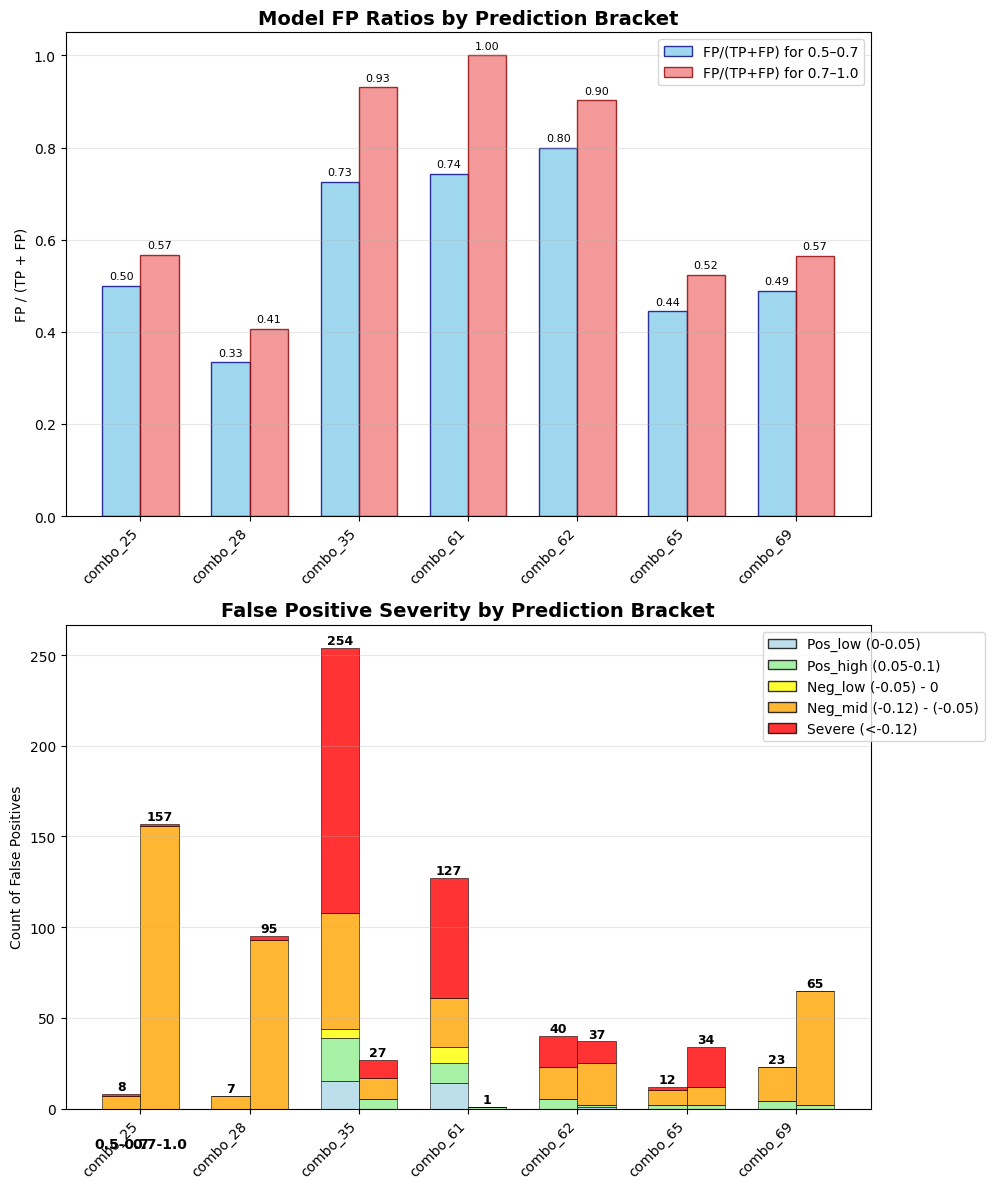


SEVERE CASE PROPORTIONS BY BRACKET
combo_25:
  Low bracket (0.5-0.7): 12.5% severe (1/8)
  High bracket (0.7-1.0): 0.6% severe (1/157)
----------------------------------------
combo_28:
  Low bracket (0.5-0.7): 0.0% severe (0/7)
  High bracket (0.7-1.0): 2.1% severe (2/95)
----------------------------------------
combo_35:
  Low bracket (0.5-0.7): 57.5% severe (146/254)
  High bracket (0.7-1.0): 37.0% severe (10/27)
----------------------------------------
combo_61:
  Low bracket (0.5-0.7): 52.0% severe (66/127)
  High bracket (0.7-1.0): 0.0% severe (0/1)
----------------------------------------
combo_62:
  Low bracket (0.5-0.7): 42.5% severe (17/40)
  High bracket (0.7-1.0): 32.4% severe (12/37)
----------------------------------------
combo_65:
  Low bracket (0.5-0.7): 16.7% severe (2/12)
  High bracket (0.7-1.0): 64.7% severe (22/34)
----------------------------------------
combo_69:
  Low bracket (0.5-0.7): 0.0% severe (0/23)
  High bracket (0.7-1.0): 0.0% severe (0/65)
----------

In [294]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# Define consistent color scheme for severity categories
SEVERITY_COLORS = {
    "Pos_low (0-0.05)": 'lightblue',
    "Pos_high (0.05-0.1)": 'lightgreen',
    "Neg_low (-0.05) - 0": 'yellow',
    "Neg_mid (-0.12) - (-0.05)": 'orange',
    "Severe (<-0.12)": 'red',
    "Other": 'gray'
}

def classify_severity_10_percent_pos(actual_value):
    """Classify actual values into severity categories"""
    if 0 < actual_value <= 0.05:
        return "Pos_low (0-0.05)"
    elif 0.05 < actual_value <= 0.1:
        return "Pos_high (0.05-0.1)"
    elif 0 > actual_value >= -0.05:
        return "Neg_low (-0.05) - 0"
    elif -0.05 > actual_value > -0.12:
        return "Neg_mid (-0.12) - (-0.05)"
    elif actual_value <= -0.12:
        return "Severe (<-0.12)"
    return "Other"

# Expecting `selected_models` to be the function's output list
if not selected_models:
    print("No models to plot.")
else:
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(max(10, len(selected_models)*0.8), 12))
    
    # --- Plot 1: FP Ratios (existing plot) ---
    labels = [f"combo_{m['combo_index']}" for m in selected_models]
    r_05_07 = [m.get("fp_tp_ratios", {}).get("0.5-0.7", np.nan) for m in selected_models]
    r_07_10 = [m.get("fp_tp_ratios", {}).get("0.7-1.0", np.nan) for m in selected_models]

    x = np.arange(len(labels))
    width = 0.35

    # FP Ratio plot
    b1 = ax1.bar(x - width/2, r_05_07, width, label='FP/(TP+FP) for 0.5–0.7', 
                 alpha=0.8, color='skyblue', edgecolor='navy')
    b2 = ax1.bar(x + width/2, r_07_10, width, label='FP/(TP+FP) for 0.7–1.0', 
                 alpha=0.8, color='lightcoral', edgecolor='darkred')

    ax1.set_xticks(x)
    ax1.set_xticklabels(labels, rotation=45, ha='right')
    ax1.set_ylabel('FP / (TP + FP)')
    ax1.set_title('Model FP Ratios by Prediction Bracket', fontsize=14, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for i, (val1, val2) in enumerate(zip(r_05_07, r_07_10)):
        if not np.isnan(val1):
            ax1.text(i - width/2, val1 + 0.01, f'{val1:.2f}', 
                    ha='center', va='bottom', fontsize=8)
        if not np.isnan(val2):
            ax1.text(i + width/2, val2 + 0.01, f'{val2:.2f}', 
                    ha='center', va='bottom', fontsize=8)

    # --- Plot 2: Severity Breakdown (CORRECTED - using raw data from results_dist_disc) ---
    severity_categories = ["Pos_low (0-0.05)", "Pos_high (0.05-0.1)", 
                          "Neg_low (-0.05) - 0", "Neg_mid (-0.12) - (-0.05)", 
                          "Severe (<-0.12)"]
    
    # Prepare severity data for each model
    severity_data_05_07 = []
    severity_data_07_10 = []
    
    for model in selected_models:
        combo_idx = model['combo_index']
        
        # Find the corresponding model in results_dist_disc
        original_model = None
        for m in results_dist_disc:
            if m.get('combo_index') == combo_idx:
                original_model = m
                break
        
        if original_model is None:
            print(f"Warning: Could not find model {combo_idx} in results_dist_disc")
            # Add empty data
            severity_data_05_07.append({cat: 0 for cat in severity_categories})
            severity_data_07_10.append({cat: 0 for cat in severity_categories})
            continue
        
        # Initialize severity counts for this model
        model_severity_05_07 = {cat: 0 for cat in severity_categories}
        model_severity_07_10 = {cat: 0 for cat in severity_categories}
        
        # Process each seed in the original model data
        for seed_entry in original_model.get('per_seed_all_results', []):
            result_entry = seed_entry.get('result_entry', {})
            all_preds = result_entry.get('all_preds', [])
            all_actuals = result_entry.get('all_actuals', [])
            
            # Check if we have raw_actuals, otherwise use all_actuals
            raw_actuals = result_entry.get('raw_actuals', all_actuals)
            
            # Process each fold
            for pred_fold, actual_fold, raw_fold in zip(all_preds, all_actuals, raw_actuals):
                for pred, actual, raw in zip(pred_fold, actual_fold, raw_fold):
                    # Only process false positives (pred > 0.5, actual <= 0.5)
                    if pred >= 0.5 and actual <= 0.5:
                        severity = classify_severity_10_percent_pos(raw)
                        
                        # Assign to appropriate bracket
                        if 0.5 <= pred < 0.7:
                            if severity in model_severity_05_07:
                                model_severity_05_07[severity] += 1
                        elif pred >= 0.7:
                            if severity in model_severity_07_10:
                                model_severity_07_10[severity] += 1
        
        severity_data_05_07.append(model_severity_05_07)
        severity_data_07_10.append(model_severity_07_10)
        
        # Print debug info
        total_fp_05_07 = sum(model_severity_05_07.values())
        total_fp_07_10 = sum(model_severity_07_10.values())
        print(f"Model {combo_idx}: {total_fp_05_07} FPs in 0.5-0.7, {total_fp_07_10} FPs in 0.7-1.0")
    
    # Prepare data for stacked bars
    low_bracket_data = {cat: [] for cat in severity_categories}
    high_bracket_data = {cat: [] for cat in severity_categories}
    
    for i in range(len(selected_models)):
        for cat in severity_categories:
            low_bracket_data[cat].append(severity_data_05_07[i].get(cat, 0))
            high_bracket_data[cat].append(severity_data_07_10[i].get(cat, 0))
    
    # Plot stacked bars for each bracket with proper color coding
    bottom_low = np.zeros(len(selected_models))
    bottom_high = np.zeros(len(selected_models))
    
    # Create legend handles for the severity categories
    legend_handles = []
    
    for i, cat in enumerate(severity_categories):
        color = SEVERITY_COLORS[cat]
        
        # Plot low bracket (0.5-0.7)
        ax2.bar(x - width/2, low_bracket_data[cat], width, bottom=bottom_low, 
                color=color, alpha=0.8, edgecolor='black', linewidth=0.5)
        
        # Plot high bracket (0.7-1.0)
        ax2.bar(x + width/2, high_bracket_data[cat], width, bottom=bottom_high, 
                color=color, alpha=0.8, edgecolor='black', linewidth=0.5)
        
        bottom_low += low_bracket_data[cat]
        bottom_high += high_bracket_data[cat]
        
        # Create legend entry
        legend_handles.append(plt.Rectangle((0,0), 1, 1, fc=color, alpha=0.8, 
                                          label=cat, edgecolor='black'))
    
    ax2.set_xticks(x)
    ax2.set_xticklabels(labels, rotation=45, ha='right')
    ax2.set_ylabel('Count of False Positives')
    ax2.set_title('False Positive Severity by Prediction Bracket', 
                 fontsize=14, fontweight='bold')
    ax2.legend(handles=legend_handles, loc='upper right', bbox_to_anchor=(1.15, 1))
    ax2.grid(True, alpha=0.3, axis='y')
    
    # Add total count labels above bars
    for i in range(len(selected_models)):
        total_low = sum(severity_data_05_07[i].values())
        total_high = sum(severity_data_07_10[i].values())
        
        if total_low > 0:
            ax2.text(i - width/2, total_low + 0.5, str(total_low), 
                    ha='center', va='bottom', fontsize=9, fontweight='bold')
        if total_high > 0:
            ax2.text(i + width/2, total_high + 0.5, str(total_high), 
                    ha='center', va='bottom', fontsize=9, fontweight='bold')
        
        # Add bracket labels below x-axis
        if i == 0:
            ax2.text(i - width/2, -max(np.max(bottom_high), 1)*0.1, '0.5-0.7', 
                    ha='center', va='top', fontsize=10, fontweight='bold')
            ax2.text(i + width/2, -max(np.max(bottom_high), 1)*0.1, '0.7-1.0', 
                    ha='center', va='top', fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()

    # Print summary statistics
    print("\n" + "="*60)
    print("SEVERE CASE PROPORTIONS BY BRACKET")
    print("="*60)
    for i, label in enumerate(labels):
        total_low = sum(severity_data_05_07[i].values())
        total_high = sum(severity_data_07_10[i].values())
        severe_low = severity_data_05_07[i].get("Severe (<-0.12)", 0)
        severe_high = severity_data_07_10[i].get("Severe (<-0.12)", 0)
        
        prop_low = (severe_low / total_low * 100) if total_low > 0 else 0
        prop_high = (severe_high / total_high * 100) if total_high > 0 else 0
        
        print(f"{label}:")
        print(f"  Low bracket (0.5-0.7): {prop_low:.1f}% severe ({severe_low}/{total_low})")
        print(f"  High bracket (0.7-1.0): {prop_high:.1f}% severe ({severe_high}/{total_high})")
        print("-" * 40)

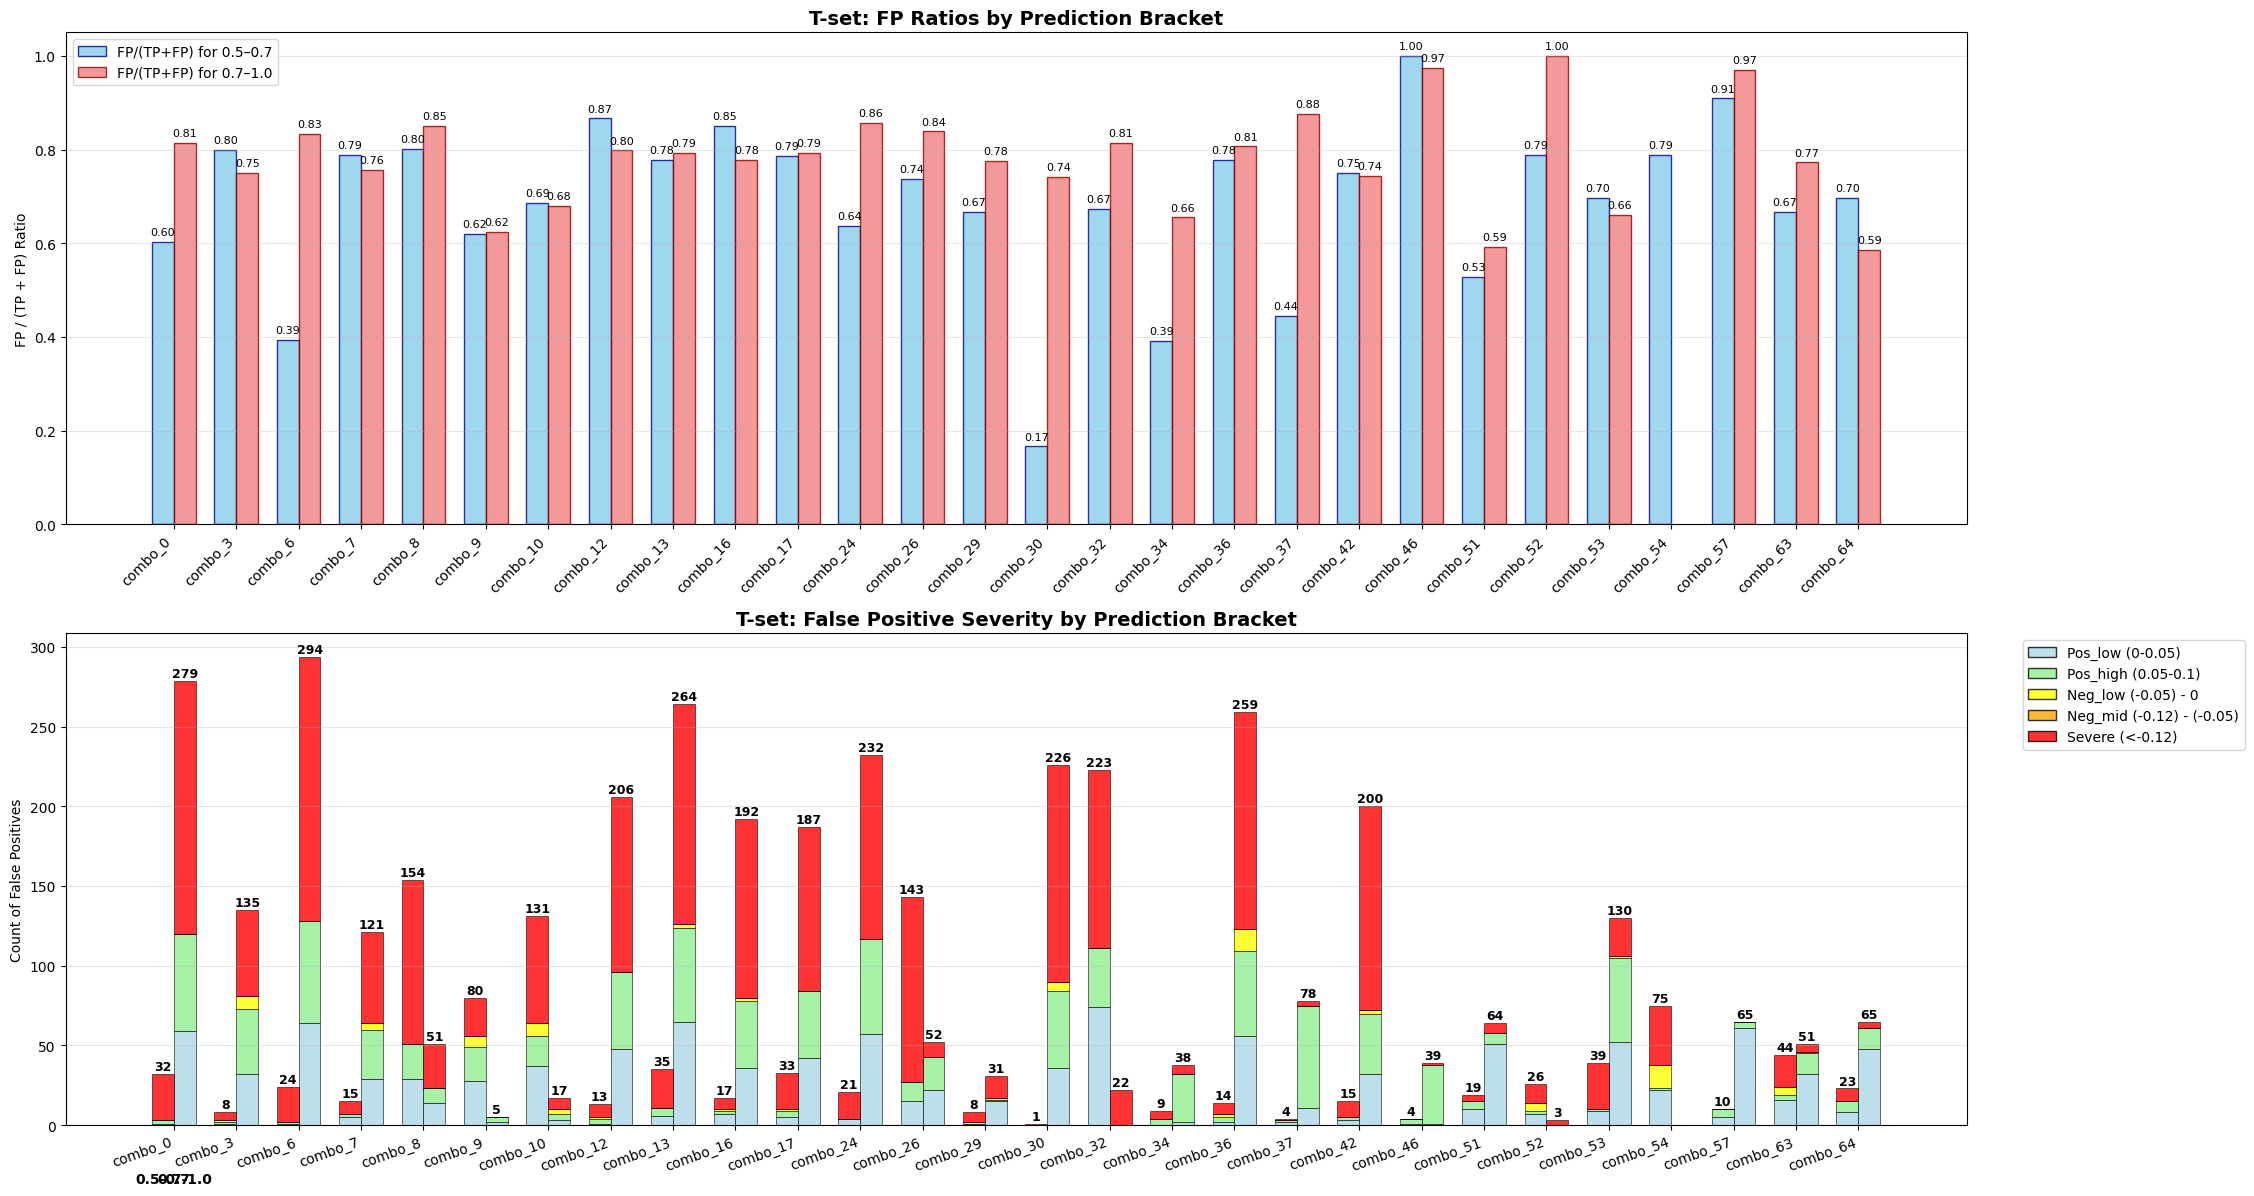


SEVERE CASE PROPORTIONS BY BRACKET
combo_0:
  Low bracket (0.5-0.7): 90.6% severe (29/32)
  High bracket (0.7-1.0): 57.0% severe (159/279)
----------------------------------------
combo_3:
  Low bracket (0.5-0.7): 62.5% severe (5/8)
  High bracket (0.7-1.0): 40.0% severe (54/135)
----------------------------------------
combo_6:
  Low bracket (0.5-0.7): 91.7% severe (22/24)
  High bracket (0.7-1.0): 56.5% severe (166/294)
----------------------------------------
combo_7:
  Low bracket (0.5-0.7): 53.3% severe (8/15)
  High bracket (0.7-1.0): 47.1% severe (57/121)
----------------------------------------
combo_8:
  Low bracket (0.5-0.7): 66.9% severe (103/154)
  High bracket (0.7-1.0): 54.9% severe (28/51)
----------------------------------------
combo_9:
  Low bracket (0.5-0.7): 30.0% severe (24/80)
  High bracket (0.7-1.0): 0.0% severe (0/5)
----------------------------------------
combo_10:
  Low bracket (0.5-0.7): 51.1% severe (67/131)
  High bracket (0.7-1.0): 41.2% severe (7/17)
-

In [316]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# Brackets to match your selection logic
BRACKETS = [(0.5, 0.7), (0.7, 1.0)]
BRACKET_KEYS = [f"{L}-{H}" for (L, H) in BRACKETS]

# Define consistent color scheme for severity categories
SEVERITY_COLORS = {
    "Pos_low (0-0.05)": 'lightblue',
    "Pos_high (0.05-0.1)": 'lightgreen',
    "Neg_low (-0.05) - 0": 'yellow',
    "Neg_mid (-0.12) - (-0.05)": 'orange',
    "Severe (<-0.12)": 'red',
    "Other": 'gray'
}

def classify_severity_10_percent_pos(actual_value):
    """Classify actual values into severity categories"""
    if 0 < actual_value <= 0.05:
        return "Pos_low (0-0.05)"
    elif 0.05 < actual_value <= 0.1:
        return "Pos_high (0.05-0.1)"
    elif 0 > actual_value >= -0.05:
        return "Neg_low (-0.05) - 0"
    elif -0.05 > actual_value > -0.12:
        return "Neg_mid (-0.12) - (-0.05)"
    elif actual_value <= -0.12:
        return "Severe (<-0.12)"
    return "Other"

def calc_fp_tp_ratios_for_model_tset(model_entry, brackets=BRACKETS):
    """Recompute FP/(TP+FP) per bracket for one T-set model entry."""
    bracket_counts = {f"{L}-{H}": {"TP": 0, "FP": 0} for (L, H) in brackets}
    severity_counts = {f"{L}-{H}": defaultdict(int) for (L, H) in brackets}

    for seed_entry in model_entry.get("per_seed_all_results", []):
        re = seed_entry["result_entry"]
        all_preds = re.get("all_preds", [])
        all_actuals = re.get("all_actuals", [])
        raw_actuals = re.get("raw_actuals")  # Use actuals if raw not available

        for pred_fold, actual_fold, raw_fold in zip(all_preds, all_actuals, raw_actuals):
            for pred, actual, raw in zip(pred_fold, actual_fold, raw_fold):
                true_positive = (actual > 0.5) and (pred >= 0.5)
                false_positive = (actual <= 0.5) and (pred >= 0.5)

                # assign into first matching bracket
                for (L, H) in brackets:
                    if L <= pred < H:
                        key = f"{L}-{H}"
                        if true_positive:
                            bracket_counts[key]["TP"] += 1
                        elif false_positive:
                            bracket_counts[key]["FP"] += 1
                            # Classify severity of false positive
                            severity = classify_severity_10_percent_pos(raw)
                            severity_counts[key][severity] += 1
                        break

    # convert to FP/(TP+FP)
    ratios = {}
    for k, c in bracket_counts.items():
        tp, fp = c["TP"], c["FP"]
        denom = tp + fp
        ratios[k] = (fp / denom) if denom > 0 else np.nan
    
    return ratios, severity_counts

# --- Build ratios and severity counts for T-set ---
tset_labels = []
tset_r_05_07 = []
tset_r_07_10 = []
tset_severity_05_07 = []  # Severity counts for 0.5-0.7 bracket
tset_severity_07_10 = []  # Severity counts for 0.7-1.0 bracket

for m in selected_models:
    combo_idx = m["combo_index"]
    t_match = next((x for x in results_dist_disc_Tset_same_seeds_organized
                    if x.get("combo_index") == combo_idx), None)
    
    if t_match is None:
        tset_labels.append(f"combo_{combo_idx}")
        tset_r_05_07.append(np.nan)
        tset_r_07_10.append(np.nan)
        tset_severity_05_07.append(defaultdict(int))
        tset_severity_07_10.append(defaultdict(int))
        continue

    ratios, severity_counts = calc_fp_tp_ratios_for_model_tset(t_match)
    tset_labels.append(f"combo_{combo_idx}")
    tset_r_05_07.append(ratios.get("0.5-0.7", np.nan))
    tset_r_07_10.append(ratios.get("0.7-1.0", np.nan))
    tset_severity_05_07.append(severity_counts.get("0.5-0.7", defaultdict(int)))
    tset_severity_07_10.append(severity_counts.get("0.7-1.0", defaultdict(int)))

# --- Create the plots ---
if not tset_labels:
    print("No T-set models to plot.")
else:
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(max(10, len(tset_labels)*0.8), 12))
    
    # Plot 1: FP Ratios (existing plot)
    x = np.arange(len(tset_labels))
    width = 0.35

    # FP Ratio plot
    bars1 = ax1.bar(x - width/2, tset_r_05_07, width, label='FP/(TP+FP) for 0.5–0.7', 
                   alpha=0.8, color='skyblue', edgecolor='navy', linewidth=1)
    bars2 = ax1.bar(x + width/2, tset_r_07_10, width, label='FP/(TP+FP) for 0.7–1.0', 
                   alpha=0.8, color='lightcoral', edgecolor='darkred', linewidth=1)

    ax1.set_xticks(x)
    ax1.set_xticklabels(tset_labels, rotation=45, ha='right')
    ax1.set_ylabel('FP / (TP + FP) Ratio')
    ax1.set_title('T-set: FP Ratios by Prediction Bracket', fontsize=14, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for i, (val1, val2) in enumerate(zip(tset_r_05_07, tset_r_07_10)):
        if not np.isnan(val1):
            ax1.text(i - width/2, val1 + 0.01, f'{val1:.2f}', 
                    ha='center', va='bottom', fontsize=8)
        if not np.isnan(val2):
            ax1.text(i + width/2, val2 + 0.01, f'{val2:.2f}', 
                    ha='center', va='bottom', fontsize=8)

    # --- Plot 2: Severity Breakdown (NEW) ---
    severity_categories = ["Pos_low (0-0.05)", "Pos_high (0.05-0.1)", 
                          "Neg_low (-0.05) - 0", "Neg_mid (-0.12) - (-0.05)", 
                          "Severe (<-0.12)"]
    
    # Prepare data for stacked bars
    low_bracket_data = {cat: [] for cat in severity_categories}
    high_bracket_data = {cat: [] for cat in severity_categories}
    
    for i in range(len(tset_labels)):
        for cat in severity_categories:
            low_bracket_data[cat].append(tset_severity_05_07[i].get(cat, 0))
            high_bracket_data[cat].append(tset_severity_07_10[i].get(cat, 0))
    
    # Plot stacked bars for each bracket with proper color coding
    bottom_low = np.zeros(len(tset_labels))
    bottom_high = np.zeros(len(tset_labels))
    
    # Create legend handles for the severity categories
    legend_handles = []
    
    for i, cat in enumerate(severity_categories):
        color = SEVERITY_COLORS[cat]
        
        # Plot low bracket (0.5-0.7)
        ax2.bar(x - width/2, low_bracket_data[cat], width, bottom=bottom_low, 
                color=color, alpha=0.8, edgecolor='black', linewidth=0.5)
        
        # Plot high bracket (0.7-1.0)
        ax2.bar(x + width/2, high_bracket_data[cat], width, bottom=bottom_high, 
                color=color, alpha=0.8, edgecolor='black', linewidth=0.5)
        
        bottom_low += low_bracket_data[cat]
        bottom_high += high_bracket_data[cat]
        
        # Create legend entry
        legend_handles.append(plt.Rectangle((0,0), 1, 1, fc=color, alpha=0.8, 
                                          label=cat, edgecolor='black'))
    
    ax2.set_xticks(x)
    ax2.set_xticklabels(tset_labels, rotation=20, ha='right')
    ax2.set_ylabel('Count of False Positives')
    ax2.set_title('T-set: False Positive Severity by Prediction Bracket', 
                 fontsize=14, fontweight='bold')
    ax2.legend(handles=legend_handles, loc='upper right', bbox_to_anchor=(1.15, 1))
    ax2.grid(True, alpha=0.3, axis='y')
    
    # Add total count labels above bars
    for i in range(len(tset_labels)):
        total_low = sum(tset_severity_05_07[i].values())
        total_high = sum(tset_severity_07_10[i].values())
        
        if total_low > 0:
            ax2.text(i - width/2, total_low + 0.5, str(total_low), 
                    ha='center', va='bottom', fontsize=9, fontweight='bold')
        if total_high > 0:
            ax2.text(i + width/2, total_high + 0.5, str(total_high), 
                    ha='center', va='bottom', fontsize=9, fontweight='bold')
        
        # Add bracket labels below x-axis
        if i == 0:
            ax2.text(i - width/2, -max(bottom_high)*0.1, '0.5-0.7', 
                    ha='center', va='top', fontsize=10, fontweight='bold')
            ax2.text(i + width/2, -max(bottom_high)*0.1, '0.7-1.0', 
                    ha='center', va='top', fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()

    # Print summary statistics
    print("\n" + "="*60)
    print("SEVERE CASE PROPORTIONS BY BRACKET")
    print("="*60)
    for i, label in enumerate(tset_labels):
        total_low = sum(tset_severity_05_07[i].values())
        total_high = sum(tset_severity_07_10[i].values())
        severe_low = tset_severity_05_07[i].get("Severe (<-0.12)", 0)
        severe_high = tset_severity_07_10[i].get("Severe (<-0.12)", 0)
        
        prop_low = (severe_low / total_low * 100) if total_low > 0 else 0
        prop_high = (severe_high / total_high * 100) if total_high > 0 else 0
        
        print(f"{label}:")
        print(f"  Low bracket (0.5-0.7): {prop_low:.1f}% severe ({severe_low}/{total_low})")
        print(f"  High bracket (0.7-1.0): {prop_high:.1f}% severe ({severe_high}/{total_high})")
        print("-" * 40)

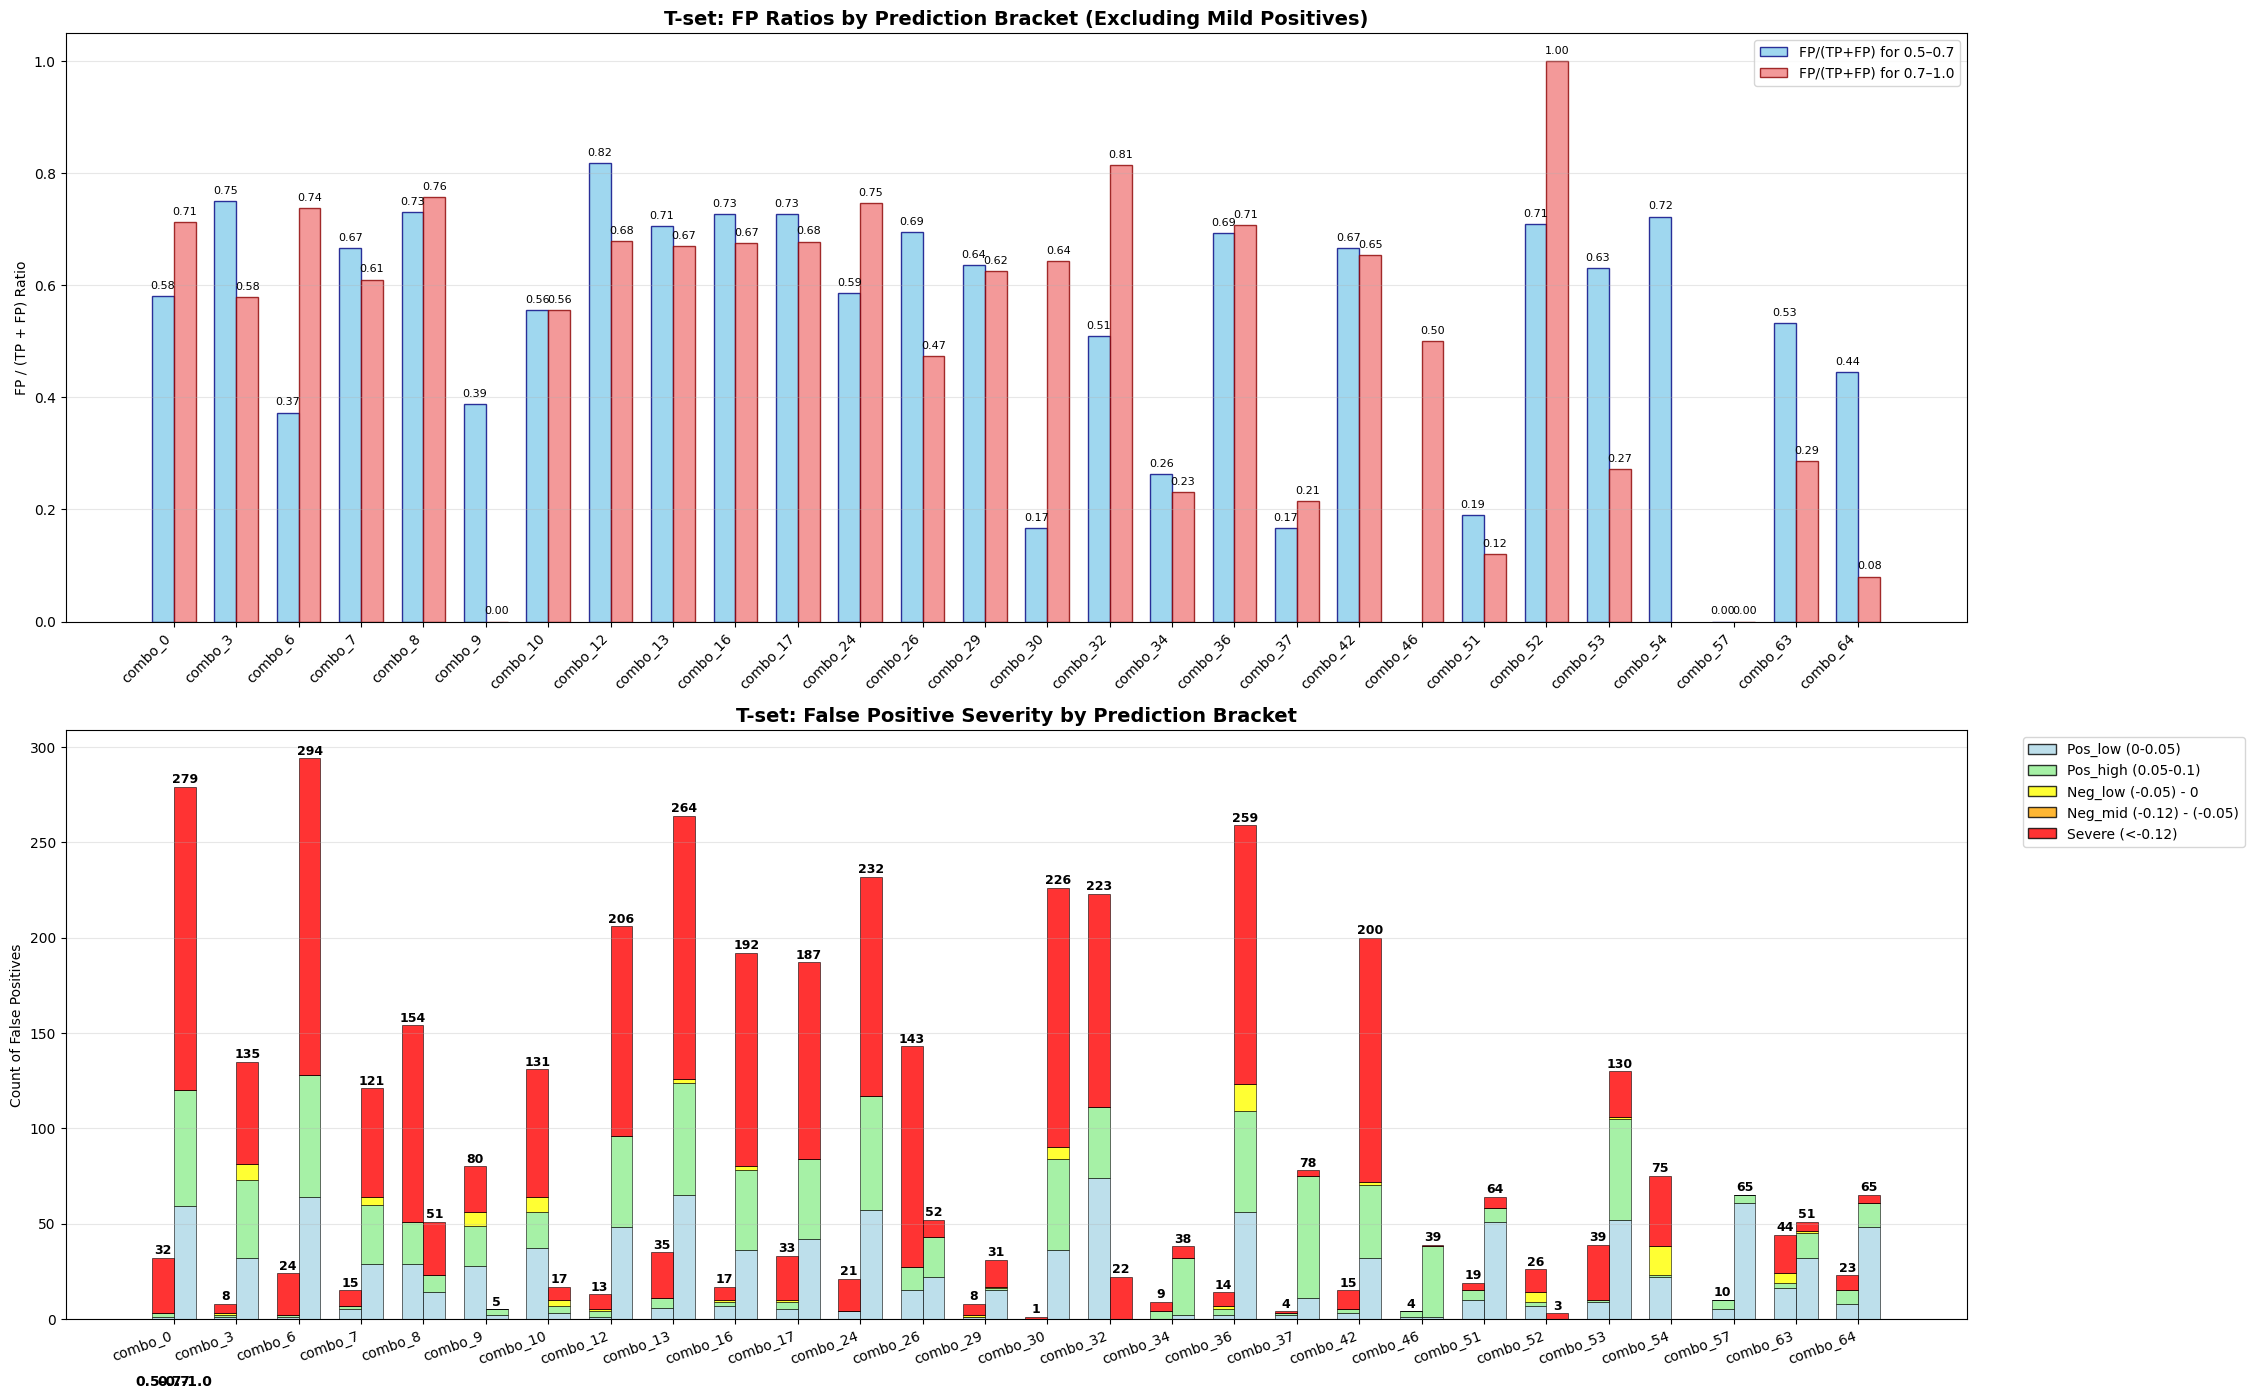


SEVERE CASE PROPORTIONS BY BRACKET
combo_0:
  Low bracket (0.5-0.7): 90.6% severe (29/32)
  High bracket (0.7-1.0): 57.0% severe (159/279)
----------------------------------------
combo_3:
  Low bracket (0.5-0.7): 62.5% severe (5/8)
  High bracket (0.7-1.0): 40.0% severe (54/135)
----------------------------------------
combo_6:
  Low bracket (0.5-0.7): 91.7% severe (22/24)
  High bracket (0.7-1.0): 56.5% severe (166/294)
----------------------------------------
combo_7:
  Low bracket (0.5-0.7): 53.3% severe (8/15)
  High bracket (0.7-1.0): 47.1% severe (57/121)
----------------------------------------
combo_8:
  Low bracket (0.5-0.7): 66.9% severe (103/154)
  High bracket (0.7-1.0): 54.9% severe (28/51)
----------------------------------------
combo_9:
  Low bracket (0.5-0.7): 30.0% severe (24/80)
  High bracket (0.7-1.0): 0.0% severe (0/5)
----------------------------------------
combo_10:
  Low bracket (0.5-0.7): 51.1% severe (67/131)
  High bracket (0.7-1.0): 41.2% severe (7/17)
-

In [317]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# Brackets to match your selection logic
BRACKETS = [(0.5, 0.7), (0.7, 1.0)]
BRACKET_KEYS = [f"{L}-{H}" for (L, H) in BRACKETS]

# Define consistent color scheme for severity categories
SEVERITY_COLORS = {
    "Pos_low (0-0.05)": 'lightblue',
    "Pos_high (0.05-0.1)": 'lightgreen',
    "Neg_low (-0.05) - 0": 'yellow',
    "Neg_mid (-0.12) - (-0.05)": 'orange',
    "Severe (<-0.12)": 'red',
    "Other": 'gray'
}

def classify_severity_10_percent_pos(actual_value):
    """Classify actual values into severity categories"""
    if 0 < actual_value <= 0.05:
        return "Pos_low (0-0.05)"
    elif 0.05 < actual_value <= 0.1:
        return "Pos_high (0.05-0.1)"
    elif 0 > actual_value >= -0.05:
        return "Neg_low (-0.05) - 0"
    elif -0.05 > actual_value > -0.12:
        return "Neg_mid (-0.12) - (-0.05)"
    elif actual_value <= -0.12:
        return "Severe (<-0.12)"
    return "Other"

def calc_fp_tp_ratios_for_model_tset(model_entry, brackets=BRACKETS, exclude_mild_positives=False):
    """Recompute FP/(TP+FP) per bracket for one T-set model entry."""
    bracket_counts = {f"{L}-{H}": {"TP": 0, "FP": 0} for (L, H) in brackets}
    severity_counts = {f"{L}-{H}": defaultdict(int) for (L, H) in brackets}

    for seed_entry in model_entry.get("per_seed_all_results", []):
        re = seed_entry["result_entry"]
        all_preds = re.get("all_preds", [])
        all_actuals = re.get("all_actuals", [])
        raw_actuals = re.get("raw_actuals", all_actuals)  # Use actuals if raw not available

        for pred_fold, actual_fold, raw_fold in zip(all_preds, all_actuals, raw_actuals):
            for pred, actual, raw in zip(pred_fold, actual_fold, raw_fold):
                true_positive = (actual > 0.5) and (pred >= 0.5)
                false_positive = (actual <= 0.5) and (pred >= 0.5)

                # assign into first matching bracket
                for (L, H) in brackets:
                    if L <= pred < H:
                        key = f"{L}-{H}"
                        if true_positive:
                            bracket_counts[key]["TP"] += 1
                        elif false_positive:
                            # Check if we should exclude mild positives
                            severity = classify_severity_10_percent_pos(raw)
                            if exclude_mild_positives and severity in ["Pos_low (0-0.05)", "Pos_high (0.05-0.1)"]:
                                # Skip counting this as FP if excluding mild positives
                                continue
                            
                            bracket_counts[key]["FP"] += 1
                            severity_counts[key][severity] += 1
                        break

    # convert to FP/(TP+FP)
    ratios = {}
    for k, c in bracket_counts.items():
        tp, fp = c["TP"], c["FP"]
        denom = tp + fp
        ratios[k] = (fp / denom) if denom > 0 else np.nan
    
    return ratios, severity_counts

# --- Build ratios and severity counts for T-set ---
tset_labels = []
tset_r_05_07 = []
tset_r_07_10 = []
tset_r_05_07_no_mild = []  # FP ratios excluding mild positives
tset_r_07_10_no_mild = []  # FP ratios excluding mild positives
tset_severity_05_07 = []  # Severity counts for 0.5-0.7 bracket
tset_severity_07_10 = []  # Severity counts for 0.7-1.0 bracket

# User option: Set to True to exclude mild positives from FP counts
EXCLUDE_MILD_POSITIVES = True  # Change this to False to include all FPs

for m in selected_models:
    combo_idx = m["combo_index"]
    t_match = next((x for x in results_dist_disc_Tset_same_seeds_organized
                    if x.get("combo_index") == combo_idx), None)
    
    if t_match is None:
        tset_labels.append(f"combo_{combo_idx}")
        tset_r_05_07.append(np.nan)
        tset_r_07_10.append(np.nan)
        tset_r_05_07_no_mild.append(np.nan)
        tset_r_07_10_no_mild.append(np.nan)
        tset_severity_05_07.append(defaultdict(int))
        tset_severity_07_10.append(defaultdict(int))
        continue

    # Calculate with and without mild positives
    ratios_with_mild, severity_counts = calc_fp_tp_ratios_for_model_tset(t_match, exclude_mild_positives=False)
    ratios_no_mild, _ = calc_fp_tp_ratios_for_model_tset(t_match, exclude_mild_positives=EXCLUDE_MILD_POSITIVES)
    
    tset_labels.append(f"combo_{combo_idx}")
    tset_r_05_07.append(ratios_with_mild.get("0.5-0.7", np.nan))
    tset_r_07_10.append(ratios_with_mild.get("0.7-1.0", np.nan))
    tset_r_05_07_no_mild.append(ratios_no_mild.get("0.5-0.7", np.nan))
    tset_r_07_10_no_mild.append(ratios_no_mild.get("0.7-1.0", np.nan))
    tset_severity_05_07.append(severity_counts.get("0.5-0.7", defaultdict(int)))
    tset_severity_07_10.append(severity_counts.get("0.7-1.0", defaultdict(int)))

# --- Create the plots ---
if not tset_labels:
    print("No T-set models to plot.")
else:
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(max(12, len(tset_labels)*0.8), 14))
    
    # Plot 1: FP Ratios (with option to exclude mild positives)
    x = np.arange(len(tset_labels))
    width = 0.35

    # Choose which data to plot based on user option
    if EXCLUDE_MILD_POSITIVES:
        data_05_07 = tset_r_05_07_no_mild
        data_07_10 = tset_r_07_10_no_mild
        title_suffix = " (Excluding Mild Positives)"
    else:
        data_05_07 = tset_r_05_07
        data_07_10 = tset_r_07_10
        title_suffix = " (All FPs)"

    # FP Ratio plot
    bars1 = ax1.bar(x - width/2, data_05_07, width, label='FP/(TP+FP) for 0.5–0.7', 
                   alpha=0.8, color='skyblue', edgecolor='navy', linewidth=1)
    bars2 = ax1.bar(x + width/2, data_07_10, width, label='FP/(TP+FP) for 0.7–1.0', 
                   alpha=0.8, color='lightcoral', edgecolor='darkred', linewidth=1)

    ax1.set_xticks(x)
    ax1.set_xticklabels(tset_labels, rotation=45, ha='right')
    ax1.set_ylabel('FP / (TP + FP) Ratio')
    ax1.set_title(f'T-set: FP Ratios by Prediction Bracket{title_suffix}', fontsize=14, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for i, (val1, val2) in enumerate(zip(data_05_07, data_07_10)):
        if not np.isnan(val1):
            ax1.text(i - width/2, val1 + 0.01, f'{val1:.2f}', 
                    ha='center', va='bottom', fontsize=8)
        if not np.isnan(val2):
            ax1.text(i + width/2, val2 + 0.01, f'{val2:.2f}', 
                    ha='center', va='bottom', fontsize=8)

    # --- Plot 2: Severity Breakdown ---
    severity_categories = ["Pos_low (0-0.05)", "Pos_high (0.05-0.1)", 
                          "Neg_low (-0.05) - 0", "Neg_mid (-0.12) - (-0.05)", 
                          "Severe (<-0.12)"]
    
    # Prepare data for stacked bars
    low_bracket_data = {cat: [] for cat in severity_categories}
    high_bracket_data = {cat: [] for cat in severity_categories}
    
    for i in range(len(tset_labels)):
        for cat in severity_categories:
            low_bracket_data[cat].append(tset_severity_05_07[i].get(cat, 0))
            high_bracket_data[cat].append(tset_severity_07_10[i].get(cat, 0))
    
    # Plot stacked bars for each bracket with proper color coding
    bottom_low = np.zeros(len(tset_labels))
    bottom_high = np.zeros(len(tset_labels))
    
    # Create legend handles for the severity categories
    legend_handles = []
    
    for i, cat in enumerate(severity_categories):
        color = SEVERITY_COLORS[cat]
        
        # Plot low bracket (0.5-0.7)
        ax2.bar(x - width/2, low_bracket_data[cat], width, bottom=bottom_low, 
                color=color, alpha=0.8, edgecolor='black', linewidth=0.5)
        
        # Plot high bracket (0.7-1.0)
        ax2.bar(x + width/2, high_bracket_data[cat], width, bottom=bottom_high, 
                color=color, alpha=0.8, edgecolor='black', linewidth=0.5)
        
        bottom_low += low_bracket_data[cat]
        bottom_high += high_bracket_data[cat]
        
        # Create legend entry
        legend_handles.append(plt.Rectangle((0,0), 1, 1, fc=color, alpha=0.8, 
                                          label=cat, edgecolor='black'))
    
    ax2.set_xticks(x)
    ax2.set_xticklabels(tset_labels, rotation=20, ha='right')
    ax2.set_ylabel('Count of False Positives')
    ax2.set_title('T-set: False Positive Severity by Prediction Bracket', 
                 fontsize=14, fontweight='bold')
    ax2.legend(handles=legend_handles, loc='upper right', bbox_to_anchor=(1.15, 1))
    ax2.grid(True, alpha=0.3, axis='y')
    
    # Add total count labels above bars
    for i in range(len(tset_labels)):
        total_low = sum(tset_severity_05_07[i].values())
        total_high = sum(tset_severity_07_10[i].values())
        
        if total_low > 0:
            ax2.text(i - width/2, total_low + 0.5, str(total_low), 
                    ha='center', va='bottom', fontsize=9, fontweight='bold')
        if total_high > 0:
            ax2.text(i + width/2, total_high + 0.5, str(total_high), 
                    ha='center', va='bottom', fontsize=9, fontweight='bold')
        
        # Add bracket labels below x-axis
        if i == 0:
            ax2.text(i - width/2, -max(bottom_high)*0.1, '0.5-0.7', 
                    ha='center', va='top', fontsize=10, fontweight='bold')
            ax2.text(i + width/2, -max(bottom_high)*0.1, '0.7-1.0', 
                    ha='center', va='top', fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()

    # Print summary statistics
    print("\n" + "="*60)
    print("SEVERE CASE PROPORTIONS BY BRACKET")
    print("="*60)
    for i, label in enumerate(tset_labels):
        total_low = sum(tset_severity_05_07[i].values())
        total_high = sum(tset_severity_07_10[i].values())
        severe_low = tset_severity_05_07[i].get("Severe (<-0.12)", 0)
        severe_high = tset_severity_07_10[i].get("Severe (<-0.12)", 0)
        
        prop_low = (severe_low / total_low * 100) if total_low > 0 else 0
        prop_high = (severe_high / total_high * 100) if total_high > 0 else 0
        
        print(f"{label}:")
        print(f"  Low bracket (0.5-0.7): {prop_low:.1f}% severe ({severe_low}/{total_low})")
        print(f"  High bracket (0.7-1.0): {prop_high:.1f}% severe ({severe_high}/{total_high})")
        print("-" * 40)

    # Print comparison of FP ratios with and without mild positives
    if EXCLUDE_MILD_POSITIVES:
        print("\n" + "="*60)
        print("COMPARISON: FP RATIOS WITH VS WITHOUT MILD POSITIVES")
        print("="*60)
        for i, label in enumerate(tset_labels):
            if not np.isnan(tset_r_05_07[i]) and not np.isnan(tset_r_05_07_no_mild[i]):
                change_05_07 = tset_r_05_07_no_mild[i] - tset_r_05_07[i]
                change_07_10 = tset_r_07_10_no_mild[i] - tset_r_07_10[i]
                print(f"{label}:")
                print(f"  0.5-0.7: {tset_r_05_07[i]:.3f} → {tset_r_05_07_no_mild[i]:.3f} (Δ={change_05_07:+.3f})")
                print(f"  0.7-1.0: {tset_r_07_10[i]:.3f} → {tset_r_07_10_no_mild[i]:.3f} (Δ={change_07_10:+.3f})")
                print("-" * 30)

/var/folders/g_/x6nnyyc96zb627gqxngw5wgc0000gn/T/ipykernel_77461/41275843.py:359: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax6.boxplot(precision_data, labels=['Original', 'Exclude', 'Reclassify'])


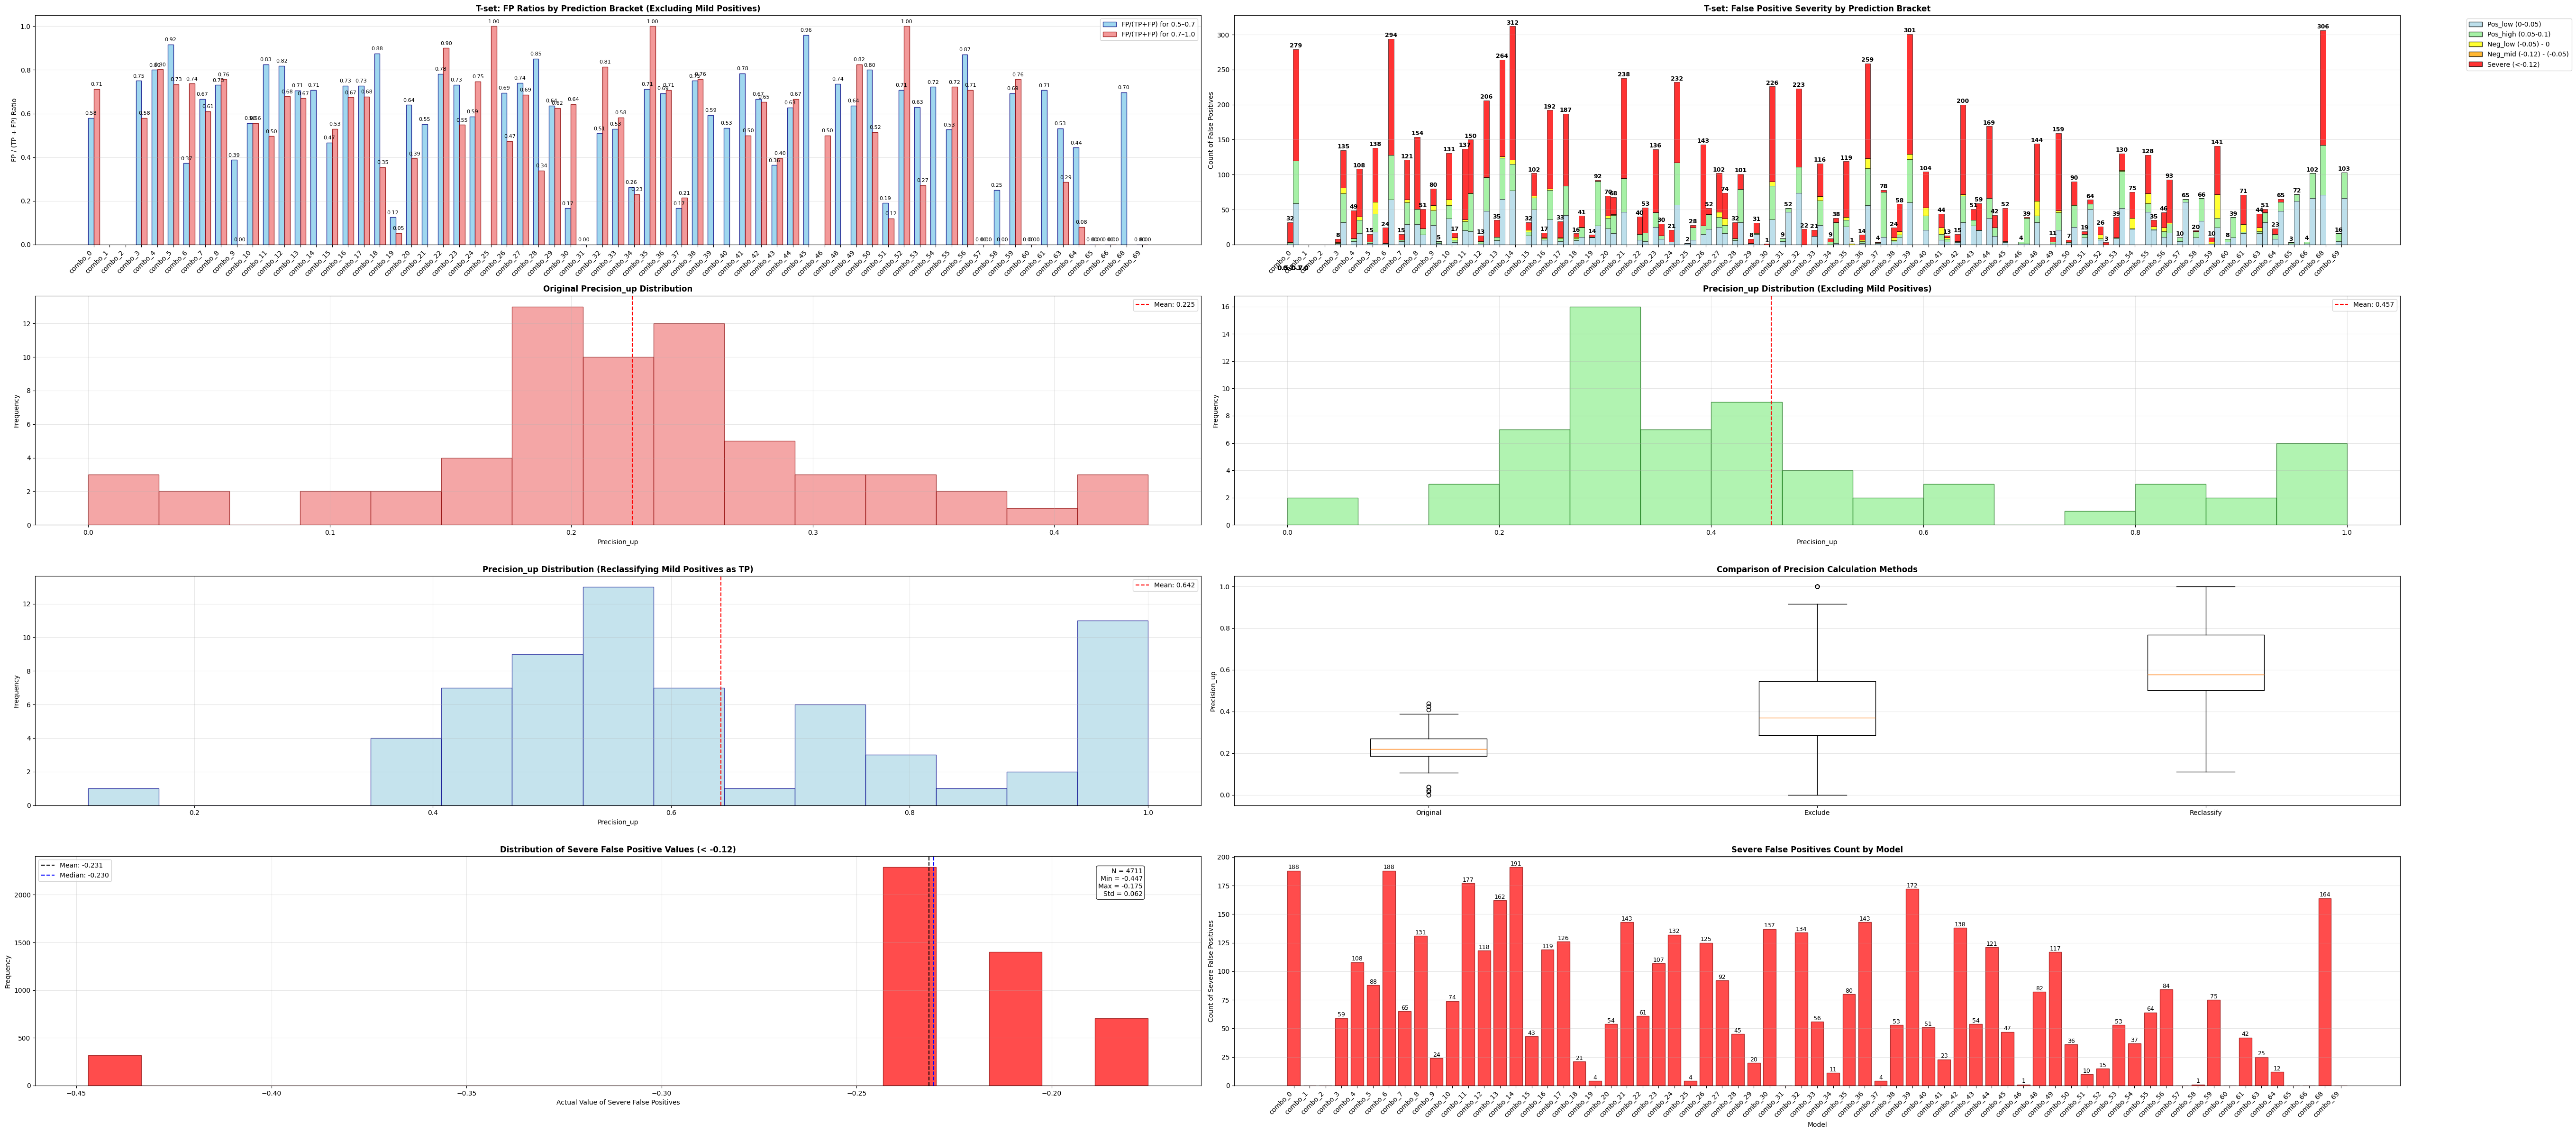


SEVERE CASE PROPORTIONS BY BRACKET
combo_0:
  Low bracket (0.5-0.7): 90.6% severe (29/32)
  High bracket (0.7-1.0): 57.0% severe (159/279)
----------------------------------------
combo_1:
  Low bracket (0.5-0.7): 0.0% severe (0/0)
  High bracket (0.7-1.0): 0.0% severe (0/0)
----------------------------------------
combo_2:
  Low bracket (0.5-0.7): 0.0% severe (0/0)
  High bracket (0.7-1.0): 0.0% severe (0/0)
----------------------------------------
combo_3:
  Low bracket (0.5-0.7): 62.5% severe (5/8)
  High bracket (0.7-1.0): 40.0% severe (54/135)
----------------------------------------
combo_4:
  Low bracket (0.5-0.7): 81.6% severe (40/49)
  High bracket (0.7-1.0): 63.0% severe (68/108)
----------------------------------------
combo_5:
  Low bracket (0.5-0.7): 73.3% severe (11/15)
  High bracket (0.7-1.0): 55.8% severe (77/138)
----------------------------------------
combo_6:
  Low bracket (0.5-0.7): 91.7% severe (22/24)
  High bracket (0.7-1.0): 56.5% severe (166/294)
-----------

In [156]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# Brackets to match your selection logic
BRACKETS = [(0.5, 0.7), (0.7, 1.0)]
BRACKET_KEYS = [f"{L}-{H}" for (L, H) in BRACKETS]

# Define consistent color scheme for severity categories
SEVERITY_COLORS = {
    "Pos_low (0-0.05)": 'lightblue',
    "Pos_high (0.05-0.1)": 'lightgreen',
    "Neg_low (-0.05) - 0": 'yellow',
    "Neg_mid (-0.12) - (-0.05)": 'orange',
    "Severe (<-0.12)": 'red',
    "Other": 'gray'
}

def classify_severity_10_percent_pos(actual_value):
    """Classify actual values into severity categories"""
    if 0 < actual_value <= 0.05:
        return "Pos_low (0-0.05)"
    elif 0.05 < actual_value <= 0.1:
        return "Pos_high (0.05-0.1)"
    elif 0 > actual_value >= -0.05:
        return "Neg_low (-0.05) - 0"
    elif -0.05 > actual_value > -0.12:
        return "Neg_mid (-0.12) - (-0.05)"
    elif actual_value <= -0.12:
        return "Severe (<-0.12)"
    return "Other"

def calc_fp_tp_ratios_for_model_tset(model_entry, brackets=BRACKETS, exclude_mild_positives=False):
    """Recompute FP/(TP+FP) per bracket for one T-set model entry."""
    bracket_counts = {f"{L}-{H}": {"TP": 0, "FP": 0} for (L, H) in brackets}
    severity_counts = {f"{L}-{H}": defaultdict(int) for (L, H) in brackets}
    severe_fp_values = []  # Store actual values of severe false positives

    for seed_entry in model_entry.get("per_seed_all_results", []):
        re = seed_entry["result_entry"]
        all_preds = re.get("all_preds", [])
        all_actuals = re.get("all_actuals", [])
        raw_actuals = re.get("raw_actuals", all_actuals)  # Use actuals if raw not available

        for pred_fold, actual_fold, raw_fold in zip(all_preds, all_actuals, raw_actuals):
            for pred, actual, raw in zip(pred_fold, actual_fold, raw_fold):
                true_positive = (actual > 0.5) and (pred >= 0.5)
                false_positive = (actual <= 0.5) and (pred >= 0.5)

                # assign into first matching bracket
                for (L, H) in brackets:
                    if L <= pred < H:
                        key = f"{L}-{H}"
                        if true_positive:
                            bracket_counts[key]["TP"] += 1
                        elif false_positive:
                            # Check if we should exclude mild positives
                            severity = classify_severity_10_percent_pos(raw)
                            if exclude_mild_positives and severity in ["Pos_low (0-0.05)", "Pos_high (0.05-0.1)"]:
                                # Skip counting this as FP if excluding mild positives
                                continue
                            
                            bracket_counts[key]["FP"] += 1
                            severity_counts[key][severity] += 1
                            
                            # Store severe false positive values
                            if severity == "Severe (<-0.12)":
                                severe_fp_values.append(raw)
                        break

    # convert to FP/(TP+FP)
    ratios = {}
    for k, c in bracket_counts.items():
        tp, fp = c["TP"], c["FP"]
        denom = tp + fp
        ratios[k] = (fp / denom) if denom > 0 else np.nan
    
    return ratios, severity_counts, severe_fp_values

def calc_modified_precision_up(model_entry, modification_type="exclude"):
    """
    Calculate modified precision_up values.
    
    modification_type:
    - "exclude": Remove Pos_low and Pos_high cases from FP count (don't count them at all)
    - "reclassify": Reclassify Pos_low and Pos_high as TP instead of FP
    - "original": Use original calculation
    """
    tp_total = 0
    fp_total = 0
    
    for seed_entry in model_entry.get("per_seed_all_results", []):
        re = seed_entry["result_entry"]
        all_preds = re.get("all_preds", [])
        all_actuals = re.get("all_actuals", [])
        raw_actuals = re.get("raw_actuals", all_actuals)

        for pred_fold, actual_fold, raw_fold in zip(all_preds, all_actuals, raw_actuals):
            for pred, actual, raw in zip(pred_fold, actual_fold, raw_fold):
                if pred >= 0.5:  # Positive prediction
                    if actual > 0.5:  # True positive
                        tp_total += 1
                    else:  # False positive
                        if modification_type == "original":
                            fp_total += 1
                        else:
                            severity = classify_severity_10_percent_pos(raw)
                            
                            if modification_type == "exclude":
                                # Exclude mild positives from FP count
                                if severity not in ["Pos_low (0-0.05)", "Pos_high (0.05-0.1)"]:
                                    fp_total += 1
                            elif modification_type == "reclassify":
                                # Reclassify mild positives as TP
                                if severity in ["Pos_low (0-0.05)", "Pos_high (0.05-0.1)"]:
                                    tp_total += 1  # Count as true positive
                                else:
                                    fp_total += 1  # Count as false positive
    
    # Calculate precision
    if tp_total + fp_total > 0:
        return tp_total / (tp_total + fp_total)
    else:
        return np.nan

# --- Build ratios and severity counts for T-set ---
tset_labels = []
tset_r_05_07 = []
tset_r_07_10 = []
tset_r_05_07_no_mild = []  # FP ratios excluding mild positives
tset_r_07_10_no_mild = []  # FP ratios excluding mild positives
tset_severity_05_07 = []  # Severity counts for 0.5-0.7 bracket
tset_severity_07_10 = []  # Severity counts for 0.7-1.0 bracket
tset_severe_fp_values = []  # Store all severe false positive values

# New: Modified precision values
tset_precision_original_calc = []  # Precision calculated from raw data (for consistency)
tset_precision_exclude = []  # Precision when excluding mild positives
tset_precision_reclassify = []  # Precision when reclassifying mild positives as TP
tset_precision_original_from_results = []  # Original precision from results

# User option: Set to True to exclude mild positives from FP counts
EXCLUDE_MILD_POSITIVES = True  # Change this to False to include all FPs

for m in selected_models:
    combo_idx = m["combo_index"]
    t_match = next((x for x in results_dist_disc_Tset_same_seeds_organized
                    if x.get("combo_index") == combo_idx), None)
    
    if t_match is None:
        tset_labels.append(f"combo_{combo_idx}")
        tset_r_05_07.append(np.nan)
        tset_r_07_10.append(np.nan)
        tset_r_05_07_no_mild.append(np.nan)
        tset_r_07_10_no_mild.append(np.nan)
        tset_severity_05_07.append(defaultdict(int))
        tset_severity_07_10.append(defaultdict(int))
        tset_severe_fp_values.append([])
        tset_precision_original_calc.append(np.nan)
        tset_precision_exclude.append(np.nan)
        tset_precision_reclassify.append(np.nan)
        tset_precision_original_from_results.append(np.nan)
        continue

    # Calculate with and without mild positives
    ratios_with_mild, severity_counts, severe_fp_vals = calc_fp_tp_ratios_for_model_tset(t_match, exclude_mild_positives=False)
    ratios_no_mild, _, _ = calc_fp_tp_ratios_for_model_tset(t_match, exclude_mild_positives=EXCLUDE_MILD_POSITIVES)
    
    # Calculate all precision variants
    precision_original_calc = calc_modified_precision_up(t_match, "original")
    precision_exclude = calc_modified_precision_up(t_match, "exclude")
    precision_reclassify = calc_modified_precision_up(t_match, "reclassify")
    
    # Get original precision from the model results
    original_precision_from_results = None
    for seed_entry in t_match.get("per_seed_all_results", []):
        re = seed_entry["result_entry"]
        om = re.get("cv_sets", {}).get("overall_metrics", {})
        if "precision_up" in om:
            original_precision_from_results = om["precision_up"]
            break
    
    tset_labels.append(f"combo_{combo_idx}")
    tset_r_05_07.append(ratios_with_mild.get("0.5-0.7", np.nan))
    tset_r_07_10.append(ratios_with_mild.get("0.7-1.0", np.nan))
    tset_r_05_07_no_mild.append(ratios_no_mild.get("0.5-0.7", np.nan))
    tset_r_07_10_no_mild.append(ratios_no_mild.get("0.7-1.0", np.nan))
    tset_severity_05_07.append(severity_counts.get("0.5-0.7", defaultdict(int)))
    tset_severity_07_10.append(severity_counts.get("0.7-1.0", defaultdict(int)))
    tset_severe_fp_values.append(severe_fp_vals)
    tset_precision_original_calc.append(precision_original_calc)
    tset_precision_exclude.append(precision_exclude)
    tset_precision_reclassify.append(precision_reclassify)
    tset_precision_original_from_results.append(original_precision_from_results if original_precision_from_results is not None else np.nan)

# --- Create the plots ---
if not tset_labels:
    print("No T-set models to plot.")
else:
    # Create figure with 4x2 grid (8 subplots total)
    fig, axes = plt.subplots(4, 2, figsize=(max(16, len(tset_labels)*0.8), 24))
    ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8 = axes.flatten()
    
    # Plot 1: FP Ratios (with option to exclude mild positives)
    x = np.arange(len(tset_labels))
    width = 0.35

    # Choose which data to plot based on user option
    if EXCLUDE_MILD_POSITIVES:
        data_05_07 = tset_r_05_07_no_mild
        data_07_10 = tset_r_07_10_no_mild
        title_suffix = " (Excluding Mild Positives)"
    else:
        data_05_07 = tset_r_05_07
        data_07_10 = tset_r_07_10
        title_suffix = " (All FPs)"

    # FP Ratio plot
    bars1 = ax1.bar(x - width/2, data_05_07, width, label='FP/(TP+FP) for 0.5–0.7', 
                   alpha=0.8, color='skyblue', edgecolor='navy', linewidth=1)
    bars2 = ax1.bar(x + width/2, data_07_10, width, label='FP/(TP+FP) for 0.7–1.0', 
                   alpha=0.8, color='lightcoral', edgecolor='darkred', linewidth=1)

    ax1.set_xticks(x)
    ax1.set_xticklabels(tset_labels, rotation=45, ha='right')
    ax1.set_ylabel('FP / (TP + FP) Ratio')
    ax1.set_title(f'T-set: FP Ratios by Prediction Bracket{title_suffix}', fontsize=12, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for i, (val1, val2) in enumerate(zip(data_05_07, data_07_10)):
        if not np.isnan(val1):
            ax1.text(i - width/2, val1 + 0.01, f'{val1:.2f}', 
                    ha='center', va='bottom', fontsize=8)
        if not np.isnan(val2):
            ax1.text(i + width/2, val2 + 0.01, f'{val2:.2f}', 
                    ha='center', va='bottom', fontsize=8)

    # --- Plot 2: Severity Breakdown ---
    severity_categories = ["Pos_low (0-0.05)", "Pos_high (0.05-0.1)", 
                          "Neg_low (-0.05) - 0", "Neg_mid (-0.12) - (-0.05)", 
                          "Severe (<-0.12)"]
    
    # Prepare data for stacked bars
    low_bracket_data = {cat: [] for cat in severity_categories}
    high_bracket_data = {cat: [] for cat in severity_categories}
    
    for i in range(len(tset_labels)):
        for cat in severity_categories:
            low_bracket_data[cat].append(tset_severity_05_07[i].get(cat, 0))
            high_bracket_data[cat].append(tset_severity_07_10[i].get(cat, 0))
    
    # Plot stacked bars for each bracket with proper color coding
    bottom_low = np.zeros(len(tset_labels))
    bottom_high = np.zeros(len(tset_labels))
    
    # Create legend handles for the severity categories
    legend_handles = []
    
    for i, cat in enumerate(severity_categories):
        color = SEVERITY_COLORS[cat]
        
        # Plot low bracket (0.5-0.7)
        ax2.bar(x - width/2, low_bracket_data[cat], width, bottom=bottom_low, 
                color=color, alpha=0.8, edgecolor='black', linewidth=0.5)
        
        # Plot high bracket (0.7-1.0)
        ax2.bar(x + width/2, high_bracket_data[cat], width, bottom=bottom_high, 
                color=color, alpha=0.8, edgecolor='black', linewidth=0.5)
        
        bottom_low += low_bracket_data[cat]
        bottom_high += high_bracket_data[cat]
        
        # Create legend entry
        legend_handles.append(plt.Rectangle((0,0), 1, 1, fc=color, alpha=0.8, 
                                          label=cat, edgecolor='black'))
    
    ax2.set_xticks(x)
    ax2.set_xticklabels(tset_labels, rotation=45, ha='right')
    ax2.set_ylabel('Count of False Positives')
    ax2.set_title('T-set: False Positive Severity by Prediction Bracket', 
                 fontsize=12, fontweight='bold')
    ax2.legend(handles=legend_handles, loc='upper right', bbox_to_anchor=(1.15, 1))
    ax2.grid(True, alpha=0.3, axis='y')
    
    # Add total count labels above bars
    for i in range(len(tset_labels)):
        total_low = sum(tset_severity_05_07[i].values())
        total_high = sum(tset_severity_07_10[i].values())
        
        if total_low > 0:
            ax2.text(i - width/2, total_low + 0.5, str(total_low), 
                    ha='center', va='bottom', fontsize=9, fontweight='bold')
        if total_high > 0:
            ax2.text(i + width/2, total_high + 0.5, str(total_high), 
                    ha='center', va='bottom', fontsize=9, fontweight='bold')
        
        # Add bracket labels below x-axis
        if i == 0:
            ax2.text(i - width/2, -max(bottom_high)*0.1, '0.5-0.7', 
                    ha='center', va='top', fontsize=10, fontweight='bold')
            ax2.text(i + width/2, -max(bottom_high)*0.1, '0.7-1.0', 
                    ha='center', va='top', fontsize=10, fontweight='bold')

    # --- Plot 3: Original Precision Histogram ---
    valid_precision_original = [p for p in tset_precision_original_calc if not np.isnan(p)]
    if valid_precision_original:
        ax3.hist(valid_precision_original, bins=15, alpha=0.7, color='lightcoral', edgecolor='darkred')
        ax3.axvline(np.mean(valid_precision_original), color='red', linestyle='--', 
                   label=f'Mean: {np.mean(valid_precision_original):.3f}')
        ax3.set_xlabel('Precision_up')
        ax3.set_ylabel('Frequency')
        ax3.set_title('Original Precision_up Distribution', fontsize=12, fontweight='bold')
        ax3.legend()
        ax3.grid(True, alpha=0.3)
    else:
        ax3.text(0.5, 0.5, 'No valid precision data', ha='center', va='center', transform=ax3.transAxes)
        ax3.set_title('Original Precision_up Distribution', fontsize=12, fontweight='bold')

    # --- Plot 4: Modified Precision Histogram (Exclude mild positives) ---
    valid_precision_exclude = [p for p in tset_precision_exclude if not np.isnan(p)]
    if valid_precision_exclude:
        ax4.hist(valid_precision_exclude, bins=15, alpha=0.7, color='lightgreen', edgecolor='darkgreen')
        ax4.axvline(np.mean(valid_precision_exclude), color='red', linestyle='--', 
                   label=f'Mean: {np.mean(valid_precision_exclude):.3f}')
        ax4.set_xlabel('Precision_up')
        ax4.set_ylabel('Frequency')
        ax4.set_title('Precision_up Distribution (Excluding Mild Positives)', fontsize=12, fontweight='bold')
        ax4.legend()
        ax4.grid(True, alpha=0.3)
    else:
        ax4.text(0.5, 0.5, 'No valid precision data', ha='center', va='center', transform=ax4.transAxes)
        ax4.set_title('Precision_up Distribution (Excluding Mild Positives)', fontsize=12, fontweight='bold')

    # --- Plot 5: Modified Precision Histogram (Reclassify mild positives as TP) ---
    valid_precision_reclassify = [p for p in tset_precision_reclassify if not np.isnan(p)]
    if valid_precision_reclassify:
        ax5.hist(valid_precision_reclassify, bins=15, alpha=0.7, color='lightblue', edgecolor='darkblue')
        ax5.axvline(np.mean(valid_precision_reclassify), color='red', linestyle='--', 
                   label=f'Mean: {np.mean(valid_precision_reclassify):.3f}')
        ax5.set_xlabel('Precision_up')
        ax5.set_ylabel('Frequency')
        ax5.set_title('Precision_up Distribution (Reclassifying Mild Positives as TP)', fontsize=12, fontweight='bold')
        ax5.legend()
        ax5.grid(True, alpha=0.3)
    else:
        ax5.text(0.5, 0.5, 'No valid precision data', ha='center', va='center', transform=ax5.transAxes)
        ax5.set_title('Precision_up Distribution (Reclassifying Mild Positives as TP)', fontsize=12, fontweight='bold')

    # --- Plot 6: Comparison of All Precision Methods ---
    precision_data = [
        [p for p in tset_precision_original_calc if not np.isnan(p)],
        [p for p in tset_precision_exclude if not np.isnan(p)],
        [p for p in tset_precision_reclassify if not np.isnan(p)]
    ]
    
    if all(len(data) > 0 for data in precision_data):
        ax6.boxplot(precision_data, labels=['Original', 'Exclude', 'Reclassify'])
        ax6.set_ylabel('Precision_up')
        ax6.set_title('Comparison of Precision Calculation Methods', fontsize=12, fontweight='bold')
        ax6.grid(True, alpha=0.3, axis='y')
    else:
        ax6.text(0.5, 0.5, 'Insufficient data for comparison', ha='center', va='center', transform=ax6.transAxes)
        ax6.set_title('Comparison of Precision Calculation Methods', fontsize=12, fontweight='bold')

    # --- Plot 7: Distribution of Severe False Positive Values ---
    all_severe_fp_values = [val for sublist in tset_severe_fp_values for val in sublist]
    
    if all_severe_fp_values:
        ax7.hist(all_severe_fp_values, bins=20, alpha=0.7, color='red', edgecolor='darkred')
        ax7.axvline(np.mean(all_severe_fp_values), color='black', linestyle='--', 
                   label=f'Mean: {np.mean(all_severe_fp_values):.3f}')
        ax7.axvline(np.median(all_severe_fp_values), color='blue', linestyle='--', 
                   label=f'Median: {np.median(all_severe_fp_values):.3f}')
        ax7.set_xlabel('Actual Value of Severe False Positives')
        ax7.set_ylabel('Frequency')
        ax7.set_title('Distribution of Severe False Positive Values (< -0.12)', fontsize=12, fontweight='bold')
        ax7.legend()
        ax7.grid(True, alpha=0.3)
        
        # Add text with summary statistics
        stats_text = f'N = {len(all_severe_fp_values)}\nMin = {np.min(all_severe_fp_values):.3f}\nMax = {np.max(all_severe_fp_values):.3f}\nStd = {np.std(all_severe_fp_values):.3f}'
        ax7.text(0.95, 0.95, stats_text, transform=ax7.transAxes, ha='right', va='top', 
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    else:
        ax7.text(0.5, 0.5, 'No severe false positives found', ha='center', va='center', transform=ax7.transAxes)
        ax7.set_title('Distribution of Severe False Positive Values (< -0.12)', fontsize=12, fontweight='bold')

    # --- Plot 8: Severe FP Count by Model ---
    severe_counts = [len(severe_vals) for severe_vals in tset_severe_fp_values]
    
    if any(severe_counts):
        ax8.bar(range(len(severe_counts)), severe_counts, alpha=0.7, color='red', edgecolor='darkred')
        ax8.set_xticks(range(len(severe_counts)))
        ax8.set_xticklabels(tset_labels, rotation=45, ha='right')
        ax8.set_xlabel('Model')
        ax8.set_ylabel('Count of Severe False Positives')
        ax8.set_title('Severe False Positives Count by Model', fontsize=12, fontweight='bold')
        ax8.grid(True, alpha=0.3, axis='y')
        
        # Add count labels on bars
        for i, count in enumerate(severe_counts):
            if count > 0:
                ax8.text(i, count + 0.1, str(count), ha='center', va='bottom', fontsize=9)
    else:
        ax8.text(0.5, 0.5, 'No severe false positives found', ha='center', va='center', transform=ax8.transAxes)
        ax8.set_title('Severe False Positives Count by Model', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.show()

    # Print summary statistics
    print("\n" + "="*60)
    print("SEVERE CASE PROPORTIONS BY BRACKET")
    print("="*60)
    for i, label in enumerate(tset_labels):
        total_low = sum(tset_severity_05_07[i].values())
        total_high = sum(tset_severity_07_10[i].values())
        severe_low = tset_severity_05_07[i].get("Severe (<-0.12)", 0)
        severe_high = tset_severity_07_10[i].get("Severe (<-0.12)", 0)
        
        prop_low = (severe_low / total_low * 100) if total_low > 0 else 0
        prop_high = (severe_high / total_high * 100) if total_high > 0 else 0
        
        print(f"{label}:")
        print(f"  Low bracket (0.5-0.7): {prop_low:.1f}% severe ({severe_low}/{total_low})")
        print(f"  High bracket (0.7-1.0): {prop_high:.1f}% severe ({severe_high}/{total_high})")
        print("-" * 40)

    # Print precision comparison
    print("\n" + "="*60)
    print("PRECISION COMPARISON")
    print("="*60)
    valid_original = [p for p in tset_precision_original_calc if not np.isnan(p)]
    valid_exclude = [p for p in tset_precision_exclude if not np.isnan(p)]
    valid_reclassify = [p for p in tset_precision_reclassify if not np.isnan(p)]
    
    if valid_original and valid_exclude and valid_reclassify:
        print(f"Original Precision:      Mean = {np.mean(valid_original):.3f} (n={len(valid_original)})")
        print(f"Exclude Mild Positives:  Mean = {np.mean(valid_exclude):.3f} (n={len(valid_exclude)})")
        print(f"Reclassify as TP:        Mean = {np.mean(valid_reclassify):.3f} (n={len(valid_reclassify)})")
        
        # Calculate differences
        diff_exclude = np.mean(valid_exclude) - np.mean(valid_original)
        diff_reclassify = np.mean(valid_reclassify) - np.mean(valid_original)
        print(f"Exclude vs Original:     Δ = {diff_exclude:+.3f}")
        print(f"Reclassify vs Original:  Δ = {diff_reclassify:+.3f}")

    # Print severe FP statistics
    print("\n" + "="*60)
    print("SEVERE FALSE POSITIVE STATISTICS")
    print("="*60)
    all_severe_fp = [val for sublist in tset_severe_fp_values for val in sublist]
    if all_severe_fp:
        print(f"Total severe false positives: {len(all_severe_fp)}")
        print(f"Mean value: {np.mean(all_severe_fp):.3f}")
        print(f"Median value: {np.median(all_severe_fp):.3f}")
        print(f"Min value: {np.min(all_severe_fp):.3f}")
        print(f"Max value: {np.max(all_severe_fp):.3f}")
        print(f"Standard deviation: {np.std(all_severe_fp):.3f}")
        
        # Print severe counts by model
        print("\nSevere false positives by model:")
        for i, label in enumerate(tset_labels):
            count = len(tset_severe_fp_values[i])
            if count > 0:
                print(f"  {label}: {count} severe FPs")
    else:
        print("No severe false positives found in any model")

---
# Testing and Older Funcs 
---

In [ ]:
# a = {'seed_num': 14862, 'precision': 50.0, 'recall': 33.33333333333333, 'seed_bracket_counts': {'0.7-1.0': {'TP': 2, 'FP': 2}}, 
#  'seed_non_bracket_counts': {'TN': 16, 'FN': 4}, 'seed_fp_tp_ratios': {'0.7-1.0': 0.5}, 'seed_total_tp': 2, 'seed_total_fp': 2, 'seed_severe_fp': 0,
#   'seed_raw': {'seed': 14862, 'result_entry': {'combo_number': 1, 'parameters': {'binary_0_1_cutoff_ret_rate_percentage': 0.1, 'learning_rate': 0.005, 'num_epochs': 150, 'batch_size': 30, 'use_bidirectional': False, 'lag': 2, 'input_size': 12, 'hidden_size': 12, 'num_layers': 2, 'use_monthly_dfs_only': True, 'use_binary_0_1_retRate': False, 'use_custom_loss_function_BCE_THRESH': True, 'use_custom_loss_function_BCE_THRESH_AND_SEVERITY': False, 'use_LOW_weights_for_BCE_custom_loss': True, 'pred_threshold_sigmoid01_up': None, 'use_binary_neg1_1': False, 'use_ret_rate': False, 'use_print_acc': False, 'use_dropout': False, 'use_class_weighting': True, 'is_deterministic': True, 'seed_num': 14862, 'use_existing_lagged_data': True, 'use_dynamic_weights': False, 'use_binary_0_1_retRate_custom_neg': False, 'use_binary_0_1_retRate_custom_pos': True, 'POS_weight_multiplier': 1, 'use_rolling_fixed_train_size': False, 'use_existing_initial_weights': False, 'state_dict': None, 'use_USO_wticoncat_predictor_WEEKLY_END_MO': False, 'use_UCO_wticoncat_predictor_WEEKLY_END_MO': False, 'use_HUC_wticoncat_predictor_WEEKLY_END_MO': False, 'use_HOD_wticoncat_predictor_WEEKLY_END_MO': True, 'use_CRUD_wticoncat_predictor_WEEKLY_END_MO': False, 'use_SCO_wticoncat_predictor_WEEKLY_END_MO': False, 'train_start_month': '2008-01', 'val_start_month': '2020-01', 'val_end_month': '2021-12', 'num_preds_per_fold': 3}, 'cv_sets': {'set_1': {'accuracy': 33.33333333333333, 'precision_up': 100.0, 'recall_up': 33.33333333333333, 'precision_down': 0, 'recall_down': None}, 'set_2': {'accuracy': 66.66666666666666, 'precision_up': None, 'recall_up': 0, 'precision_down': 66.66666666666666, 'recall_down': 100.0}, 'set_3': {'accuracy': 66.66666666666666, 'precision_up': 0, 'recall_up': None, 'precision_down': 100.0, 'recall_down': 66.66666666666666}, 'set_4': {'accuracy': 66.66666666666666, 'precision_up': 0, 'recall_up': None, 'precision_down': 100.0, 'recall_down': 66.66666666666666}, 'set_5': {'accuracy': 100.0, 'precision_up': None, 'recall_up': None, 'precision_down': 100.0, 'recall_down': 100.0}, 'set_6': {'accuracy': 100.0, 'precision_up': None, 'recall_up': None, 'precision_down': 100.0, 'recall_down': 100.0}, 'set_7': {'accuracy': 66.66666666666666, 'precision_up': None, 'recall_up': 0, 'precision_down': 66.66666666666666, 'recall_down': 100.0}, 'set_8': {'accuracy': 100.0, 'precision_up': 100.0, 'recall_up': 100.0, 'precision_down': 100.0, 'recall_down': 100.0}, 'avg_across_all_sets': {'accuracy': 75.0, 'precision_up': 50.0, 'recall_up': 33.33333333333333, 'precision_down': 79.16666666666666, 'recall_down': 90.47619047619047}, 'overall_metrics': {'accuracy': 75.0, 'precision_up': 50.0, 'recall_up': 33.33333333333333, 'precision_down': 80.0, 'recall_down': 88.88888888888889}}, 'all_preds': [[2.78146835626103e-05, 0.0038203583098948, 0.806154727935791], [0.164072647690773, 1.1453050319687463e-05, 6.8010808718099725e-06], [0.9996906518936157, 0.040846388787031174, 0.00028963846853002906], [0.0004315093392506242, 0.02471335045993328, 0.7206722497940063], [7.121444650692865e-05, 5.958530891803093e-06, 1.51970252773026e-05], [0.0003365555021446198, 0.00027293572202324867, 0.0007159358356148005], [2.992231429743697e-06, 7.998763976502232e-06, 9.215978934662417e-06], [0.002682296559214592, 0.7508282661437988, 0.024195542559027672]], 'all_actuals': [[1.0, 1.0, 1.0], [1.0, 0.0, 0.0], [0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [0.0, 1.0, 0.0], [0.0, 1.0, 0.0]], 'raw_actuals': [[0.30687160940325486, 0.1855541718555418, 1.111694677871149], [0.42198640358149553, -0.2857975746268657, -0.13077551020408162], [-0.05296769346356123, -0.05037683458944853, 0.06850459482038418], [0.05101641907740451, -0.20364515529105454, -0.09621672115833724], [-0.13643410852713178, -0.3090963494913225, 0.02252057167605015], [-0.15205421431596777, -0.1127622377622377, -0.19493314567206177], [-0.03951048951048963, 0.10138332726610866, -0.1429515782515287], [-0.26725800231392216, 0.13473684210526304, -0.099412492269635]], 'Y_vals_dates_LIST': [['2020-01-31T00:00:00', '2020-02-28T00:00:00', '2020-03-27T00:00:00'], ['2020-04-24T00:00:00', '2020-05-29T00:00:00', '2020-06-26T00:00:00'], ['2020-07-31T00:00:00', '2020-08-28T00:00:00', '2020-09-25T00:00:00'], ['2020-10-30T00:00:00', '2020-11-27T00:00:00', '2020-12-25T00:00:00'], ['2021-01-29T00:00:00', '2021-02-26T00:00:00', '2021-03-26T00:00:00'], ['2021-04-30T00:00:00', '2021-05-28T00:00:00', '2021-06-25T00:00:00'], ['2021-07-30T00:00:00', '2021-08-27T00:00:00', '2021-09-24T00:00:00'], ['2021-10-29T00:00:00', '2021-11-26T00:00:00', '2021-12-31T00:00:00']]}}}

# a["seed_raw"]["result_entry"]["raw_actuals"]





# i want to add model selection features to the code above and the instructions are below: 

# 1 - general note : keep the code logic and syntax the same, add the code for the new features in the simplest way possible
# 2 - add FP severity ratio compared to all FPs : above i hace adde da fucntion that classifies severity with brackets that i have defined , add a max_FP_severe_ratio_FPs, which defines the max fraction of ALL FPs that can be severe FPs , use the qeuation FPsevere / FPall for this
# 3 - add FP severity ratio compated to all TP and FP: above i hace adde da fucntion that classifies severity with brackets that i have defined , add a max_FP_severe_ratio_FPs_andTPs, which defines the max fraction of ALL FP and TP (ie all up preds) that can be severe FPs , use the qeuation FPsevere / FP + TP 


# note - wehn i say "all", i am referring to all preds up nto all preds in general ... 


# notie that in order ot classify severity you need ot use the raw actualls, and in order ot classify fps and tps you cna use the all_actuals ... 


# look at the code and output below to see hat i mean, 

# results_dist_disc[0]["per_seed_all_results"][0]["result_entry"].keys()

# dict_keys(['combo_number', 'parameters', 'cv_sets', 'all_preds', 'all_actuals', 'raw_actuals', 'Y_vals_dates_LIST'])


# pelase write hte function again 







# here is what i want, the selected models fucntion always takes int he results_dist_disc set of data adn outputs the chosen seeds, models and 
# their correspondign analytics. I want you to wrtie a fucntion whoch takes in the top models chosen from the results_dist_disc and retursn the same 
# analytics, for hte same mdeosl adn seeds in the results_dist_disc_Tset_same_seeds_organized set of data. these sets of data hace the same models and seeds
#  but are different resutls. This fucntion you write should simply take in results_dist_disc_Tset_same_seeds_organized as an input, and return the same metrics 
# outputted byt he select_models_by_criteria but for the results_dist_disc_Tset_same_seeds_organized dataset.

In [ ]:
import math
from collections import defaultdict

# Reuse your constants
BRACKETS = [(0.5, 0.7), (0.7, 1.0)]
BRACKET_KEYS = [f"{L}-{H}" for (L, H) in BRACKETS]

def classify_severity_10_percent_pos(actual_value: float) -> str:
    """Mirror your classify_severity_10_percent_pos() categories."""
    if 0 < actual_value <= 0.05:
        return "Pos_low (0-0.05)"
    elif 0.05 < actual_value <= 0.1:
        return "Pos_high (0.05-0.1)"
    elif 0 > actual_value >= -0.05:
        return "Neg_low (-0.05) - 0"
    elif -0.05 > actual_value > -0.12:
        return "Neg_mid (-0.12) - (-0.05)"
    elif actual_value <= -0.12:
        return "Severe (<-0.12)"
    return "Other"

def _labels_from_targets(targets):
    """
    Accepts 'pos_low', 'pos_high', ('pos_low','pos_high'), [] or None.
    Returns severity labels to match against classify_severity_10_percent_pos.
    """
    if targets is None:
        targets = []
    if isinstance(targets, str):
        targets = [targets]
    label_map = {
        "pos_low":  "Pos_low (0-0.05)",
        "pos_high": "Pos_high (0.05-0.1)",
    }
    out = set()
    for k in targets:
        k2 = str(k).strip().lower()
        if k2 in label_map:
            out.add(label_map[k2])
    return out

def _find_source_model(results_data, combo_index):
    for m in results_data:
        if m.get("combo_index") == combo_index:
            return m
    return None

def _find_seed_run(per_seed_all_results, seed_num):
    for run in per_seed_all_results:
        if run.get("seed") == seed_num:
            return run
    return None

def recompute_metrics_ignoring_pos_fp(
    selected_models_output,
    results_data,
    targets=("pos_low", "pos_high"),
    fp_treatment="ignore",
):
    """
    Recompute the SAME metrics as select_models_by_criteria(), with two options:
      1) Add FP severity-by-bracket data to the output (model-level).
      2) Handle Pos_low/Pos_high FPs in one of three ways via `fp_treatment`:
         - "ignore": do not count those FPs at all (removed from denominators)
         - "flip_to_tp": convert those FPs into TPs
         - "keep": leave them as FPs (baseline)

    Parameters
    ----------
    selected_models_output : list
        Output from select_models_by_criteria() (the chosen models + seeds).
    results_data : list
        Raw results (e.g., results_dist_disc or Tset) with folds/preds/actuals.
    targets : str | list | tuple
        Which FP severities to act on: "pos_low", "pos_high", both, or empty.
    fp_treatment : {"ignore","flip_to_tp","keep"}
        How to treat the targeted severities (default "ignore").

    Returns
    -------
    list
        Same schema as before, plus "fp_severity_by_bracket" at the model level:
        {
          "0.5-0.7": {"Pos_low (0-0.05)": n, "Pos_high (0.05-0.1)": m, ...},
          "0.7-1.0": {...}
        }
        Note: The counts reflect FPs that *actually remained FPs after treatment*.
    """
    target_labels = _labels_from_targets(targets)
    fp_treatment = fp_treatment.lower()
    assert fp_treatment in {"ignore", "flip_to_tp", "keep"}, "fp_treatment must be 'ignore', 'flip_to_tp', or 'keep'"

    recomputed_models = []

    for model_stub in selected_models_output:
        combo_idx = model_stub["combo_index"]
        src_model = _find_source_model(results_data, combo_idx)
        if src_model is None:
            continue  # gracefully skip if not found

        # Aggregate at model level
        model_bracket_counts = defaultdict(lambda: {"TP": 0, "FP": 0})
        model_non_bracket_counts = {"TN": 0, "FN": 0}
        model_fp_severity_by_bracket = defaultdict(lambda: defaultdict(int))  # NEW

        total_tp_all = 0
        total_fp_all = 0
        total_severe_fp = 0

        seed_outputs = []
        seed_precisions = []

        for seed_info in model_stub["selected_seeds"]:
            seed_num = seed_info["seed_num"]
            seed_run = _find_seed_run(src_model["per_seed_all_results"], seed_num)
            if seed_run is None:
                continue

            re = seed_run["result_entry"]
            seed_bracket_counts = defaultdict(lambda: {"TP": 0, "FP": 0})
            seed_non_bracket_counts = {"TN": 0, "FN": 0}
            seed_total_tp = 0
            seed_total_fp = 0
            seed_severe_fp = 0
            seed_severe_fp_high_bracket = 0

            for pred_fold, actual_fold, raw_fold in zip(
                re["all_preds"], re["all_actuals"], re["raw_actuals"]
            ):
                for pred, actual, raw in zip(pred_fold, actual_fold, raw_fold):
                    true_positive  = (actual > 0.5) and (pred >= 0.5)
                    false_positive = (actual <= 0.5) and (pred >= 0.5)
                    true_negative  = (actual <= 0.5) and (pred < 0.5)
                    false_negative = (actual > 0.5) and (pred < 0.5)

                    sev = None
                    # If it's an FP, decide how to treat it based on severity
                    if false_positive:
                        sev = classify_severity_10_percent_pos(raw)
                        if sev in target_labels:
                            if fp_treatment == "ignore":
                                # Drop this FP entirely
                                continue
                            elif fp_treatment == "flip_to_tp":
                                # Re-label this instance as TP instead of FP
                                false_positive = False
                                true_positive = True
                                # (sev stays computed but won't count toward FP severity)

                    assigned = False
                    for L, H in BRACKETS:
                        if L <= pred < H:
                            assigned = True
                            key = f"{L}-{H}"
                            if true_positive:
                                seed_bracket_counts[key]["TP"] += 1
                                seed_total_tp += 1
                                total_tp_all += 1
                            elif false_positive:
                                seed_bracket_counts[key]["FP"] += 1
                                seed_total_fp += 1
                                total_fp_all += 1

                                # Track FP severity-by-bracket *after treatment*
                                # (i.e., only FPs that remained FPs)
                                if sev is None:
                                    sev = classify_severity_10_percent_pos(raw)
                                model_fp_severity_by_bracket[key][sev] += 1

                                # Track severe FP
                                if sev == "Severe (<-0.12)":
                                    seed_severe_fp += 1
                                    total_severe_fp += 1
                                    if key == "0.7-1.0":
                                        seed_severe_fp_high_bracket += 1
                            break

                    if not assigned:
                        if true_negative:
                            seed_non_bracket_counts["TN"] += 1
                            model_non_bracket_counts["TN"] += 1
                        elif false_negative:
                            seed_non_bracket_counts["FN"] += 1
                            model_non_bracket_counts["FN"] += 1

            # accumulate into model totals
            for key, counts in seed_bracket_counts.items():
                model_bracket_counts[key]["TP"] += counts["TP"]
                model_bracket_counts[key]["FP"] += counts["FP"]

            # seed-level precision/recall after treatment
            tp_sum = sum(c["TP"] for c in seed_bracket_counts.values())
            fp_sum = sum(c["FP"] for c in seed_bracket_counts.values())
            fn_sum = seed_non_bracket_counts["FN"]

            seed_precision = float(tp_sum / (tp_sum + fp_sum)) if (tp_sum + fp_sum) > 0 else float("nan")
            seed_recall = float(tp_sum / (tp_sum + fn_sum)) if (tp_sum + fn_sum) > 0 else float("nan")

            # ratios per seed
            seed_fp_tp_ratios = {}
            for key, counts in seed_bracket_counts.items():
                tp, fp = counts["TP"], counts["FP"]
                denom = tp + fp
                seed_fp_tp_ratios[key] = (fp / denom) if denom > 0 else float("nan")

            seed_outputs.append({
                "seed_num": seed_num,
                "seed_order_index": seed_info.get("seed_order_index"),
                "precision": seed_precision,
                "recall": seed_recall,
                "seed_bracket_counts": dict(seed_bracket_counts),
                "seed_non_bracket_counts": dict(seed_non_bracket_counts),
                "seed_fp_tp_ratios": seed_fp_tp_ratios,
                "seed_total_tp": seed_total_tp,
                "seed_severe_fp": seed_severe_fp,
                "seed_severe_fp_high_bracket": seed_severe_fp_high_bracket,
            })

            if not math.isnan(seed_precision):
                seed_precisions.append(seed_precision)

        # model-level aggregates
        fp_tp_ratios = {}
        for key, counts in model_bracket_counts.items():
            tp, fp = counts["TP"], counts["FP"]
            denom = tp + fp
            fp_tp_ratios[key] = (fp / denom) if denom > 0 else float("nan")

        ratio_difference = None
        if "0.7-1.0" in fp_tp_ratios and "0.5-0.7" in fp_tp_ratios:
            rh = fp_tp_ratios["0.7-1.0"]
            rl = fp_tp_ratios["0.5-0.7"]
            if not (math.isnan(rh) or math.isnan(rl)):
                ratio_difference = rl - rh

        # severe FP ratios (after treatment)
        fp_severe_ratio_fps = (total_severe_fp / total_fp_all) if total_fp_all > 0 else 0.0
        fp_severe_ratio_fps_tps = (total_severe_fp / (total_fp_all + total_tp_all)) if (total_fp_all + total_tp_all) > 0 else 0.0

        mean_precision = float(sum(seed_precisions) / len(seed_precisions)) if seed_precisions else float("nan")
        zero_precision_count = sum(1 for s in seed_outputs if (not math.isnan(s["precision"]) and s["precision"] == 0))

        recomputed_models.append({
            "combo_index": combo_idx,
            "parameters": model_stub["parameters"],  # keep original params
            "mean_precision": mean_precision,
            "valid_seeds_count": len(seed_outputs),
            "total_seeds": len(seed_outputs),
            "zero_precision_count": zero_precision_count,
            "bracket_counts": dict(model_bracket_counts),
            "non_bracket_counts": dict(model_non_bracket_counts),
            "fp_tp_ratios": fp_tp_ratios,
            "ratio_difference": ratio_difference,
            "fp_severe_ratio_fps": fp_severe_ratio_fps,
            "fp_severe_ratio_fps_tps": fp_severe_ratio_fps_tps,
            "fp_severity_by_bracket": {k: dict(v) for k, v in model_fp_severity_by_bracket.items()},  # NEW
            "selected_seeds": seed_outputs
        })

    return recomputed_models



recomputed_ignore = recompute_metrics_ignoring_pos_fp(
    selected_models_output=selected_models,
    results_data=results_dist_disc_Tset_same_seeds_organized,
    targets=("pos_low","pos_high"),
    fp_treatment="ignore"
)



In [ ]:
# Modified function to store TP and FP counts for each seed
def select_models_by_criteria(results_data, 
                             mean_precision_range=(0, 100),
                             seed_precision_range=(0, 100),
                             seed_recall_range=(0, 100),
                             min_seeds_per_model=1,
                             max_models_to_return=10,
                             max_zero_precision_seeds=None,
                             min_ratio_difference=None,
                             max_ratio_difference=None,
                             seed_min_TPminusFP_greaterEqual=None,
                             max_FP_severe_ratio_FPs=None,         
                             max_FP_severe_ratio_FPs_andTPs=None, 
                             min_FP_severe_ratio_FPs=None,         
                             min_FP_severe_ratio_FPs_andTPs=None, 
                                                           
                             max_seed_severe_FPs_high_bracket=None,
                             min_seed_TPs_high_bracket=None,       
                             random_seed=None):
    
    if random_seed is not None:
        random.seed(random_seed)

    brackets = [(0.5, 0.7), (0.7, 1.0)]
    model_summaries = []

    for model in results_data:
        combo_idx = model["combo_index"]

        parameters = model["combo"]
        per_seed = model["per_seed_all_results"]

        zero_precision_count = 0
        bracket_counts = defaultdict(lambda: {'TP': 0, 'FP': 0})
        non_bracket_counts = {'TN': 0, 'FN': 0}
        seed_records = []
        fp_severity_by_bracket = defaultdict(lambda: defaultdict(int))  # NEW: FP severity counts per bracket
        
        # NEW: Track severe FP counts
        total_severe_fp = 0
        total_fp_all = 0
        total_tp_all = 0

        for run in per_seed:
            re = run["result_entry"]
            om = re["cv_sets"]["overall_metrics"]

            seed_num = run["seed"]

            prec = om.get("precision_up")
            rec = om.get("recall_up")
            if isinstance(prec, (int, float)) and not math.isnan(prec):
                prec = float(prec)
                if prec == 0:
                    zero_precision_count += 1
            else:
                prec = None

            if isinstance(rec, (int, float)) and not math.isnan(rec):
                rec = float(rec)
            else:
                rec = None

            # Store TP and FP counts for each bracket per seed
            seed_bracket_counts = defaultdict(lambda: {'TP': 0, 'FP': 0})
            seed_non_bracket_counts = {'TN': 0, 'FN': 0}
            seed_total_tp = 0
            seed_total_fp = 0
            seed_severe_fp = 0  # NEW: Track severe FPs per seed
            seed_severe_fp_high_bracket = 0  # NEW: Track severe FPs specifically in 0.7-1.0 bracket

            for pred_fold, actual_fold ,raw_fold in zip(re["all_preds"], re["all_actuals"], re["raw_actuals"]):
                for pred, actual, raw in zip(pred_fold, actual_fold, raw_fold):
                    true_positive = (actual > 0.5) and (pred >= 0.5)
                    false_positive = (actual <= 0.5) and (pred >= 0.5)
                    true_negative = (actual <= 0.5) and (pred < 0.5)
                    false_negative = (actual > 0.5) and (pred < 0.5)

                    assigned = False
                    for L, H in brackets:
                        if L <= pred < H:
                            assigned = True
                            key = f"{L}-{H}"
                            if true_positive:
                                bracket_counts[key]['TP'] += 1
                                seed_bracket_counts[key]['TP'] += 1
                                seed_total_tp += 1
                                total_tp_all += 1  # NEW: Count all TPs
                            elif false_positive:
                                bracket_counts[key]['FP'] += 1
                                seed_bracket_counts[key]['FP'] += 1
                                seed_total_fp += 1
                                total_fp_all += 1  # NEW: Count all FPs
                                
                                # NEW: Check and record severity of this FP
                                severity = classify_severity_10_percent_pos(raw)
                                fp_severity_by_bracket[key][severity] += 1  # NEW
                                if severity == "Severe (<-0.12)":
                                    seed_severe_fp += 1
                                    total_severe_fp += 1
                                    # NEW: Check if this severe FP is in the high bracket (0.7-1.0)
                                    if key == "0.7-1.0":
                                        seed_severe_fp_high_bracket += 1
                            break

                    if not assigned:
                        if true_negative:
                            seed_non_bracket_counts['TN'] += 1
                            non_bracket_counts['TN'] += 1
                        elif false_negative:
                            seed_non_bracket_counts['FN'] += 1
                            non_bracket_counts['FN'] += 1

            seed_fp_tp_ratios = {}
            for key, counts in seed_bracket_counts.items():
                tp, fp = counts['TP'], counts['FP']
                denom = tp + fp
                seed_fp_tp_ratios[key] = (fp / denom) if denom > 0 else float("nan")

            seed_records.append({
                "seed_num": seed_num,
                "precision": prec,
                "recall": rec,
                "seed_bracket_counts": dict(seed_bracket_counts),
                "seed_non_bracket_counts": dict(seed_non_bracket_counts),
                "seed_fp_tp_ratios": seed_fp_tp_ratios,
                "seed_total_tp": seed_total_tp,
                "seed_total_fp": seed_total_fp,
                "seed_severe_fp": seed_severe_fp,  # NEW: Add severe FP count
                "seed_severe_fp_high_bracket": seed_severe_fp_high_bracket,  # NEW: Add severe FP count in high bracket
                "seed_raw": run,
            })

        non_none_precs = [r["precision"] for r in seed_records if r["precision"] is not None]
        mean_precision = float(np.mean(non_none_precs)) if non_none_precs else float("nan")

        fp_tp_ratios = {}
        for key, counts in bracket_counts.items():
            tp, fp = counts['TP'], counts['FP']
            denom = tp + fp
            fp_tp_ratios[key] = (fp / denom) if denom > 0 else float("nan")

        ratio_difference = None
        if "0.7-1.0" in fp_tp_ratios and "0.5-0.7" in fp_tp_ratios:
            rh, rl = fp_tp_ratios["0.7-1.0"], fp_tp_ratios["0.5-0.7"]
            if not math.isnan(rh) and not math.isnan(rl):
                ratio_difference = rl - rh

        # NEW: Calculate severe FP ratios
        fp_severe_ratio_fps = total_severe_fp / total_fp_all if total_fp_all > 0 else 0
        fp_severe_ratio_fps_tps = total_severe_fp / (total_fp_all + total_tp_all) if (total_fp_all + total_tp_all) > 0 else 0

        model_summaries.append({
            "combo_index": combo_idx,
            "parameters": parameters,
            "mean_precision": mean_precision,
            "zero_precision_count": zero_precision_count,
            "total_seeds": len(seed_records),
            "seed_records": seed_records,
            "bracket_counts": dict(bracket_counts),
            "non_bracket_counts": dict(non_bracket_counts),
            "fp_tp_ratios": fp_tp_ratios,
            "ratio_difference": ratio_difference,
            "fp_severe_ratio_fps": fp_severe_ratio_fps,           # NEW: Add severe FP ratios
            "fp_severe_ratio_fps_tps": fp_severe_ratio_fps_tps,   # NEW: Add severe FP ratios
            "fp_severity_by_bracket": {k: dict(v) for k, v in fp_severity_by_bracket.items()},  # NEW: FP severity by bracket
        })

    filtered_models = []
    min_mean_prec, max_mean_prec = mean_precision_range
    min_seed_prec, max_seed_prec = seed_precision_range
    min_seed_rec, max_seed_rec = seed_recall_range

    for m in model_summaries:
        # Check mean precision range
        mean_prec = m["mean_precision"] if not math.isnan(m["mean_precision"]) else -float("inf")
        if not (min_mean_prec <= mean_prec <= max_mean_prec):
            continue

        # Check zero precision count
        if max_zero_precision_seeds is not None and m["zero_precision_count"] > max_zero_precision_seeds:
            continue

        # Check ratio difference
        if min_ratio_difference is not None or max_ratio_difference is not None:
            if m["ratio_difference"] is None:
                continue
            if min_ratio_difference is not None and m["ratio_difference"] < min_ratio_difference:
                continue
        if max_ratio_difference is not None:    
            if m["ratio_difference"] is None:
                continue
            if max_ratio_difference is not None and m["ratio_difference"] > max_ratio_difference:
                continue

        # NEW: Check severe FP ratio among all FPs
        if max_FP_severe_ratio_FPs is not None:
            if not (m["fp_severe_ratio_fps"] < max_FP_severe_ratio_FPs):
                continue

        if min_FP_severe_ratio_FPs is not None:
            if not (m["fp_severe_ratio_fps"] > min_FP_severe_ratio_FPs):
                continue

        # NEW: Check severe FP ratio among all positive predictions (TPs + FPs)
        if max_FP_severe_ratio_FPs_andTPs is not None:
            if not (m["fp_severe_ratio_fps_tps"] < max_FP_severe_ratio_FPs_andTPs):
                continue
        
        if min_FP_severe_ratio_FPs_andTPs is not None:
            if not (m["fp_severe_ratio_fps_tps"] > min_FP_severe_ratio_FPs_andTPs):
                continue

        valid_seeds = []
        for idx, r in enumerate(m["seed_records"]):
            prec, rec = r["precision"], r["recall"]

            if prec is None or rec is None:
                continue
            if (min_seed_prec <= prec <= max_seed_prec) and (min_seed_rec <= rec <= max_seed_rec):

                # TP-FP difference filtering
                bracket_high = r["seed_bracket_counts"].get("0.7-1.0", {"TP": 0, "FP": 0})
                bracket_low = r["seed_bracket_counts"].get("0.5-0.7", {"TP": 0, "FP": 0})
                
                net_high = bracket_high["TP"] - bracket_high["FP"]
                net_low = bracket_low["TP"] - bracket_low["FP"]

                if seed_min_TPminusFP_greaterEqual is not None:
                    if (bracket_high["TP"] == 0):
                        continue
                    if (bracket_high["FP"] > bracket_high["TP"]):
                        continue
                    if not (net_high - net_low >= seed_min_TPminusFP_greaterEqual):
                        continue

                # NEW: Check max severe FPs in high bracket for this seed
                if max_seed_severe_FPs_high_bracket is not None:
                    if not (r["seed_severe_fp_high_bracket"] <= max_seed_severe_FPs_high_bracket):
                        continue

                # NEW: Check min TPs in high bracket for this seeda
                if min_seed_TPs_high_bracket is not None:
                    if not (bracket_high["TP"] >= min_seed_TPs_high_bracket):
                        continue

                valid_seeds.append({
                    "seed_order_index": idx,
                    "seed_num": r["seed_num"],
                    "precision": prec,
                    "recall": rec,
                    "seed_bracket_counts": r["seed_bracket_counts"],
                    "seed_non_bracket_counts": r["seed_non_bracket_counts"],
                    "seed_fp_tp_ratios": r["seed_fp_tp_ratios"],
                    "seed_total_tp": r["seed_total_tp"],
                    "seed_severe_fp": r["seed_severe_fp"],  # NEW: Include severe FP count
                    "seed_severe_fp_high_bracket": r["seed_severe_fp_high_bracket"],  # NEW: Include severe FP count in high bracket
                })

        if len(valid_seeds) >= min_seeds_per_model:
            filtered_models.append({
                "combo_index": m["combo_index"],
                "parameters": m["parameters"],
                "mean_precision": m["mean_precision"],
                "valid_seeds_count": len(valid_seeds),
                "valid_seeds": valid_seeds,
                "total_seeds": m["total_seeds"],
                "zero_precision_count": m["zero_precision_count"],
                "bracket_counts": m["bracket_counts"],
                "non_bracket_counts": m["non_bracket_counts"],
                "fp_tp_ratios": m["fp_tp_ratios"],
                "ratio_difference": m["ratio_difference"],
                "fp_severe_ratio_fps": m["fp_severe_ratio_fps"],           # NEW: Include severe FP ratios
                "fp_severe_ratio_fps_tps": m["fp_severe_ratio_fps_tps"],   # NEW: Include severe FP ratios
                "fp_severity_by_bracket": m["fp_severity_by_bracket"],     # NEW: Carry through
            })

    if max_models_to_return < len(filtered_models):
        n_pick = min(max_models_to_return, len(filtered_models))
        selected_models = random.sample(filtered_models, n_pick) if n_pick > 0 else []
    else:
        selected_models = filtered_models

    output = []
    for m in selected_models:
        output.append({
            "combo_index": m["combo_index"],
            "parameters": m["parameters"],
            "mean_precision": m["mean_precision"],
            "valid_seeds_count": m["valid_seeds_count"],
            "total_seeds": m["total_seeds"],
            "zero_precision_count": m["zero_precision_count"],
            "bracket_counts": m["bracket_counts"],
            "non_bracket_counts": m["non_bracket_counts"],
            "fp_tp_ratios": m["fp_tp_ratios"],
            "ratio_difference": m["ratio_difference"],
            "fp_severe_ratio_fps": m["fp_severe_ratio_fps"],           # NEW: Include in output
            "fp_severe_ratio_fps_tps": m["fp_severe_ratio_fps_tps"],   # NEW: Include in output
            "fp_severity_by_bracket": m["fp_severity_by_bracket"],     # NEW: Include in output
            "selected_seeds": [
                {
                    "seed_num": s["seed_num"],
                    "seed_order_index": s["seed_order_index"],
                    "precision": s["precision"],
                    "recall": s["recall"],
                    "seed_bracket_counts": s["seed_bracket_counts"],
                    "seed_non_bracket_counts": s["seed_non_bracket_counts"],
                    "seed_fp_tp_ratios": s["seed_fp_tp_ratios"],
                    "seed_total_tp": s["seed_total_tp"],
                    "seed_severe_fp": s["seed_severe_fp"],  # NEW: Include in seed output
                    "seed_severe_fp_high_bracket": s["seed_severe_fp_high_bracket"],  # NEW: Include in seed output
                }
                for s in m["valid_seeds"]
            ]
        })

    return output


Models Selected (recomputed): 28
Total seeds selected (recomputed): 1742


In [ ]:
import math
import numpy as np
from collections import defaultdict

def recompute_selected_models_on_Tset(results_dist_disc_Tset_same_seeds_organized,
                                      selected_models,
                                      brackets=((0.5, 0.7), (0.7, 1.0))):
    """
    Recompute the SAME analytics produced by `select_models_by_criteria`
    for the SAME models & seeds, but using the T-set dataset.
    """

    # Build an index of Tset models by combo_index for O(1) lookup
    tset_by_combo = {m["combo_index"]: m for m in results_dist_disc_Tset_same_seeds_organized}

    # Helper to compute all counts/metrics for a single model on Tset (across ALL seeds)
    def _compute_model_metrics_on_tset(model_entry, brackets):
        per_seed = model_entry["per_seed_all_results"]

        zero_precision_count = 0
        bracket_counts = defaultdict(lambda: {'TP': 0, 'FP': 0})
        non_bracket_counts = {'TN': 0, 'FN': 0}
        seed_records_all = []

        total_severe_fp = 0
        total_fp_all = 0
        total_tp_all = 0

        # NEW: aggregate FP severity distribution by bracket (across ALL seeds)
        fp_severity_by_bracket = defaultdict(lambda: defaultdict(int))  # NEW

        for run_idx, run in enumerate(per_seed):
            re = run["result_entry"]
            om = re["cv_sets"]["overall_metrics"]
            seed_num = run["seed"]

            prec = om.get("precision_up")
            rec = om.get("recall_up")

            if isinstance(prec, (int, float)) and not math.isnan(prec):
                prec = float(prec)
                if prec == 0:
                    zero_precision_count += 1
            else:
                prec = None

            if isinstance(rec, (int, float)) and not math.isnan(rec):
                rec = float(rec)
            else:
                rec = None

            # Per-seed tallies for this model
            seed_bracket_counts = defaultdict(lambda: {'TP': 0, 'FP': 0})
            seed_non_bracket_counts = {'TN': 0, 'FN': 0}
            seed_total_tp = 0
            seed_total_fp = 0
            seed_severe_fp = 0
            seed_severe_fp_high_bracket = 0

            # Walk folds/timesteps exactly like selection function
            for pred_fold, actual_fold, raw_fold in zip(re["all_preds"], re["all_actuals"], re["raw_actuals"]):
                for pred, actual, raw in zip(pred_fold, actual_fold, raw_fold):
                    true_positive = (actual > 0.5) and (pred >= 0.5)
                    false_positive = (actual <= 0.5) and (pred >= 0.5)
                    true_negative = (actual <= 0.5) and (pred < 0.5)
                    false_negative = (actual > 0.5) and (pred < 0.5)

                    assigned = False
                    for (L, H) in brackets:
                        if L <= pred < H:
                            assigned = True
                            key = f"{L}-{H}"
                            if true_positive:
                                bracket_counts[key]['TP'] += 1
                                seed_bracket_counts[key]['TP'] += 1
                                seed_total_tp += 1
                                total_tp_all += 1
                            elif false_positive:
                                bracket_counts[key]['FP'] += 1
                                seed_bracket_counts[key]['FP'] += 1
                                seed_total_fp += 1
                                total_fp_all += 1

                                # Severity classification & tallies
                                severity = classify_severity_10_percent_pos(raw)
                                fp_severity_by_bracket[key][severity] += 1   # NEW
                                if severity == "Severe (<-0.12)":
                                    seed_severe_fp += 1
                                    total_severe_fp += 1
                                    if key == "0.7-1.0":
                                        seed_severe_fp_high_bracket += 1
                            break

                    if not assigned:
                        if true_negative:
                            non_bracket_counts['TN'] += 1
                            seed_non_bracket_counts['TN'] += 1
                        elif false_negative:
                            non_bracket_counts['FN'] += 1
                            seed_non_bracket_counts['FN'] += 1

            # Per-seed ratios
            seed_fp_tp_ratios = {}
            for key, counts in seed_bracket_counts.items():
                tp, fp = counts['TP'], counts['FP']
                denom = tp + fp
                seed_fp_tp_ratios[key] = (fp / denom) if denom > 0 else float("nan")

            seed_records_all.append({
                "seed_order_index": run_idx,  # position within per_seed_all_results
                "seed_num": seed_num,
                "precision": prec,
                "recall": rec,
                "seed_bracket_counts": dict(seed_bracket_counts),
                "seed_non_bracket_counts": dict(seed_non_bracket_counts),
                "seed_fp_tp_ratios": seed_fp_tp_ratios,
                "seed_total_tp": seed_total_tp,
                "seed_total_fp": seed_total_fp,
                "seed_severe_fp": seed_severe_fp,
                "seed_severe_fp_high_bracket": seed_severe_fp_high_bracket,
            })

        # Mean precision across ALL seeds
        non_none_precs = [r["precision"] for r in seed_records_all if r["precision"] is not None]
        mean_precision = float(np.mean(non_none_precs)) if non_none_precs else float("nan")

        # Model-level fp/tp ratio by bracket
        fp_tp_ratios = {}
        for key, counts in bracket_counts.items():
            tp, fp = counts['TP'], counts['FP']
            denom = tp + fp
            fp_tp_ratios[key] = (fp / denom) if denom > 0 else float("nan")

        # rl - rh (low minus high)
        ratio_difference = None
        if "0.7-1.0" in fp_tp_ratios and "0.5-0.7" in fp_tp_ratios:
            rh = fp_tp_ratios["0.7-1.0"]
            rl = fp_tp_ratios["0.5-0.7"]
            if not math.isnan(rh) and not math.isnan(rl):
                ratio_difference = rl - rh

        # Severe FP ratios
        fp_severe_ratio_fps = (total_severe_fp / total_fp_all) if total_fp_all > 0 else 0
        denom_pos = (total_fp_all + total_tp_all)
        fp_severe_ratio_fps_tps = (total_severe_fp / denom_pos) if denom_pos > 0 else 0

        return {
            "mean_precision": mean_precision,
            "zero_precision_count": zero_precision_count,
            "total_seeds": len(seed_records_all),
            "seed_records_all": seed_records_all,  # keep for seed picking below
            "bracket_counts": dict(bracket_counts),
            "non_bracket_counts": dict(non_bracket_counts),
            "fp_tp_ratios": fp_tp_ratios,
            "ratio_difference": ratio_difference,
            "fp_severe_ratio_fps": fp_severe_ratio_fps,
            "fp_severe_ratio_fps_tps": fp_severe_ratio_fps_tps,
            "fp_severity_by_bracket": {k: dict(v) for k, v in fp_severity_by_bracket.items()},  # NEW
        }

    # Build output mirroring the original selection output
    mirrored_outputs = []

    for sel_model in selected_models:
        combo_idx = sel_model["combo_index"]
        # Find the corresponding Tset model
        if combo_idx not in tset_by_combo:
            continue

        tset_model = tset_by_combo[combo_idx]
        model_metrics = _compute_model_metrics_on_tset(tset_model, brackets)

        # Build a map from seed_num -> seed_record (computed from Tset)
        seed_map = {sr["seed_num"]: sr for sr in model_metrics["seed_records_all"]}

        # Recreate the "selected_seeds" list using the EXACT same seeds (and order) from training selection
        selected_seeds_Tset = []
        for s in sel_model["selected_seeds"]:
            seed_num = s["seed_num"]
            if seed_num not in seed_map:
                continue

            sr = seed_map[seed_num]
            # Mirror the schema exactly
            selected_seeds_Tset.append({
                "seed_num": sr["seed_num"],
                "seed_order_index": sr["seed_order_index"],
                "precision": sr["precision"],
                "recall": sr["recall"],
                "seed_bracket_counts": sr["seed_bracket_counts"],
                "seed_non_bracket_counts": sr["seed_non_bracket_counts"],
                "seed_fp_tp_ratios": sr["seed_fp_tp_ratios"],
                "seed_total_tp": sr["seed_total_tp"],
                "seed_severe_fp": sr["seed_severe_fp"],
                "seed_severe_fp_high_bracket": sr["seed_severe_fp_high_bracket"],
            })

        # Assemble model-level dict in the EXACT same shape as your selection output
        mirrored_outputs.append({
            "combo_index": combo_idx,
            "parameters": tset_model["combo"],  # should match
            "mean_precision": model_metrics["mean_precision"],
            "valid_seeds_count": len(selected_seeds_Tset),               # SAME selected seeds (on Tset)
            "total_seeds": model_metrics["total_seeds"],                  # all seeds present on Tset
            "zero_precision_count": model_metrics["zero_precision_count"],
            "bracket_counts": model_metrics["bracket_counts"],
            "non_bracket_counts": model_metrics["non_bracket_counts"],
            "fp_tp_ratios": model_metrics["fp_tp_ratios"],
            "ratio_difference": model_metrics["ratio_difference"],
            "fp_severe_ratio_fps": model_metrics["fp_severe_ratio_fps"],
            "fp_severe_ratio_fps_tps": model_metrics["fp_severe_ratio_fps_tps"],
            "fp_severity_by_bracket": model_metrics["fp_severity_by_bracket"],  # NEW
            "selected_seeds": selected_seeds_Tset,
        })

    return mirrored_outputs
